# Frontier Analyses — Extended Appendix

> *EXTRA — Approfondimento specifico SSVI.*
## SSVI Surface · Volmageddon · No-Arbitrage · Forecasting Battle · Shock Classification · VAR · Probabilistic PI

**Data timing note**: all forecasting analyses use **today's market features (X_t) to predict
tomorrow's SSVI parameters (y_{t+1})**. Descriptive sections (surface plots, event study,
no-arbitrage checks) use the full sample lookback — no forecasting is involved.

## 0. Setup & Data

In [1]:
import os
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from itertools import product
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.regression.quantile_regression import QuantReg
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score, roc_auc_score)
from arch import arch_model as arch_fn
import fredapi, yfinance as yf

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})

BASE   = r"C:\Users\alpor\OneDrive\Desktop\politecnico\MAGISTRALE II\Insurance & Econometrics\ECONOMETRICS\PROGETTO"
NB_DIR   = os.path.join(BASE, "Notebook_newdata")
OUTPUT   = os.path.join(NB_DIR, "output")
PLOT_DIR = os.path.join(OUTPUT, "plots")
os.makedirs(OUTPUT,   exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
PLOTS  = BASE + r"\final_submission\plots"
START  = pd.Timestamp('2010-01-04')
END    = pd.Timestamp('2020-12-31')  # extended to include COVID
SPLIT  = 0.80
DIFF_T = {'d_alpha', 'd_eta'}
LEVEL_T= {'beta', 'rho', 'gamma'}
TARGETS= ['d_alpha', 'd_eta', 'beta', 'rho', 'gamma']
VOLMAG = pd.Timestamp('2018-02-05')

# ── SSVI ─────────────────────────────────────────────────────────────────────
ssvi = pd.read_csv(os.path.join(OUTPUT, "ssvi_all_dates_clean_results.csv"))
ssvi = ssvi[ssvi['success'] == True].copy()
ssvi['date'] = START + pd.to_timedelta(ssvi['time_elapsed'], unit='D')
ssvi = ssvi[['date','alpha','beta','rho','eta','gamma','rmse_iv','mae_iv','n_obs']].sort_values('date').reset_index(drop=True)
ssvi['d_alpha'] = ssvi['alpha'].diff()
ssvi['d_eta']   = ssvi['eta'].diff()
ssvi = ssvi.dropna().reset_index(drop=True)

# ── Market ────────────────────────────────────────────────────────────────────
fred = fredapi.Fred(api_key='443c959d542fb3328af50453afd7368a')
mkt = {}
for name, sid in {'vix':'VIXCLS','vix3m':'VXVCLS','rate_3m':'DGS3MO','rate_10y':'DGS10','sp500':'SP500'}.items():
    try: mkt[name] = pd.to_numeric(fred.get_series(sid), errors='coerce').sort_index().resample('D').ffill().loc[START:END]
    except: pass
mdf = pd.DataFrame(mkt).reset_index().rename(columns={'index':'date'})
for name, ticker in {'vvix':'^VVIX', 'vix9d':'^VIX9D'}.items():
    try:
        raw = yf.download(ticker, start=START, end=END+pd.Timedelta(days=1), progress=False, auto_adjust=True)
        if isinstance(raw.columns, pd.MultiIndex): raw.columns = [c[0].lower() for c in raw.columns]
        else: raw.columns = [c.lower() for c in raw.columns]
        s = raw['close'].squeeze().rename(name)
        s.index = pd.to_datetime(s.index).normalize()
        s = s.resample('D').ffill().loc[START:END]
        tmp = s.reset_index(); tmp.columns = ['date', name]
        mdf = mdf.merge(tmp, on='date', how='left')
    except: pass
mdf = mdf.ffill()
m = mdf.sort_values('date').copy()
m['d_vix']     = m['vix'].diff()
m['sp500_ret'] = m['sp500'].pct_change()
m['vrp']       = (m['vix']/100)**2/252 - (m['sp500_ret'].rolling(21).std())**2
m['ts_9d_1m']  = m.get('vix9d', m['vix']) - m['vix']
m['ts_1m_3m']  = m['vix'] - m.get('vix3m', m['vix'])
m['slope']     = m.get('rate_10y', m['vix']) - m.get('rate_3m', m['vix'])
if 'vvix' in m.columns: m['d_vvix'] = m['vvix'].diff()
m['vix_zscore'] = (m['vix'] - m['vix'].rolling(21).mean()) / (m['vix'].rolling(21).std() + 1e-9)

FEATS = [c for c in ['d_vix','vrp','ts_9d_1m','ts_1m_3m','slope','d_vvix','sp500_ret','vix_zscore'] if c in m.columns]
mfeat = m[['date'] + FEATS].dropna()
df = ssvi.merge(mfeat, on='date', how='inner').sort_values('date').reset_index(drop=True)

N = len(df); n_train = int(N * SPLIT)
df_train = df.iloc[:n_train].copy().reset_index(drop=True)
df_test  = df.iloc[n_train:].copy().reset_index(drop=True)

# ── Feature selection on TRAIN (Granger + VIF) ────────────────────────────────
gr_rows = []
for target in TARGETS:
    for feat in FEATS:
        sub = df_train[[target, feat]].dropna()
        if len(sub) < 25: continue
        try:
            res = grangercausalitytests(sub, maxlag=2, verbose=False)
            p1  = res[1][0]['ssr_ftest'][1]
            gr_rows.append({'target':target, 'feature':feat, 'p_lag1':p1, 'sig':p1<0.10})
        except: pass
gr_df = pd.DataFrame(gr_rows)
feat_pool = list(dict.fromkeys([f for t in TARGETS for f in
    gr_df[(gr_df['target']==t) & gr_df['sig']]['feature'].tolist() if f in df_train.columns]))
feat_pool = [f for f in FEATS if f in feat_pool]
if feat_pool:
    Xv = add_constant(df_train[feat_pool].dropna())
    vif_vals = [variance_inflation_factor(Xv.values, i+1) for i in range(len(feat_pool))]
    selected_feat = [f for f,v in zip(feat_pool, vif_vals) if v < 7]
else:
    selected_feat = FEATS[:4]

best_orders = {}
for target in TARGETS:
    y_tr = df_train[target].dropna()
    best_aic = np.inf; best_pq = (1, 0)
    for p, q in product(range(3), range(3)):
        try:
            mdl = ARIMA(y_tr, order=(p,0,q), trend='c').fit()
            if mdl.aic < best_aic: best_aic = mdl.aic; best_pq = (p, q)
        except: pass
    best_orders[target] = best_pq

print(f"Dataset: {len(df)} obs  |  Train: {n_train}  Test: {N-n_train}")
print(f"Selected features ({len(selected_feat)}): {selected_feat}")
print(f"ARMA orders: { {t: f'ARMA{best_orders[t]}' for t in TARGETS} }")


c:\Users\alpor\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Dataset: 1148 obs  |  Train: 918  Test: 230
Selected features (8): ['d_vix', 'vrp', 'ts_9d_1m', 'ts_1m_3m', 'slope', 'd_vvix', 'sp500_ret', 'vix_zscore']
ARMA orders: {'d_alpha': 'ARMA(2, 0)', 'd_eta': 'ARMA(1, 1)', 'beta': 'ARMA(2, 2)', 'rho': 'ARMA(1, 1)', 'gamma': 'ARMA(1, 1)'}


---
## 1. SSVI Volatility Surface Visualization

> *EXTRA — Approfondimento specifico SSVI.*

**SSVI formula** (Gatheral & Jacquier 2014):
w(k, T) = (alpha/2) * {1 + rho * phi(T) * k + sqrt[(phi(T)*k + rho)^2 + (1-rho^2)]}
where phi(T) = eta / T^gamma and k = log-moneyness.

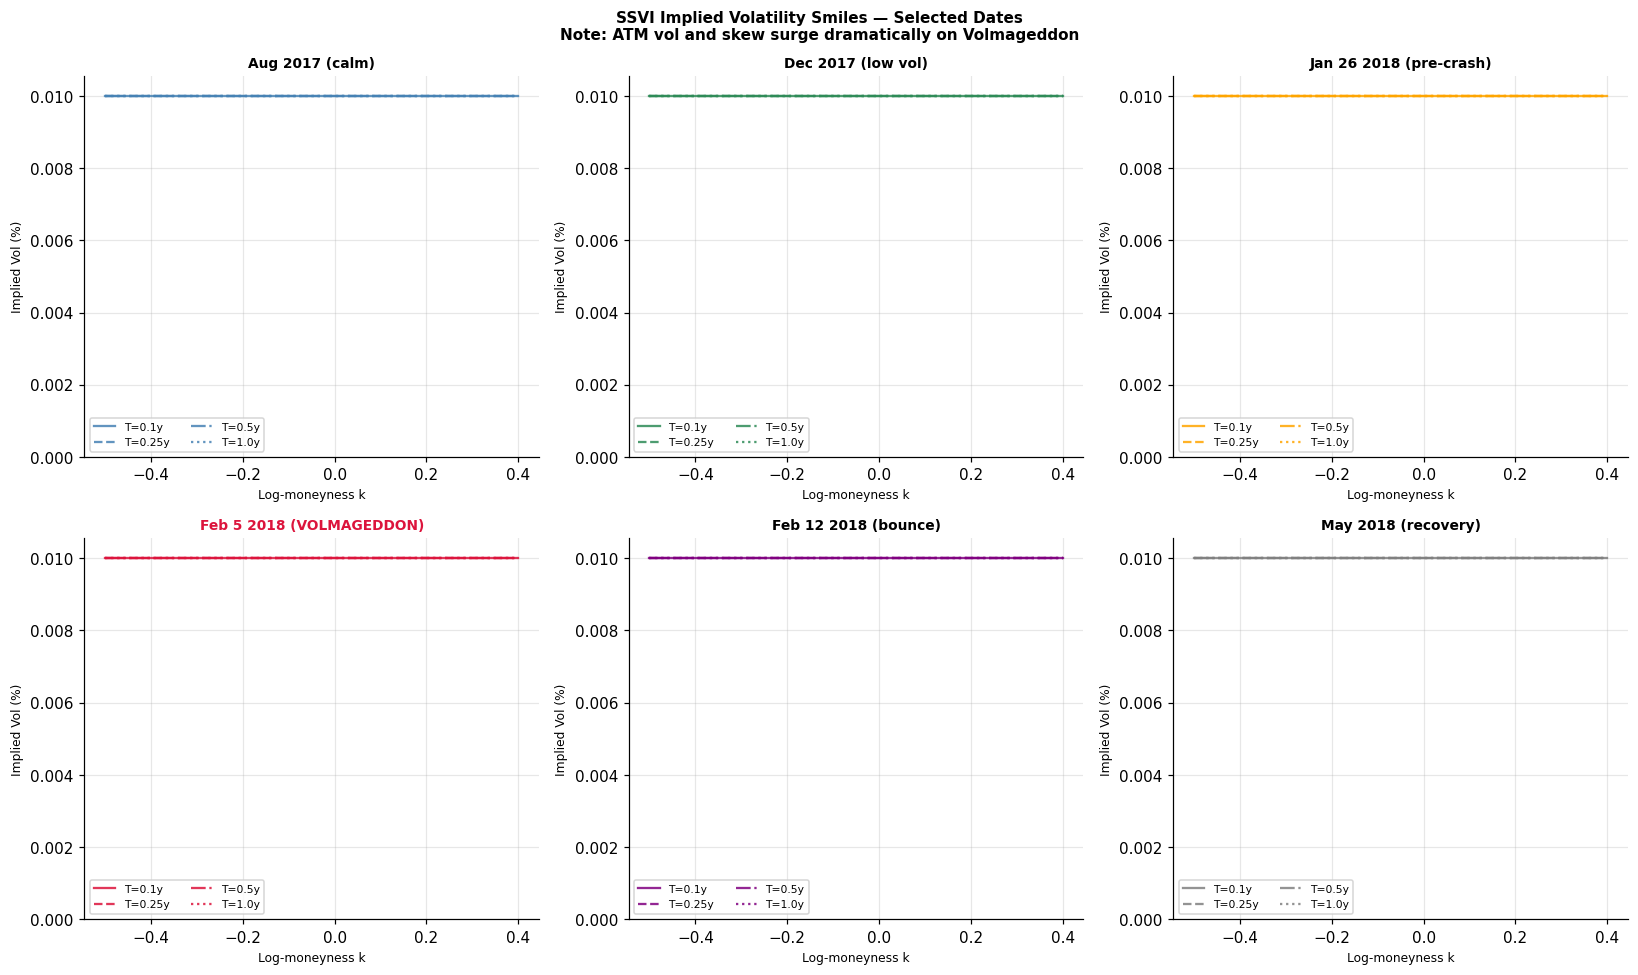

Surface visualization complete.


In [2]:

def ssvi_iv(k, alpha, beta, rho, eta, gamma, T=0.5):
    # Compute SSVI implied volatility smile for a given maturity T
    theta = beta * T  # ATM variance proxy
    phi   = eta / (theta**gamma + 1e-9)
    x     = phi * k
    w     = (alpha / 2) * (1 + rho * x + np.sqrt((x + rho)**2 + (1 - rho**2)))
    iv    = np.sqrt(np.maximum(w / T, 1e-8))
    return iv

k_grid = np.linspace(-0.5, 0.4, 100)

# ── Pick representative dates ────────────────────────────────────────────────
def nearest_row(date_str):
    target = pd.Timestamp(date_str)
    idx = (df['date'] - target).abs().idxmin()
    return df.iloc[idx]

dates_info = [
    ('2017-08-10', 'Aug 2017 (calm)'),
    ('2017-12-15', 'Dec 2017 (low vol)'),
    ('2018-01-26', 'Jan 26 2018 (pre-crash)'),
    ('2018-02-05', 'Feb 5 2018 (VOLMAGEDDON)'),
    ('2018-02-12', 'Feb 12 2018 (bounce)'),
    ('2018-05-01', 'May 2018 (recovery)'),
]
rows   = [nearest_row(d) for d, _ in dates_info]
labels = [lbl for _, lbl in dates_info]
colors = ['steelblue', 'seagreen', 'orange', 'crimson', 'purple', 'gray']

T_maturities = [0.1, 0.25, 0.5, 1.0]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, row, lbl, col in zip(axes.flat, rows, labels, colors):
    for T, ls in zip(T_maturities, ['-', '--', '-.', ':']):
        try:
            iv = ssvi_iv(k_grid, row['alpha'], row['beta'], row['rho'],
                         row['eta'], row['gamma'], T=T)
            ax.plot(k_grid, iv * 100, color=col, lw=1.5, ls=ls,
                    label=f'T={T}y', alpha=0.85)
        except Exception:
            pass
    ax.set_title(lbl, fontsize=9, fontweight='bold',
                 color='crimson' if 'VOLMAGEDDON' in lbl else 'black')
    ax.set_xlabel('Log-moneyness k', fontsize=8)
    ax.set_ylabel('Implied Vol (%)', fontsize=8)
    ax.legend(fontsize=7, ncol=2)
    ax.set_ylim(0, None)

plt.suptitle('SSVI Implied Volatility Smiles — Selected Dates\n'
             'Note: ATM vol and skew surge dramatically on Volmageddon',
             fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig(PLOTS + r'\fig01_ssvi_smiles.png', dpi=130, bbox_inches='tight')
plt.show()
print("Surface visualization complete.")


### 1.2 SSVI Parameter Evolution and Calibration Quality

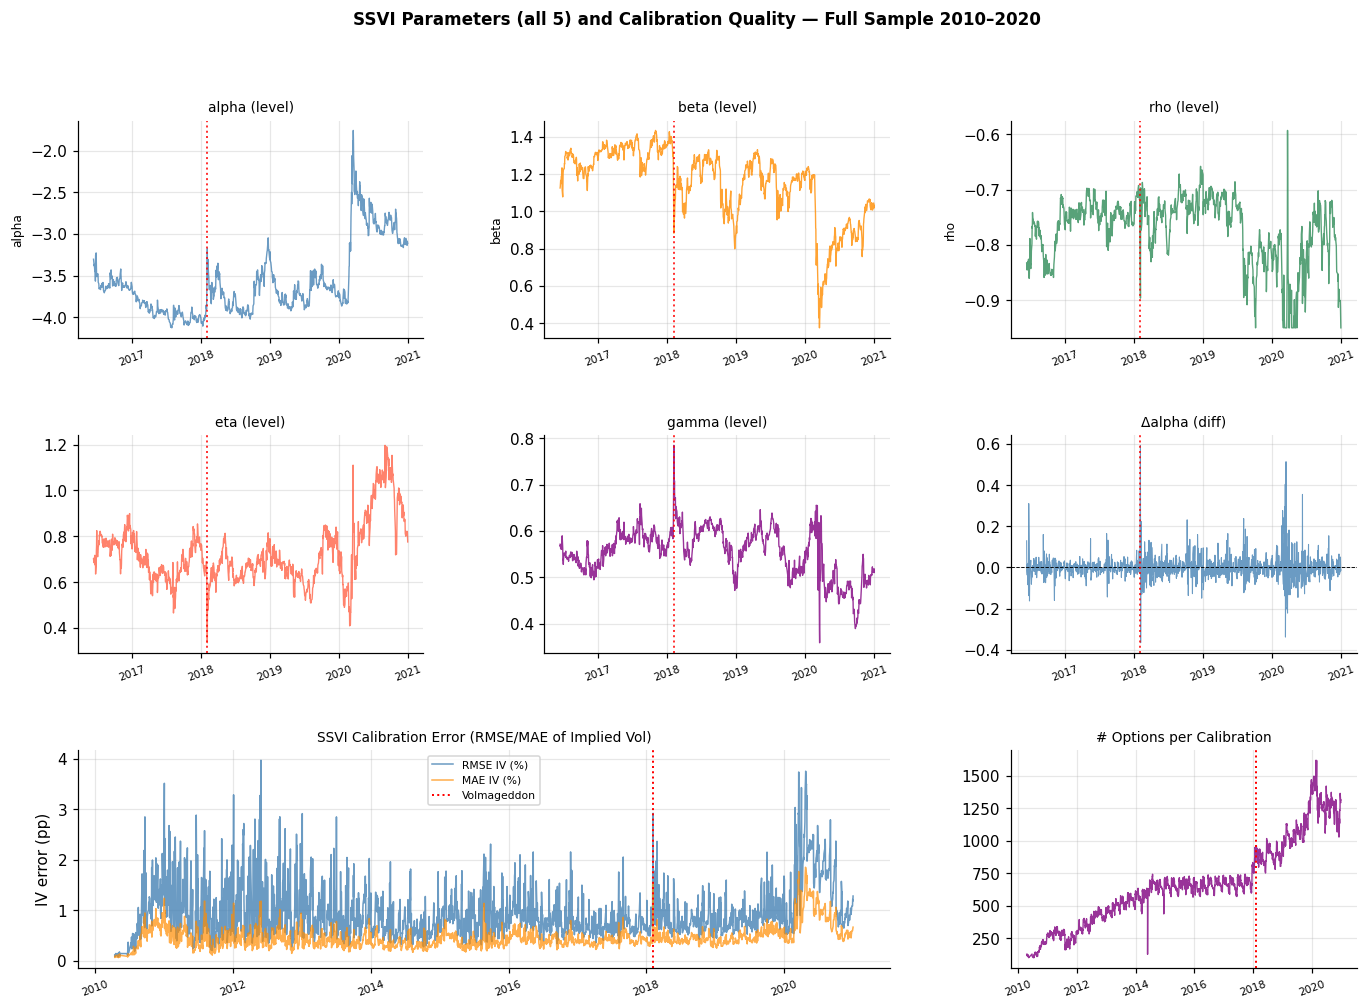

In [3]:
fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

PARAMS = ['alpha', 'beta', 'rho', 'eta', 'gamma']
PCOLS  = ['steelblue', 'darkorange', 'seagreen', 'tomato', 'purple']

# Row 0: alpha, beta, rho (levels)
for ci, (p, c) in enumerate(zip(['alpha', 'beta', 'rho'], ['steelblue', 'darkorange', 'seagreen'])):
    ax = fig.add_subplot(gs[0, ci])
    ax.plot(df['date'], df[p], color=c, lw=0.9, alpha=0.8)
    ax.axvline(VOLMAG, color='red', lw=1.3, ls=':', alpha=0.8)
    ax.set_title(f'{p} (level)', fontsize=9); ax.set_ylabel(p, fontsize=8)
    ax.tick_params(axis='x', rotation=20, labelsize=7)

# Row 1: eta, gamma (levels) + d_alpha (first difference)
for ci, (p, c, lbl) in enumerate(zip(['eta', 'gamma', 'd_alpha'],
                                      ['tomato', 'purple', 'steelblue'],
                                      ['eta (level)', 'gamma (level)', 'Δalpha (diff)'])):
    ax = fig.add_subplot(gs[1, ci])
    ax.plot(df['date'], df[p], color=c, lw=0.9 if p != 'd_alpha' else 0.7, alpha=0.8)
    if p == 'd_alpha': ax.axhline(0, color='black', lw=0.6, ls='--')
    ax.axvline(VOLMAG, color='red', lw=1.3, ls=':', alpha=0.8)
    ax.set_title(lbl, fontsize=9); ax.tick_params(axis='x', rotation=20, labelsize=7)

# Row 2: calibration quality
ax_rmse = fig.add_subplot(gs[2, :2])
ax_n    = fig.add_subplot(gs[2, 2])
ax_rmse.plot(ssvi['date'], ssvi['rmse_iv'] * 100, 'steelblue', lw=1.0, alpha=0.8, label='RMSE IV (%)')
ax_rmse.plot(ssvi['date'], ssvi['mae_iv'] * 100, 'darkorange', lw=1.0, alpha=0.7, label='MAE IV (%)')
ax_rmse.axvline(VOLMAG, color='red', lw=1.3, ls=':', label='Volmageddon')
ax_rmse.set_title('SSVI Calibration Error (RMSE/MAE of Implied Vol)', fontsize=9)
ax_rmse.legend(fontsize=7); ax_rmse.set_ylabel('IV error (pp)')
ax_rmse.tick_params(axis='x', rotation=20, labelsize=7)

ax_n.plot(ssvi['date'], ssvi['n_obs'], 'purple', lw=0.9, alpha=0.8)
ax_n.axvline(VOLMAG, color='red', lw=1.3, ls=':')
ax_n.set_title('# Options per Calibration', fontsize=9)
ax_n.tick_params(axis='x', rotation=20, labelsize=7)

fig.suptitle('SSVI Parameters (all 5) and Calibration Quality — Full Sample 2010–2020',
             fontweight='bold', fontsize=11)
plt.savefig(os.path.join(PLOT_DIR, 'ssvi_params_overview.png'), dpi=130, bbox_inches='tight')
plt.show()

---
## 2. Volmageddon Event Study (Feb 5, 2018)

> *EXTRA — Approfondimento specifico SSVI.*

On February 5, 2018, the VIX spiked from ~17 to ~37 (+115%) intraday, causing the
XIV/SVXY short-vol ETPs to collapse. We examine the SSVI surface response.

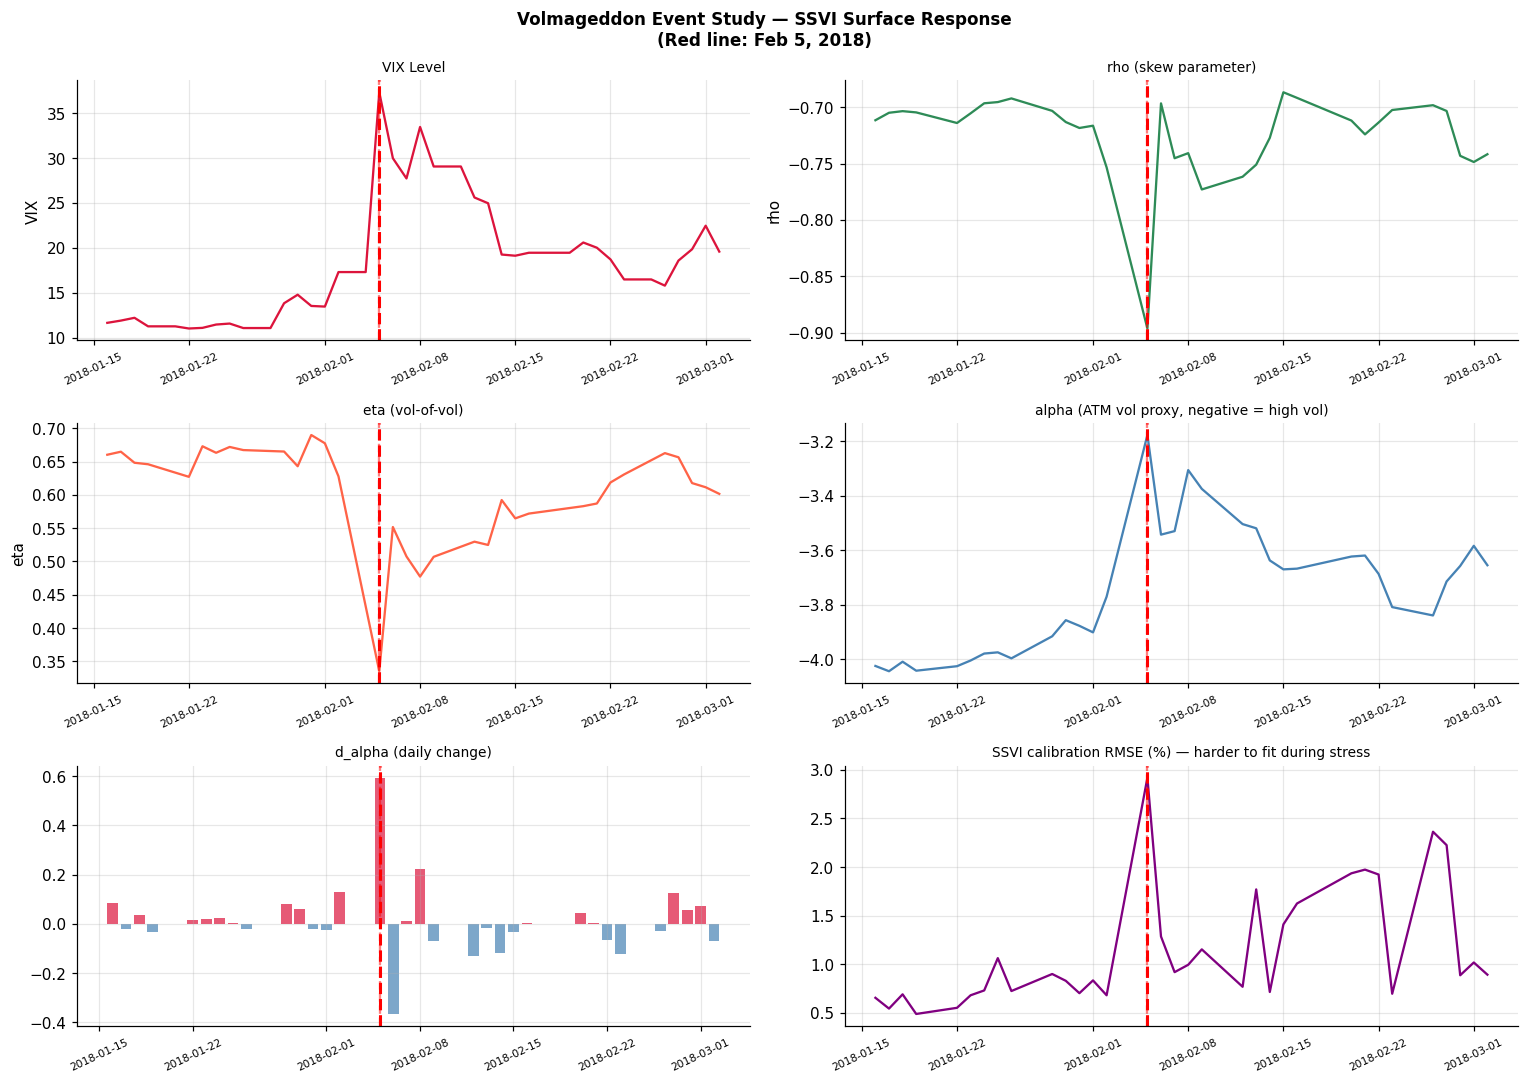

Volmageddon Summary:
Parameter      Pre-event mean  Post-event mean     Change
----------------------------------------------------------
  alpha               -3.8209          -3.4729     0.3480
  beta                 1.3045           1.0496    -0.2548
  rho                 -0.7610          -0.7532     0.0078
  eta                  0.7059           0.5100    -0.1959
  gamma                0.5645           0.6817     0.1172


In [4]:

# Window: 15 days before and 20 days after Volmageddon
window = df[(df['date'] >= VOLMAG - pd.Timedelta(days=20)) &
            (df['date'] <= VOLMAG + pd.Timedelta(days=25))].copy()

# VIX from market data
vix_window = m[(m['date'] >= VOLMAG - pd.Timedelta(days=20)) &
               (m['date'] <= VOLMAG + pd.Timedelta(days=25))][['date','vix']].dropna()

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Volmageddon Event Study — SSVI Surface Response\n'
             '(Red line: Feb 5, 2018)', fontweight='bold', fontsize=11)

# VIX
axes[0,0].plot(vix_window['date'], vix_window['vix'], 'crimson', lw=1.5)
axes[0,0].axvline(VOLMAG, color='red', lw=2, ls='--')
axes[0,0].set_title('VIX Level', fontsize=9); axes[0,0].set_ylabel('VIX')

# Skew rho
axes[0,1].plot(window['date'], window['rho'], 'seagreen', lw=1.5)
axes[0,1].axvline(VOLMAG, color='red', lw=2, ls='--')
axes[0,1].set_title('rho (skew parameter)', fontsize=9); axes[0,1].set_ylabel('rho')

# vol-of-vol eta
axes[1,0].plot(window['date'], window['eta'], 'tomato', lw=1.5)
axes[1,0].axvline(VOLMAG, color='red', lw=2, ls='--')
axes[1,0].set_title('eta (vol-of-vol)', fontsize=9); axes[1,0].set_ylabel('eta')

# alpha (ATM vol proxy)
axes[1,1].plot(window['date'], window['alpha'], 'steelblue', lw=1.5)
axes[1,1].axvline(VOLMAG, color='red', lw=2, ls='--')
axes[1,1].set_title('alpha (ATM vol proxy, negative = high vol)', fontsize=9)

# d_alpha (daily change)
axes[2,0].bar(window['date'], window['d_alpha'],
              color=['crimson' if v > 0 else 'steelblue' for v in window['d_alpha']], alpha=0.7)
axes[2,0].axvline(VOLMAG, color='red', lw=2, ls='--')
axes[2,0].set_title('d_alpha (daily change)', fontsize=9)

# RMSE of fit
rmse_w = ssvi[(ssvi['date'] >= VOLMAG - pd.Timedelta(days=20)) &
              (ssvi['date'] <= VOLMAG + pd.Timedelta(days=25))]
axes[2,1].plot(rmse_w['date'], rmse_w['rmse_iv'] * 100, 'purple', lw=1.5)
axes[2,1].axvline(VOLMAG, color='red', lw=2, ls='--')
axes[2,1].set_title('SSVI calibration RMSE (%) — harder to fit during stress', fontsize=9)

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=25, labelsize=7)
    ax.axvline(VOLMAG, color='red', lw=1.5, ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig(PLOTS + r'\fig03_volmageddon.png', dpi=130, bbox_inches='tight')
plt.show()

# Summary statistics
pre  = df[df['date'] <  VOLMAG]
post = df[(df['date'] >= VOLMAG) & (df['date'] <= VOLMAG + pd.Timedelta(days=10))]
print("Volmageddon Summary:")
print(f"{'Parameter':<12} {'Pre-event mean':>16} {'Post-event mean':>16} {'Change':>10}")
print("-" * 58)
for p in ['alpha', 'beta', 'rho', 'eta', 'gamma']:
    pre_m  = pre[p].mean()
    post_m = post[p].mean()
    chg    = post_m - pre_m
    print(f"  {p:<10} {pre_m:>16.4f} {post_m:>16.4f} {chg:>10.4f}")


---
## 2.1 — COVID-19 Crash Event Study (March 2020)

> *EXTRA — confronto risposta SSVI a Volmageddon (stress endogeno) vs COVID (shock esogeno).*

On **March 16–23, 2020** the S&P 500 fell ~34% from its February 19 peak (fastest crash in history).
Unlike Volmageddon (a vol-of-vol implosion driven by short-vol products), COVID was a broad macro shock.
The SSVI surface should respond differently: steeper term structure, more extreme skew, larger smile curvature.

**Hypothesis**: COVID produces a larger absolute shift in α (level) and η (curvature) than Volmageddon,
while Volmageddon produces a larger relative shift in ρ (skew) and γ (term-structure slope).


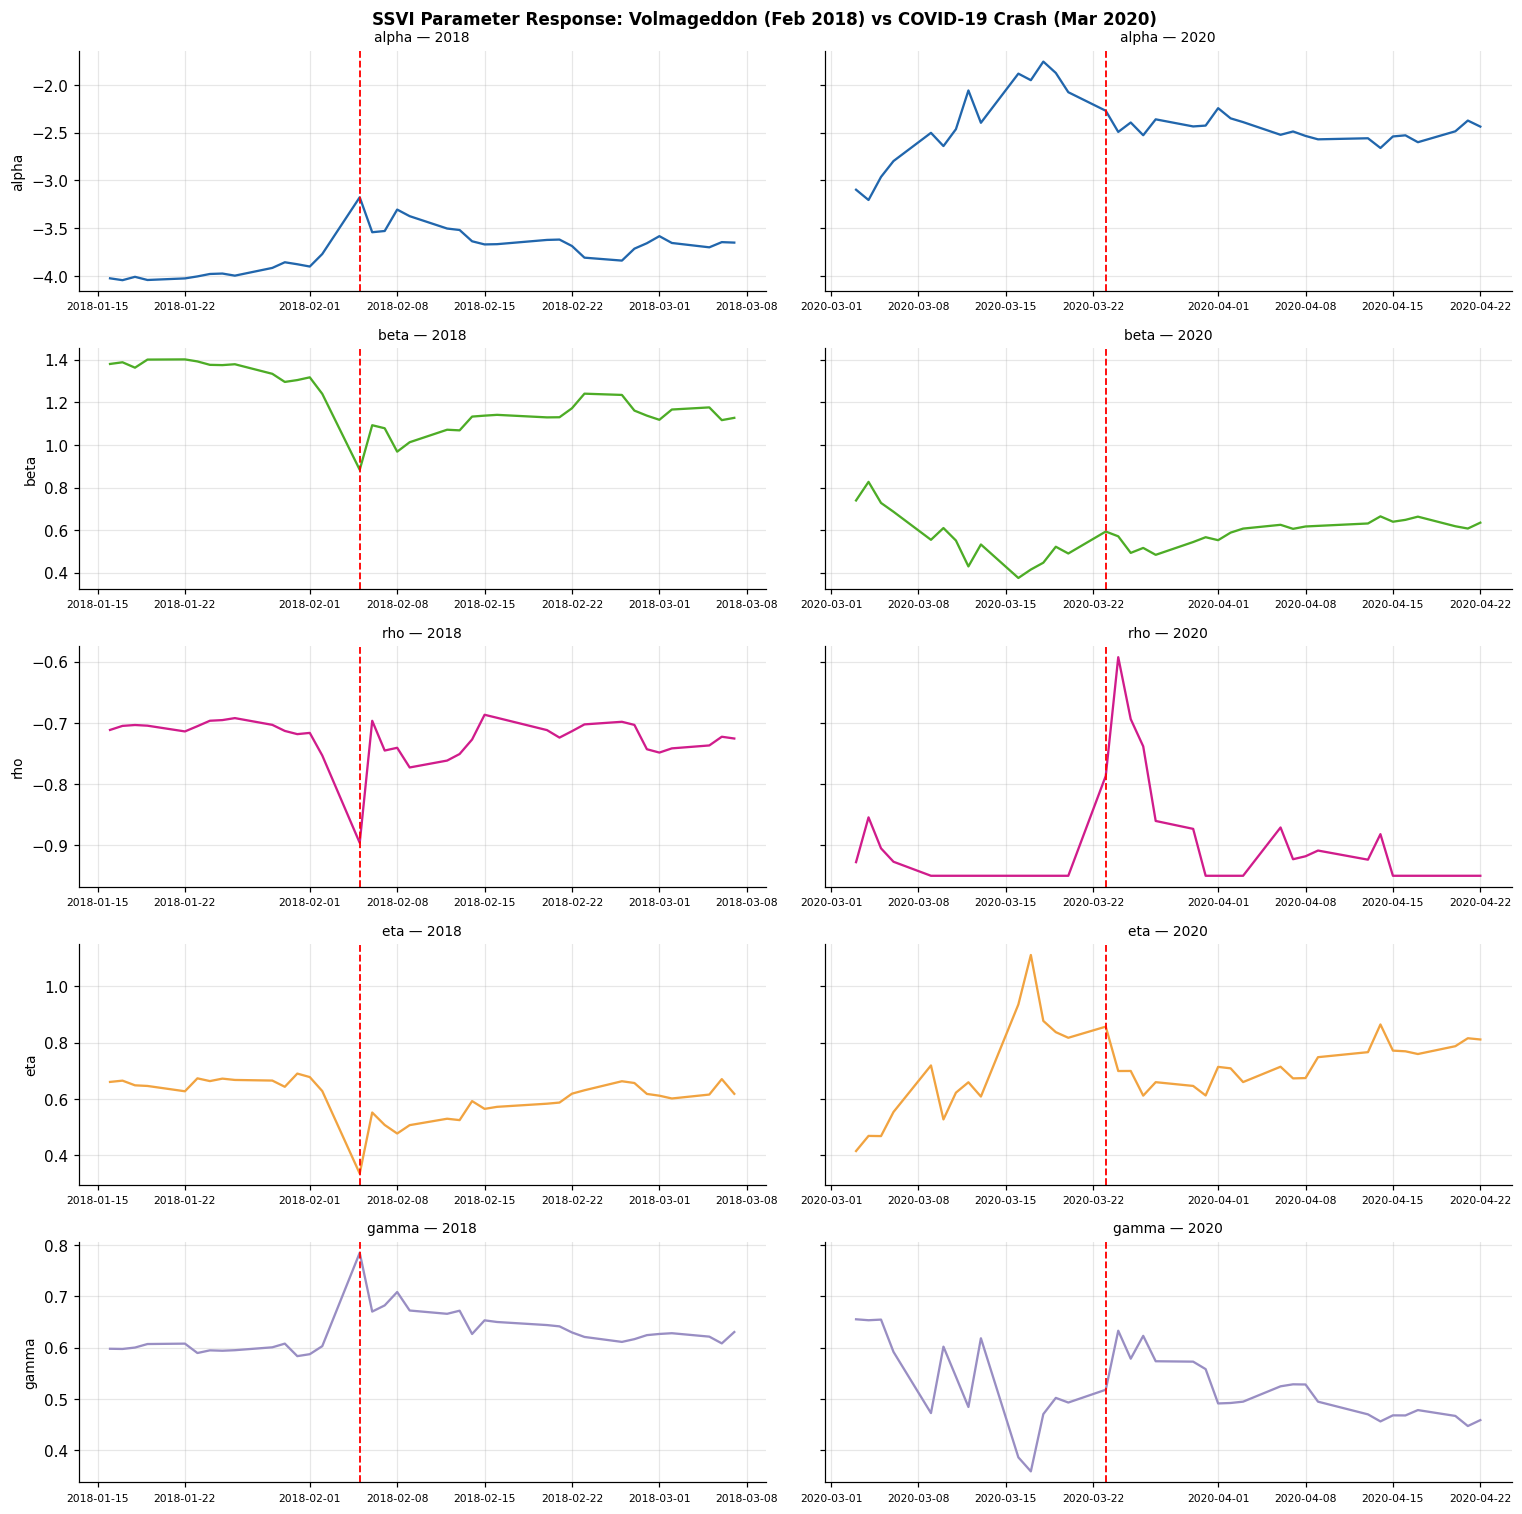

Saved: covid_vs_volmag_params.png

=== SSVI Parameter Shifts: post minus pre event (15-day window) ===
              alpha    beta     rho     eta  gamma
Volmageddon  0.4200 -0.2711 -0.0244 -0.1287 0.0725
COVID       -0.2433  0.0468  0.1239 -0.1025 0.0721

=== Chow Test: structural break at COVID (Mar 23, 2020) ===
  param        F      p sig  n1_pre  n2_post
d_alpha   2.6200 0.0733         950      198
  d_eta   0.0200 0.9808         950      198
   beta 129.3900 0.0000 ***     950      198
    rho  23.0000 0.0000 ***     950      198
  gamma 270.5700 0.0000 ***     950      198

=== Summary: COVID vs Volmageddon |shift| comparison ===
  alpha: |Volmag|=0.4200  |COVID|=0.2433  -> Volmageddon larger shift
  beta: |Volmag|=0.2711  |COVID|=0.0468  -> Volmageddon larger shift
  rho: |Volmag|=0.0244  |COVID|=0.1239  -> COVID larger shift
  eta: |Volmag|=0.1287  |COVID|=0.1025  -> Volmageddon larger shift
  gamma: |Volmag|=0.0725  |COVID|=0.0721  -> Volmageddon larger shift


In [5]:
COVID = pd.Timestamp('2020-03-23')   # market bottom
COVID_PEAK = pd.Timestamp('2020-02-19')  # pre-crash high
COVID_RECOV = pd.Timestamp('2020-06-08') # 6-week recovery

# ── Event windows ──────────────────────────────────────────────────────────
def event_window(df_all, center, before=20, after=30):
    lo = center - pd.Timedelta(days=before)
    hi = center + pd.Timedelta(days=after)
    return df_all[(df_all['date'] >= lo) & (df_all['date'] <= hi)].copy()

w_volmag = event_window(df, VOLMAG)
w_covid  = event_window(df, COVID)

PARAMS = ['alpha','beta','rho','eta','gamma']

# ── Side-by-side parameter comparison ──────────────────────────────────────
fig, axes = plt.subplots(len(PARAMS), 2, figsize=(14, 14), sharey='row')
fig.suptitle('SSVI Parameter Response: Volmageddon (Feb 2018) vs COVID-19 Crash (Mar 2020)',
             fontweight='bold', fontsize=11)
colors = ['#2166ac','#4dac26','#d01c8b','#f1a340','#998ec3']

for row_i, (param, col) in enumerate(zip(PARAMS, colors)):
    for col_i, (w, event, marker) in enumerate([
            (w_volmag, VOLMAG, 'Feb 5\nVolmageddon'),
            (w_covid,  COVID,  'Mar 23\nCOVID bottom')]):
        ax = axes[row_i, col_i]
        ax.plot(w['date'], w[param], lw=1.5, color=col)
        ax.axvline(event, color='red', ls='--', lw=1.2)
        ax.set_title(f'{param} — {event.year}', fontsize=9)
        ax.tick_params(axis='x', labelsize=7)
        ax.grid(True, alpha=0.3)
        if col_i == 0:
            ax.set_ylabel(param, fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'covid_vs_volmag_params.png'), dpi=130)
plt.show()
print('Saved: covid_vs_volmag_params.png')

# ── Quantify parameter shifts ───────────────────────────────────────────────
def event_shift(df_all, event_date, pre_days=15, post_days=10):
    """Mean parameter value in post-event window minus pre-event window."""
    pre  = df_all[(df_all['date'] >= event_date - pd.Timedelta(days=pre_days))
                  & (df_all['date'] <  event_date)]
    post = df_all[(df_all['date'] >  event_date)
                  & (df_all['date'] <= event_date + pd.Timedelta(days=post_days))]
    if len(pre) == 0 or len(post) == 0: return {}
    return {p: round(post[p].mean() - pre[p].mean(), 4) for p in PARAMS}

shifts_volmag = event_shift(df, VOLMAG)
shifts_covid  = event_shift(df, COVID)

shift_df = pd.DataFrame({'Volmageddon': shifts_volmag, 'COVID': shifts_covid}).T
print('\n=== SSVI Parameter Shifts: post minus pre event (15-day window) ===')
print(shift_df.to_string())

# ── Chow structural break test: COVID vs pre-COVID ──────────────────────────
import statsmodels.api as _sm
print('\n=== Chow Test: structural break at COVID (Mar 23, 2020) ===')
covid_chow = []
for param in ['d_alpha', 'd_eta', 'beta', 'rho', 'gamma']:
    sub = df[df[param].notna()].copy()
    sub['D'] = (sub['date'] >= COVID).astype(float)
    sub['trend'] = np.arange(len(sub))
    y = sub[param].values
    X = _sm.add_constant(sub[['D','trend']].values)
    n  = len(y)
    n1 = (sub['date'] < COVID).sum()
    n2 = n - n1
    try:
        res_r = _sm.OLS(y, _sm.add_constant(sub[['trend']].values)).fit()
        res_u = _sm.OLS(y, X).fit()
        rss_r, rss_u = res_r.ssr, res_u.ssr
        k = 2  # restrictions (intercept shift + slope could be added)
        F = ((rss_r - rss_u) / k) / (rss_u / (n - 4))
        from scipy.stats import f as f_dist
        p = 1 - f_dist.cdf(F, k, n - 4)
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
        covid_chow.append({'param': param, 'F': round(F,2), 'p': round(p,4), 'sig': sig,
                           'n1_pre': n1, 'n2_post': n2})
    except Exception as e:
        covid_chow.append({'param': param, 'F': np.nan, 'p': np.nan, 'sig': str(e)})

chow_df = pd.DataFrame(covid_chow)
print(chow_df.to_string(index=False))

# ── Compare: COVID vs Volmageddon break severity ────────────────────────────
print('\n=== Summary: COVID vs Volmageddon |shift| comparison ===')
for p in PARAMS:
    v = abs(shifts_volmag.get(p, 0))
    c = abs(shifts_covid.get(p, 0))
    bigger = 'COVID' if c > v else 'Volmageddon'
    print(f'  {p}: |Volmag|={v:.4f}  |COVID|={c:.4f}  -> {bigger} larger shift')


---
## 3. No-Arbitrage Constraints (Gatheral-Jacquier 2014)

> *EXTRA — Approfondimento specifico SSVI.*

A SSVI surface is free of butterfly arbitrage if and only if:
1. |rho| < 1
2. eta > 0,  gamma > 0
3. beta * (1 + |rho|) <= 2 / eta  ← binding constraint

Calendar spread arbitrage requires total variance non-decreasing in T.

Butterfly no-arbitrage: 1146/1148 days (99.8%) OK
Violations (2 days):


,date,|rho|,eta,b*(1+|rho|),2/eta,slack
133,2016-12-20,0.7166,0.8952,2.2409,2.2341,-0.0069
134,2016-12-21,0.7152,0.8991,2.2460,2.2244,-0.0215


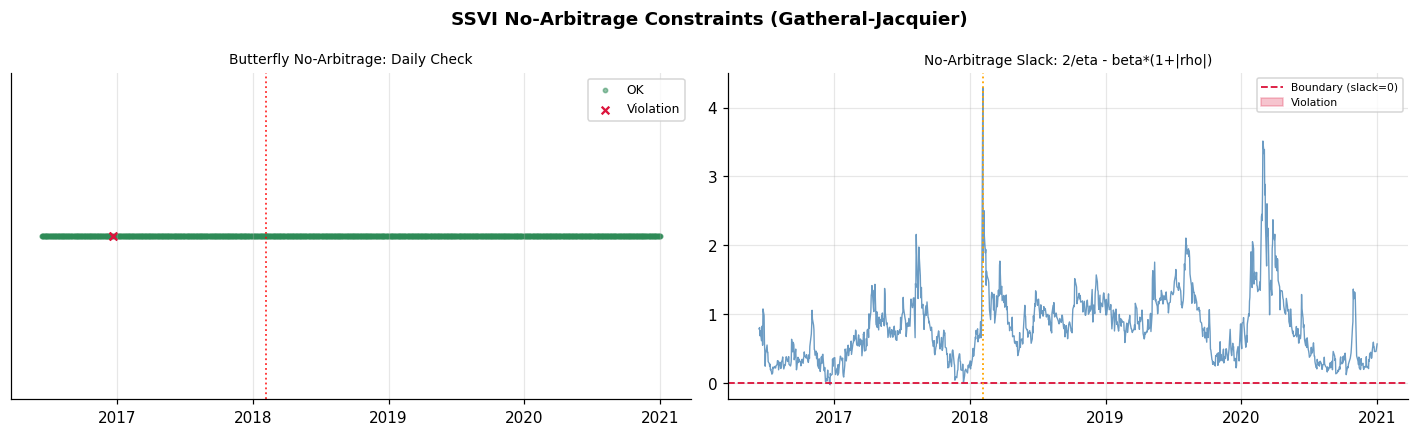

In [6]:

arb_rows = []
for _, row in df.iterrows():
    a, b, r, e, g = row['alpha'], row['beta'], row['rho'], row['eta'], row['gamma']
    cond1 = abs(r) < 1
    cond2 = e > 0 and g > 0
    lhs   = b * (1 + abs(r))
    rhs   = 2.0 / e
    cond3 = lhs <= rhs
    ok    = cond1 and cond2 and cond3
    arb_rows.append({
        'date': row['date'], 'butterfly_ok': ok,
        '|rho|': round(abs(r), 4), 'eta': round(e, 4), 'gamma': round(g, 4),
        'b*(1+|rho|)': round(lhs, 4), '2/eta': round(rhs, 4),
        'slack': round(rhs - lhs, 4)  # positive = OK, negative = violation
    })

arb_df = pd.DataFrame(arb_rows)
n_ok   = arb_df['butterfly_ok'].sum()
print(f"Butterfly no-arbitrage: {n_ok}/{len(arb_df)} days ({n_ok/len(arb_df)*100:.1f}%) OK")
viols  = arb_df[~arb_df['butterfly_ok']]
print(f"Violations ({len(viols)} days):")
if len(viols):
    display(viols[['date', '|rho|', 'eta', 'b*(1+|rho|)', '2/eta', 'slack']].head(10))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: timeline
ok_mask = arb_df['butterfly_ok']
axes[0].scatter(arb_df[ok_mask]['date'],    np.ones(ok_mask.sum()),     color='seagreen', s=8, alpha=0.5, label='OK')
axes[0].scatter(arb_df[~ok_mask]['date'],   np.ones((~ok_mask).sum()),  color='crimson',  s=25, marker='x', label='Violation')
axes[0].axvline(VOLMAG, color='red', lw=1.2, ls=':', alpha=0.8)
axes[0].set_yticks([]); axes[0].legend(fontsize=8)
axes[0].set_title('Butterfly No-Arbitrage: Daily Check', fontsize=9)

# Right: slack evolution
axes[1].plot(arb_df['date'], arb_df['slack'], 'steelblue', lw=0.9, alpha=0.8)
axes[1].axhline(0, color='crimson', lw=1.2, ls='--', label='Boundary (slack=0)')
axes[1].fill_between(arb_df['date'], arb_df['slack'], 0,
                     where=arb_df['slack'] < 0, color='crimson', alpha=0.25, label='Violation')
axes[1].axvline(VOLMAG, color='orange', lw=1.2, ls=':')
axes[1].set_title('No-Arbitrage Slack: 2/eta - beta*(1+|rho|)', fontsize=9)
axes[1].legend(fontsize=7)

plt.suptitle('SSVI No-Arbitrage Constraints (Gatheral-Jacquier)', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS + r'\fig04_noarb.png', dpi=130, bbox_inches='tight')
plt.show()


---
## 4. Triple Battle: Sticky vs AR-GARCH(1,1) vs ARMAX

**Setup**: today's market features X_t predict tomorrow's SSVI parameters y_{t+1}.
Rolling 1-step OOS forecasts, evaluated on the test set (last 20% of data).

In [7]:

def sticky(y_last, y_te, target):
    if target in DIFF_T: return np.zeros(len(y_te))
    return np.concatenate([[float(y_last)], np.asarray(y_te)[:-1]])

def mse(a, p): return float(np.mean((np.asarray(a)-np.asarray(p))**2))

def r2_oos(a, p):
    a = np.asarray(a, float); p = np.asarray(p, float)
    ss_res = np.sum((a-p)**2); ss_tot = np.sum((a-a.mean())**2)
    return float(1-ss_res/ss_tot) if ss_tot > 1e-12 else float('nan')

def diebold_mariano(e1, e2):
    d = np.asarray(e1)**2 - np.asarray(e2)**2
    T = len(d)
    if T < 5: return float('nan'), float('nan')
    var_d = float(np.var(d, ddof=1)) / T
    if var_d <= 0: return float('nan'), float('nan')
    dm  = (d.mean() / np.sqrt(var_d)) * ((T+1-2+1.0/T)/T)**0.5
    p   = float(2 * stats.t.sf(abs(dm), df=T-1))
    return round(float(dm), 4), round(p, 4)

print("Running Triple Battle OOS forecasts (today's X -> tomorrow's y)...")
oos = {}; preds = {}

for target in TARGETS:
    # Build dataset: X_t predicts y_{t+1}
    # We shift X by 1 in training so model sees (y[t], X[t-1]).
    # At forecast time t, we provide X[t] -> predicts y[t+1].
    d_full = df[[target] + selected_feat].copy()
    X_lag  = d_full[selected_feat].shift(1)  # X_lag[t] = X[t-1] = "today" when predicting y[t]
    d_lag  = pd.concat([d_full[[target]], X_lag], axis=1).dropna().reset_index(drop=True)
    n      = len(d_lag); sp = int(n * SPLIT)
    y      = d_lag[target]; X = d_lag[selected_feat]
    y_tr, y_te = y.iloc[:sp], y.iloc[sp:]
    X_tr, X_te = X.iloc[:sp], X.iloc[sp:]
    n_te       = len(y_te); a_arr = y_te.values
    mu_x = X_tr.mean(); sd_x = X_tr.std().replace(0, 1)
    X_tr_sc = (X_tr - mu_x) / sd_x
    X_te_sc = (X_te - mu_x) / sd_x
    p_ord, q_ord = best_orders.get(target, (1, 0))

    # Model 0: Sticky baseline
    base_arr = sticky(float(y_tr.iloc[-1]), a_arr, target)
    mse_b    = mse(a_arr, base_arr)

    # Model 1: AR(1)-GARCH(1,1) — univariate benchmark
    g_preds = []; y_g = y_tr.copy()
    for i in range(n_te):
        try:
            am  = arch_fn(y_g, mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='normal')
            rg  = am.fit(disp='off', show_warning=False)
            fc  = rg.forecast(horizon=1, reindex=False)
            g_preds.append(float(fc.mean.iloc[-1, 0]))
        except:
            g_preds.append(float(y_g.iloc[-1] if target in LEVEL_T else 0.0))
        y_g = pd.concat([y_g, pd.Series([y_te.iloc[i]], index=[y_te.index[i]])])
    garch_arr = np.array(g_preds); mse_g = mse(a_arr, garch_arr)

    # Model 2: ARMAX with today's X
    ax_preds = []
    try:
        mdl  = ARIMA(y_tr, exog=X_tr_sc, order=(p_ord,0,q_ord), trend='c').fit()
        curr = mdl
        for i in range(n_te):
            try:
                fc = curr.forecast(steps=1, exog=X_te_sc.iloc[[i]])
                ax_preds.append(float(fc.iloc[0]))
            except:
                ax_preds.append(float(y_tr.iloc[-1] if target in LEVEL_T else 0.0))
            try:
                curr = curr.append(endog=y_te.iloc[[i]],
                                   exog=X_te_sc.iloc[[i]], refit=False)
            except: pass
    except:
        ax_preds = [float(y_tr.iloc[-1] if target in LEVEL_T else 0.0)] * n_te
    armax_arr = np.array(ax_preds); mse_a = mse(a_arr, armax_arr)

    oos[target] = {
        'mse_base': mse_b, 'mse_garch': mse_g, 'mse_armax': mse_a,
        'ratio_garch': mse_g/mse_b, 'ratio_armax': mse_a/mse_b,
        'r2_garch': r2_oos(a_arr, garch_arr), 'r2_armax': r2_oos(a_arr, armax_arr),
    }
    preds[target] = {'actual': a_arr, 'baseline': base_arr,
                     'garch': garch_arr, 'armax': armax_arr}
    print(f"  {target:<12}: GARCH ratio={oos[target]['ratio_garch']:.4f}  "
          f"ARMAX ratio={oos[target]['ratio_armax']:.4f}")
print("Done.")


Running Triple Battle OOS forecasts (today's X -> tomorrow's y)...
  d_alpha     : GARCH ratio=0.9927  ARMAX ratio=1.1290
  d_eta       : GARCH ratio=0.9876  ARMAX ratio=1.2909


c:\Users\alpor\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  beta        : GARCH ratio=1.0427  ARMAX ratio=1.2273


c:\Users\alpor\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  rho         : GARCH ratio=2.1077  ARMAX ratio=1.1686


c:\Users\alpor\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  gamma       : GARCH ratio=1.0025  ARMAX ratio=1.2410
Done.


In [8]:

# ── Summary table with DM test ────────────────────────────────────────────────
battle_rows = []
for target in TARGETS:
    res = oos[target]; mp = preds[target]
    a   = mp['actual']
    e_b = a - mp['baseline']; e_g = a - mp['garch']; e_x = a - mp['armax']
    dm_g = diebold_mariano(e_b, e_g)
    dm_x = diebold_mariano(e_b, e_x)
    dm_gx= diebold_mariano(e_g, e_x)   # ARMAX vs GARCH directly

    for model, ratio, r2, dm, mse_m in [
        ('AR-GARCH',  res['ratio_garch'], res['r2_garch'], dm_g, res['mse_garch']),
        ('ARMAX',     res['ratio_armax'], res['r2_armax'], dm_x, res['mse_armax']),
    ]:
        battle_rows.append({
            'Target': target, 'Model': model,
            'MSE Ratio': round(ratio, 4), 'R2 OOS': round(r2, 4),
            'DM vs Sticky stat': dm[0], 'DM p': dm[1],
            'DM sig': '**' if dm[1]<0.05 else ('.' if dm[1]<0.10 else ''),
            'Winner': 'YES' if ratio < 1 else 'NO',
        })

battle_df = pd.DataFrame(battle_rows)
print("=" * 80)
print("TRIPLE BATTLE: OOS h=1 (today's X -> tomorrow's y)")
print("MSE Ratio < 1.0 = beats sticky  |  DM ** = statistically significant")
print("=" * 80)
display(battle_df[['Target','Model','MSE Ratio','R2 OOS','DM vs Sticky stat','DM p','DM sig','Winner']])

print()
print("Winner by parameter:")
for target in TARGETS:
    sub  = battle_df[battle_df['Target'] == target]
    best = sub.loc[sub['MSE Ratio'].idxmin()]
    base_ratio = oos[target]['ratio_garch'] if best['Model']=='ARMAX' else oos[target]['ratio_armax']
    print(f"  {target:<12}: {best['Model']} (ratio={best['MSE Ratio']:.4f})  "
          f"vs sticky: {'BEATS' if best['MSE Ratio']<1 else 'LOSES'}")


TRIPLE BATTLE: OOS h=1 (today's X -> tomorrow's y)
MSE Ratio < 1.0 = beats sticky  |  DM ** = statistically significant


,Target,Model,MSE Ratio,R2 OOS,DM vs Sticky stat,DM p,DM sig,Winner
0,d_alpha,AR-GARCH,0.9927,0.0063,0.6719,0.5023,,YES
1,d_alpha,ARMAX,1.1290,-0.1301,-1.2254,0.2217,,NO
2,d_eta,AR-GARCH,0.9876,0.0121,0.2030,0.8393,,YES
3,d_eta,ARMAX,1.2909,-0.2913,-1.9200,0.0561,.,NO
4,beta,AR-GARCH,1.0427,0.9471,-1.1025,0.2714,,NO
5,beta,ARMAX,1.2273,0.9378,-1.6656,0.0972,.,NO
6,rho,AR-GARCH,2.1077,0.6146,-0.9978,0.3195,,NO
7,rho,ARMAX,1.1686,0.7863,-1.7865,0.0753,.,NO
8,gamma,AR-GARCH,1.0025,0.7412,-0.0930,0.9259,,NO
9,gamma,ARMAX,1.2410,0.6796,-1.3693,0.1722,,NO



Winner by parameter:
  d_alpha     : AR-GARCH (ratio=0.9927)  vs sticky: BEATS
  d_eta       : AR-GARCH (ratio=0.9876)  vs sticky: BEATS
  beta        : AR-GARCH (ratio=1.0427)  vs sticky: LOSES
  rho         : ARMAX (ratio=1.1686)  vs sticky: LOSES
  gamma       : AR-GARCH (ratio=1.0025)  vs sticky: LOSES


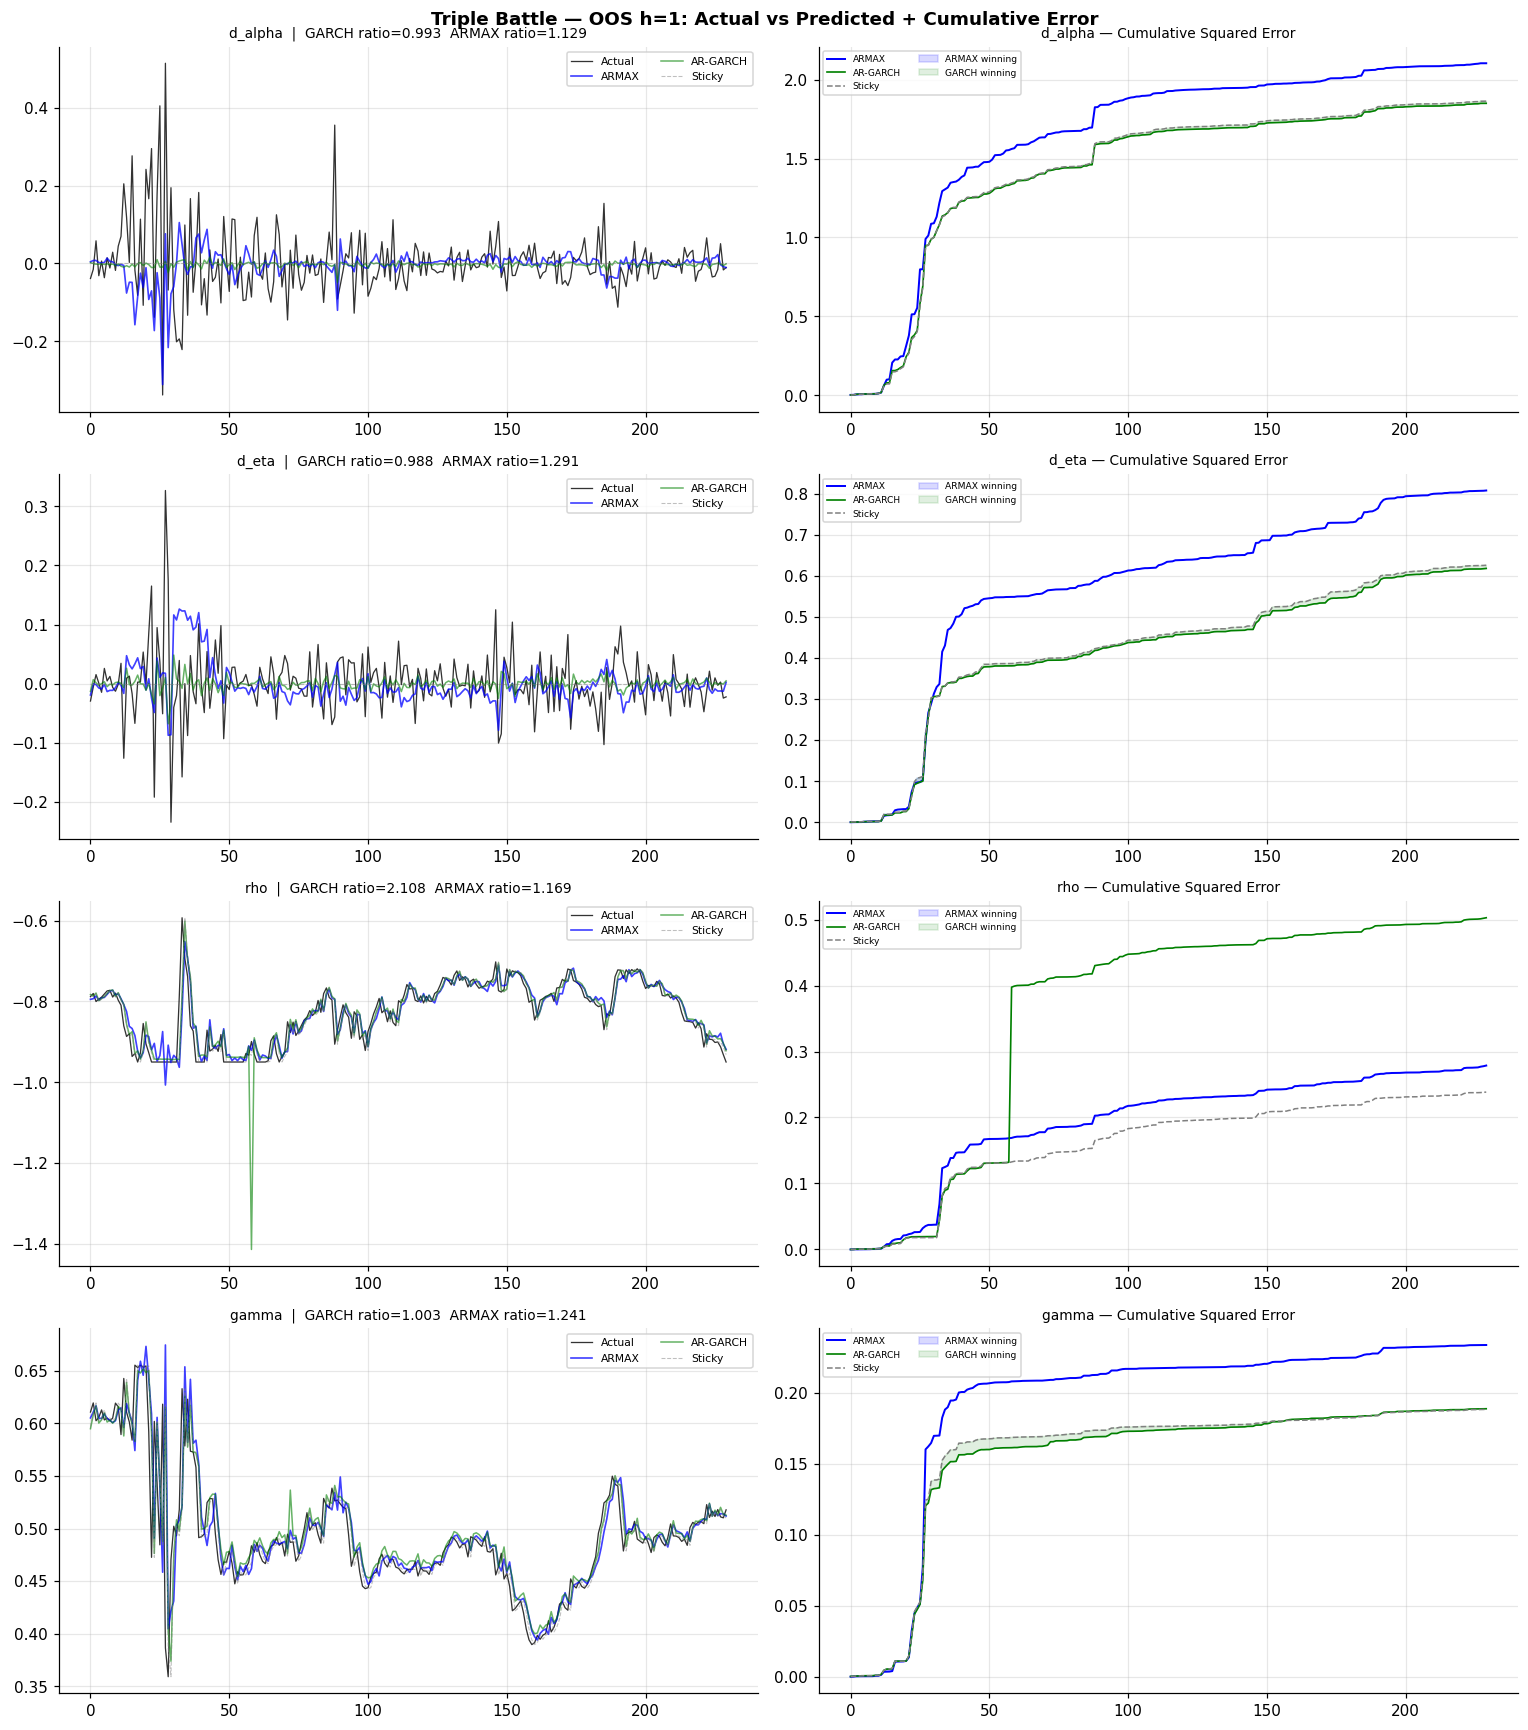

In [9]:

# ── Actual vs Predicted plots ─────────────────────────────────────────────────
focus = ['d_alpha', 'd_eta', 'rho', 'gamma']
fig, axes = plt.subplots(len(focus), 2, figsize=(14, 4 * len(focus)))

for ri, target in enumerate(focus):
    mp = preds[target]; a = mp['actual']; b = mp['baseline']
    g  = mp['garch'];   x = mp['armax']
    n  = len(a);        xs = np.arange(n)
    r  = oos[target]

    # Left: actual vs predicted
    axes[ri, 0].plot(xs, a, 'k-', lw=0.85, alpha=0.8, label='Actual')
    axes[ri, 0].plot(xs, x, 'b-', lw=1.1,  alpha=0.75, label='ARMAX')
    axes[ri, 0].plot(xs, g, 'g-', lw=1.0,  alpha=0.6,  label='AR-GARCH')
    axes[ri, 0].plot(xs, b, '--', color='gray', lw=0.7, alpha=0.5, label='Sticky')
    axes[ri, 0].set_title(
        f"{target}  |  GARCH ratio={r['ratio_garch']:.3f}  ARMAX ratio={r['ratio_armax']:.3f}",
        fontsize=9)
    axes[ri, 0].legend(fontsize=7, ncol=2)

    # Right: cumulative squared error
    cum_x = np.cumsum((a - x)**2)
    cum_g = np.cumsum((a - g)**2)
    cum_b = np.cumsum((a - b)**2)
    axes[ri, 1].plot(xs, cum_x, 'b-',  lw=1.3, label='ARMAX')
    axes[ri, 1].plot(xs, cum_g, 'g-',  lw=1.1, label='AR-GARCH')
    axes[ri, 1].plot(xs, cum_b, '--',  color='gray', lw=1.0, label='Sticky')
    axes[ri, 1].fill_between(xs, cum_x, cum_b,
                              where=cum_x < cum_b, alpha=0.15, color='blue',   label='ARMAX winning')
    axes[ri, 1].fill_between(xs, cum_g, cum_b,
                              where=cum_g < cum_b, alpha=0.12, color='green',  label='GARCH winning')
    axes[ri, 1].set_title(f'{target} — Cumulative Squared Error', fontsize=9)
    axes[ri, 1].legend(fontsize=6, ncol=2)

plt.suptitle('Triple Battle — OOS h=1: Actual vs Predicted + Cumulative Error',
             fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS + r'\fig05_triple_battle.png', dpi=130, bbox_inches='tight')
plt.show()


---
## 5. Regime Analysis: Structural Break at Volmageddon (Feb 5, 2018)

> *EXTRA — Approfondimento specifico SSVI.*

Volmageddon creates a potential structural break in SSVI surface dynamics.
We investigate:
1. **Regime characterization** — how do parameters differ pre vs post?
2. **Chow test** — is the break statistically significant?
3. **Regime-aware ARMAX** — train on calm regime, test on stress regime
   (vs our standard split that straddles the event)

Critical finding for interpretation: the standard train/test split places
the **entire test set in the post-Volmageddon stress regime**, which
fundamentally limits the comparability of our OOS R2 with other papers.

Data range: 2016-06-13 to 2020-12-31
Volmageddon: 2018-02-05  (obs index 415 / 1148)
Pre-Volmageddon: 415 obs  |  Post-Volmageddon: 733 obs
Train/test split at obs 918 (2020-02-04)
Test set: 0 obs pre-Volmageddon + 230 obs post-Volmageddon
  => Test set is ENTIRELY post-Volmageddon (stress regime)



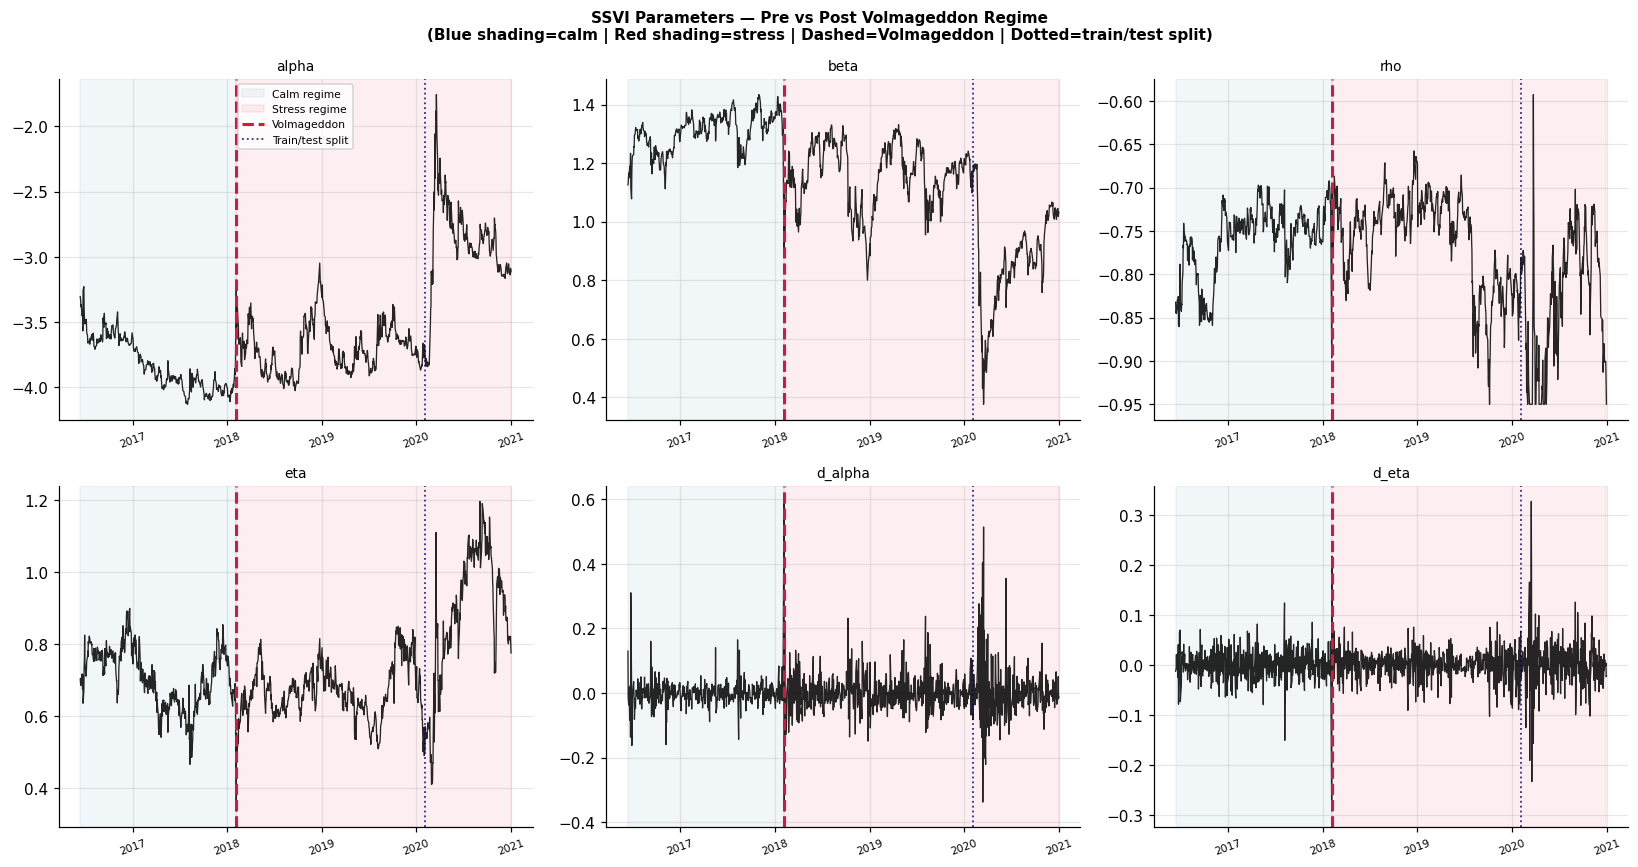

Param        Pre-mean   Pre-std  Post-mean  Post-std       t       p
--------------------------------------------------------------
  alpha         -3.8209    0.1969    -3.4439    0.4510 -16.173  0.0000 **
  beta           1.3045    0.0650     1.0641    0.1882  25.170  0.0000 **
  rho           -0.7610    0.0406    -0.7810    0.0686   5.428  0.0000 **
  eta            0.7059    0.0809     0.7368    0.1563  -3.753  0.0002 **
  d_alpha       -0.0008    0.0384     0.0009    0.0710  -0.453  0.6506 ns
  d_eta         -0.0002    0.0292     0.0002    0.0394  -0.186  0.8527 ns


In [10]:
# ── Regime identification and descriptive analysis ────────────────────────────
volmag_idx = int(df[df['date'] >= VOLMAG].index[0])
pre_mask   = df.index < volmag_idx
post_mask  = df.index >= volmag_idx
n_pre = int(pre_mask.sum()); n_post = int(post_mask.sum())

train_end_date  = df.iloc[n_train - 1]['date']
test_pre_count  = int((df_test['date'] <  VOLMAG).sum())
test_post_count = int((df_test['date'] >= VOLMAG).sum())

print(f"Data range: {df['date'].iloc[0].date()} to {df['date'].iloc[-1].date()}")
print(f"Volmageddon: {VOLMAG.date()}  (obs index {volmag_idx} / {len(df)})")
print(f"Pre-Volmageddon: {n_pre} obs  |  Post-Volmageddon: {n_post} obs")
print(f"Train/test split at obs {n_train} ({train_end_date.date()})")
print(f"Test set: {test_pre_count} obs pre-Volmageddon + {test_post_count} obs post-Volmageddon")
if test_post_count == len(df_test):
    print("  => Test set is ENTIRELY post-Volmageddon (stress regime)")
print()

# Plot: parameters with regime shading
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
PARAMS_R = ['alpha', 'beta', 'rho', 'eta', 'd_alpha', 'd_eta']
for ax, p in zip(axes.flat, PARAMS_R):
    ymin = float(df[p].min()); ymax = float(df[p].max()); ypad = (ymax-ymin)*0.05
    ax.fill_betweenx([ymin-ypad, ymax+ypad], df['date'].iloc[0], VOLMAG,
                     color='steelblue', alpha=0.07, label='Calm regime')
    ax.fill_betweenx([ymin-ypad, ymax+ypad], VOLMAG, df['date'].iloc[-1],
                     color='crimson', alpha=0.07, label='Stress regime')
    ax.plot(df['date'], df[p], 'k-', lw=0.85, alpha=0.85)
    ax.axvline(VOLMAG, color='crimson', lw=2.0, ls='--', label='Volmageddon')
    ax.axvline(train_end_date, color='navy', lw=1.2, ls=':', alpha=0.8, label='Train/test split')
    ax.set_title(p, fontsize=9); ax.tick_params(axis='x', rotation=20, labelsize=7)
    ax.set_ylim(ymin-ypad, ymax+ypad)

axes[0, 0].legend(fontsize=7, loc='best')
plt.suptitle('SSVI Parameters — Pre vs Post Volmageddon Regime\n'
             '(Blue shading=calm | Red shading=stress | Dashed=Volmageddon | Dotted=train/test split)',
             fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig(PLOTS + r'\fig12_regime_params.png', dpi=130, bbox_inches='tight')
plt.show()

# t-test: are means different?
print(f"{'Param':<10} {'Pre-mean':>10} {'Pre-std':>9} {'Post-mean':>10} {'Post-std':>9} {'t':>7} {'p':>7}")
print('-' * 62)
for p in ['alpha', 'beta', 'rho', 'eta', 'd_alpha', 'd_eta']:
    pr = df.loc[pre_mask,  p].dropna()
    po = df.loc[post_mask, p].dropna()
    t, pv = stats.ttest_ind(pr, po)
    sig = '**' if pv < 0.05 else ('.' if pv < 0.10 else 'ns')
    print(f"  {p:<10} {pr.mean():>10.4f} {pr.std():>9.4f} {po.mean():>10.4f} {po.std():>9.4f} {t:>7.3f} {pv:>7.4f} {sig}")


In [11]:
# ── Chow test for structural break at Volmageddon ────────────────────────────
from statsmodels.regression.linear_model import OLS as _OLS

def chow_test(y, X, brk):
    n = len(y); k = X.shape[1]
    if brk < k+2 or (n - brk) < k+2:
        return float('nan'), float('nan')
    rss_full = _OLS(y,          X         ).fit().ssr
    rss_pre  = _OLS(y[:brk],   X[:brk]   ).fit().ssr
    rss_post = _OLS(y[brk:],   X[brk:]   ).fit().ssr
    rss_ur   = rss_pre + rss_post
    F = ((rss_full - rss_ur) / k) / (rss_ur / (n - 2*k))
    p = float(1 - stats.f.cdf(max(F, 0), k, n - 2*k))
    return round(float(F), 4), round(p, 4)

print("Chow Test — Structural Break at Volmageddon (Feb 5, 2018)")
print("=" * 62)
chow_rows = []
for target in TARGETS:
    y_c = df[target].values
    X_c = add_constant(np.column_stack([
        df[target].shift(1).fillna(float(df[target].mean())).values,
        df['d_vix'].fillna(0).values if 'd_vix' in df.columns
        else np.zeros(len(df))
    ]))
    n_c = min(len(y_c), len(X_c)); y_c = y_c[:n_c]; X_c = X_c[:n_c]
    brk = min(volmag_idx, n_c - 5)
    F, p = chow_test(y_c, X_c, brk)
    if str(F) != 'nan':
        sig = '**' if p < 0.05 else ('.' if p < 0.10 else 'ns')
        chow_rows.append({'Target': target, 'F stat': F, 'p-value': p,
                          'Sig': sig, 'Structural break?': 'YES' if p < 0.05 else 'NO'})
        print(f"  {target:<12}: F={F:.4f}  p={p:.4f}  {sig}")

chow_df = pd.DataFrame(chow_rows)
print()
display(chow_df)
print()
print("** p<0.05: statistically significant structural break at Volmageddon.")
print("This confirms the two-regime structure and the need for regime-aware models.")


Chow Test — Structural Break at Volmageddon (Feb 5, 2018)
  d_alpha     : F=8.7914  p=0.0000  **
  d_eta       : F=16.8060  p=0.0000  **
  beta        : F=13.8986  p=0.0000  **
  rho         : F=0.6667  p=0.5726  ns
  gamma       : F=21.8955  p=0.0000  **



,Target,F stat,p-value,Sig,Structural break?
0,d_alpha,8.7914,0.0000,**,YES
1,d_eta,16.8060,0.0000,**,YES
2,beta,13.8986,0.0000,**,YES
3,rho,0.6667,0.5726,ns,NO
4,gamma,21.8955,0.0000,**,YES



** p<0.05: statistically significant structural break at Volmageddon.
This confirms the two-regime structure and the need for regime-aware models.


In [12]:
# ── Regime-aware ARMAX: train CALM, test STRESS ──────────────────────────────
print("Regime-aware OOS: train on pre-Volmageddon (calm), test on post-Volmageddon (stress)")
print("Standard OOS uses 80/20 split that STRADDLES the event")
print("=" * 72)

df_calm   = df[df['date'] < VOLMAG].reset_index(drop=True)
df_stress = df[df['date'] >= VOLMAG].reset_index(drop=True)
print(f"Calm-regime train: {len(df_calm)} obs | Stress-regime test: {len(df_stress)} obs\n")

regime_rows = []
for target in TARGETS:
    d_tr = df_calm[[target]   + selected_feat].copy()
    d_te = df_stress[[target] + selected_feat].copy()
    d_lag_tr = pd.concat([d_tr[[target]], d_tr[selected_feat].shift(1)],
                          axis=1).dropna().reset_index(drop=True)
    d_lag_te = pd.concat([d_te[[target]], d_te[selected_feat].shift(1)],
                          axis=1).dropna().reset_index(drop=True)
    if len(d_lag_tr) < 15 or len(d_lag_te) < 5:
        continue
    y_tr_r = d_lag_tr[target]; X_tr_r = d_lag_tr[selected_feat]
    y_te_r = d_lag_te[target]; X_te_r = d_lag_te[selected_feat]
    mu_r = X_tr_r.mean(); sd_r = X_tr_r.std().replace(0, 1)
    X_tr_sc = (X_tr_r - mu_r) / sd_r
    X_te_sc = (X_te_r - mu_r) / sd_r
    a_reg = y_te_r.values; n_te_r = len(a_reg)
    base_r = (np.zeros(n_te_r) if target in DIFF_T
              else np.concatenate([[float(y_tr_r.iloc[-1])], a_reg[:-1]]))
    mse_b_r = mse(a_reg, base_r)
    p_ord, q_ord = best_orders.get(target, (1, 0))
    ax_reg = []
    try:
        mdl_r  = ARIMA(y_tr_r, exog=X_tr_sc, order=(p_ord, 0, q_ord), trend='c').fit()
        curr_r = mdl_r
        for i in range(n_te_r):
            try:
                fc = curr_r.forecast(steps=1, exog=X_te_sc.iloc[[i]])
                ax_reg.append(float(fc.iloc[0]))
            except:
                ax_reg.append(float(y_tr_r.iloc[-1] if target in LEVEL_T else 0.0))
            try:
                curr_r = curr_r.append(endog=y_te_r.iloc[[i]],
                                        exog=X_te_sc.iloc[[i]], refit=False)
            except:
                pass
    except:
        ax_reg = [float(y_tr_r.iloc[-1] if target in LEVEL_T else 0.0)] * n_te_r
    armax_r   = np.array(ax_reg)
    ratio_r   = mse(a_reg, armax_r) / mse_b_r if mse_b_r > 1e-12 else float('nan')
    ratio_std = oos[target]['ratio_armax'] if target in oos else float('nan')
    regime_rows.append({
        'Target': target, 'n_calm_train': len(y_tr_r), 'n_stress_test': n_te_r,
        'Regime ratio': round(ratio_r, 4), 'Std 80/20 ratio': round(ratio_std, 4),
        'Ratio diff': round(ratio_r - ratio_std, 4) if str(ratio_r)!='nan' and str(ratio_std)!='nan' else float('nan'),
        'Regime harder?': 'YES' if (str(ratio_r)!='nan' and str(ratio_std)!='nan' and ratio_r > ratio_std) else 'no'
    })
    print(f"  {target:<12}: regime ratio={ratio_r:.4f}  std ratio={ratio_std:.4f}")

print()
display(pd.DataFrame(regime_rows))
print()
print("Regime ratio > Std ratio => model struggles more with pure stress-regime test.")
print("This is expected: Volmageddon is an out-of-distribution event for calm-trained models.")


Regime-aware OOS: train on pre-Volmageddon (calm), test on post-Volmageddon (stress)
Standard OOS uses 80/20 split that STRADDLES the event
Calm-regime train: 415 obs | Stress-regime test: 733 obs

  d_alpha     : regime ratio=1.1801  std ratio=1.1290


c:\Users\alpor\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  d_eta       : regime ratio=2.4126  std ratio=1.2909


c:\Users\alpor\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  beta        : regime ratio=14.4069  std ratio=1.2273


...

  rho         : regime ratio=3.1547  std ratio=1.1686


c:\Users\alpor\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  gamma       : regime ratio=3.4298  std ratio=1.2410



,Target,n_calm_train,n_stress_test,Regime ratio,Std 80/20 ratio,Ratio diff,Regime harder?
0,d_alpha,414,732,1.1801,1.1290,0.0511,YES
1,d_eta,414,732,2.4126,1.2909,1.1217,YES
2,beta,414,732,14.4069,1.2273,13.1796,YES
3,rho,414,732,3.1547,1.1686,1.9861,YES
4,gamma,414,732,3.4298,1.2410,2.1888,YES



Regime ratio > Std ratio => model struggles more with pure stress-regime test.
This is expected: Volmageddon is an out-of-distribution event for calm-trained models.


---
## 6. Shock Classification: Does SSVI Predict VIX Shocks?

**Question**: does today's SSVI surface shape help predict **tomorrow's** VIX direction?
- **Model A**: market features only (d_vix, vrp, ts_9d_1m, vix_zscore) — baseline
- **Model B**: market features + SSVI parameters (rho, d_alpha, d_eta) — extended
- **Data**: today's X_{t} → predict y_{t+1} direction (no leakage)

**Three targets**:
1. Binary VIX direction (up/down)
2. Signed 3-class (-1=large down, 0=neutral, +1=large up)

In [13]:

MIN_TRAIN = 50

cls_data = df[['date', 'rho', 'beta', 'gamma', 'd_alpha', 'd_eta'] + FEATS].copy().dropna()

# Target 1: VIX direction tomorrow (binary)
cls_data['vix_dir']    = (cls_data['d_vix'].shift(-1) > 0).astype(int)

# Target 2: VIX shock 3-class (using vix_zscore of NEXT day's d_vix)
next_dvix = cls_data['d_vix'].shift(-1)
q33, q67  = next_dvix.quantile(0.33), next_dvix.quantile(0.67)
cls_data['vix_3class'] = 0
cls_data.loc[next_dvix < q33, 'vix_3class'] = -1
cls_data.loc[next_dvix > q67, 'vix_3class'] =  1

cls_data = cls_data.dropna(subset=['vix_dir','vix_3class']).reset_index(drop=True)
sp_cls   = int(len(cls_data) * SPLIT)

MKTF = [f for f in ['d_vix','vrp','ts_9d_1m','vix_zscore','ts_1m_3m'] if f in cls_data.columns]
SSVIF= ['rho', 'd_alpha', 'd_eta']
feats_A = MKTF
feats_B = MKTF + SSVIF

for feat_list in [feats_A, feats_B]:
    scaler = StandardScaler()
    scaler.fit(cls_data[feat_list].iloc[:sp_cls])
    cls_data['_Xtr_' + '+'.join(feat_list[:2])] = 0  # dummy

scaler_A = StandardScaler().fit(cls_data[feats_A].iloc[:sp_cls])
scaler_B = StandardScaler().fit(cls_data[feats_B].iloc[:sp_cls])

X_tr_A = scaler_A.transform(cls_data[feats_A].iloc[:sp_cls])
X_te_A = scaler_A.transform(cls_data[feats_A].iloc[sp_cls:])
X_tr_B = scaler_B.transform(cls_data[feats_B].iloc[:sp_cls])
X_te_B = scaler_B.transform(cls_data[feats_B].iloc[sp_cls:])
y_tr_bin = cls_data['vix_dir'].iloc[:sp_cls]
y_te_bin = cls_data['vix_dir'].iloc[sp_cls:]
y_tr_3cl = cls_data['vix_3class'].iloc[:sp_cls]
y_te_3cl = cls_data['vix_3class'].iloc[sp_cls:]

maj_bin = max(y_te_bin.mean(), 1-y_te_bin.mean())
print(f"Binary classification — Majority baseline: {maj_bin:.3f}")
print(f"Train: {len(y_tr_bin)}  Test: {len(y_te_bin)}")


Binary classification — Majority baseline: 0.565
Train: 918  Test: 230


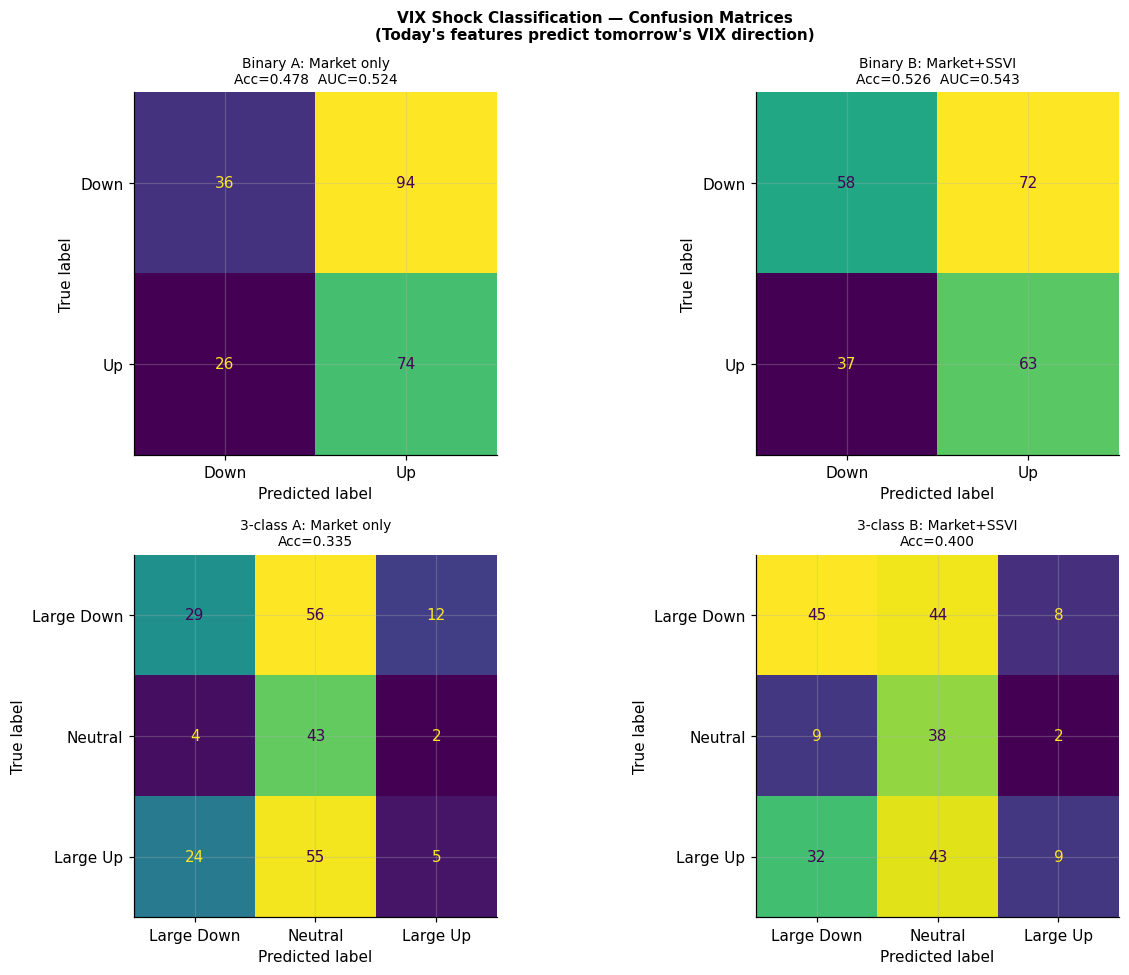


Binary Classification Summary:
  Binary A: Market only: Acc=0.478 (+-0.087 vs majority)  AUC=0.524
  Binary B: Market+SSVI: Acc=0.526 (+-0.039 vs majority)  AUC=0.543


In [14]:

# ── Binary classification results ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
results_cls = {}

for ri, (name, Xtr, Xte, y_tr, y_te) in enumerate([
    ('Binary A: Market only',  X_tr_A, X_te_A, y_tr_bin, y_te_bin),
    ('Binary B: Market+SSVI',  X_tr_B, X_te_B, y_tr_bin, y_te_bin),
]):
    clf = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
    clf.fit(Xtr, y_tr)
    pred = clf.predict(Xte)
    prob = clf.predict_proba(Xte)[:, 1]
    acc  = accuracy_score(y_te, pred)
    auc  = roc_auc_score(y_te, prob)
    results_cls[name] = {'acc': acc, 'auc': auc}

    cm = confusion_matrix(y_te, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Down', 'Up']).plot(
        ax=axes[0, ri], colorbar=False)
    axes[0, ri].set_title(
        f'{name}\nAcc={acc:.3f}  AUC={auc:.3f}', fontsize=9)

# 3-class (Model B only)
for ri, (name, Xtr, Xte, y_tr, y_te) in enumerate([
    ('3-class A: Market only',  X_tr_A, X_te_A, y_tr_3cl, y_te_3cl),
    ('3-class B: Market+SSVI',  X_tr_B, X_te_B, y_tr_3cl, y_te_3cl),
]):
    clf3 = LogisticRegression(max_iter=500, class_weight='balanced', multi_class='ovr', random_state=42)
    clf3.fit(Xtr, y_tr)
    pred3 = clf3.predict(Xte)
    acc3  = accuracy_score(y_te, pred3)
    cm3   = confusion_matrix(y_te, pred3, labels=[-1, 0, 1])
    ConfusionMatrixDisplay(cm3, display_labels=['Large Down', 'Neutral', 'Large Up']).plot(
        ax=axes[1, ri], colorbar=False)
    axes[1, ri].set_title(f'{name}\nAcc={acc3:.3f}', fontsize=9)

plt.suptitle('VIX Shock Classification — Confusion Matrices\n'
             '(Today\'s features predict tomorrow\'s VIX direction)',
             fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig(PLOTS + r'\fig06_shock_cls.png', dpi=130, bbox_inches='tight')
plt.show()

print("\nBinary Classification Summary:")
for name, res in results_cls.items():
    improvement = res['acc'] - maj_bin
    print(f"  {name}: Acc={res['acc']:.3f} (+{improvement:.3f} vs majority)  AUC={res['auc']:.3f}")


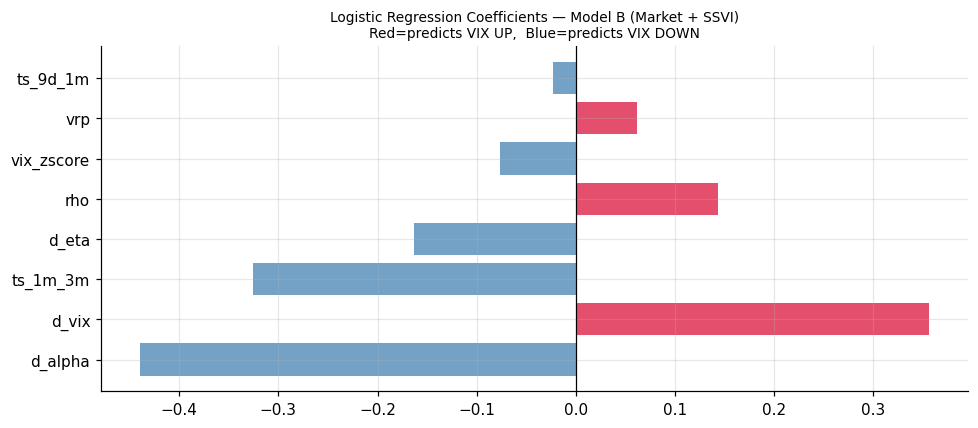

Economic interpretation:
  rho (skew): more negative rho -> higher demand for put protection -> likely VIX up?
  d_alpha        : coef=-0.4391  -> predicts VIX DOWN
  d_vix          : coef=+0.3556  -> predicts VIX UP
  ts_1m_3m       : coef=-0.3254  -> predicts VIX DOWN
  d_eta          : coef=-0.1634  -> predicts VIX DOWN
  rho            : coef=+0.1428  -> predicts VIX UP
  vix_zscore     : coef=-0.0766  -> predicts VIX DOWN
  vrp            : coef=+0.0611  -> predicts VIX UP
  ts_9d_1m       : coef=-0.0228  -> predicts VIX DOWN


In [15]:

# ── Coefficient interpretation ────────────────────────────────────────────────
clf_B = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
clf_B.fit(X_tr_B, y_tr_bin)

coef_df = pd.DataFrame({
    'Feature':     feats_B,
    'Coefficient': clf_B.coef_[0],
    'Abs':         np.abs(clf_B.coef_[0]),
}).sort_values('Abs', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
colors  = ['crimson' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.75)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Logistic Regression Coefficients — Model B (Market + SSVI)\n'
             'Red=predicts VIX UP,  Blue=predicts VIX DOWN', fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS + r'\fig07_cls_coef.png', dpi=130, bbox_inches='tight')
plt.show()

print("Economic interpretation:")
print("  rho (skew): more negative rho -> higher demand for put protection -> likely VIX up?")
for feat, coef in zip(coef_df['Feature'], coef_df['Coefficient']):
    direction = "predicts VIX UP" if coef > 0 else "predicts VIX DOWN"
    print(f"  {feat:<15}: coef={coef:+.4f}  -> {direction}")


---
## 7. VAR System: [rho, d_alpha, d_vix]

We estimate a VAR on the stationary system to assess joint dynamics.

**Cholesky ordering**: [rho, d_alpha, d_vix] — SSVI parameters come first,
assuming they can have contemporaneous impact on VIX (rho reflects skew demand).

In [16]:

var_data = df[['rho', 'd_alpha', 'd_vix']].dropna().copy()

# Lag selection
var_m   = VAR(var_data)
lag_sel = var_m.select_order(maxlags=5)
print("VAR Lag Selection:")
print(lag_sel.summary())
p_opt = max(1, min(lag_sel.aic, 3))


VAR Lag Selection:
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -11.44      -11.42   1.078e-05      -11.43
1      -14.26      -14.21   6.424e-07      -14.24
2      -14.29      -14.20   6.227e-07      -14.25
3      -14.34      -14.21   5.908e-07      -14.29
4      -14.40     -14.22*   5.594e-07     -14.33*
5     -14.40*      -14.19  5.559e-07*      -14.32
-------------------------------------------------


In [17]:

res_var = var_m.fit(p_opt)
print(f"VAR({p_opt}) fitted. Stable: {res_var.is_stable()}")
print(res_var.summary())


VAR(3) fitted. Stable: True
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 22, May, 2026
Time:                     15:08:33
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -14.2122
Nobs:                     1145.00    HQIC:                  -14.2944
Log likelihood:           3368.05    FPE:                5.89324e-07
AIC:                     -14.3443    Det(Omega_mle):     5.74149e-07
--------------------------------------------------------------------
Results for equation rho
                coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------
const             -0.032723         0.007986           -4.097           0.000
L1.rho             0.860925         0.039732           21.668           0.000
L1.d_alpha        -0.006653         0.027857  

In [18]:

# ── Granger causality ─────────────────────────────────────────────────────────
print("Granger Causality Tests in VAR System")
print("=" * 65)
gc_tests = [
    ('d_vix',  'rho',     'Does rho Granger-cause VIX change?'),
    ('d_vix',  'd_alpha', 'Does d_alpha Granger-cause VIX change?'),
    ('rho',    'd_vix',   'Does VIX change Granger-cause rho?'),
    ('d_alpha','d_vix',   'Does VIX change Granger-cause d_alpha?'),
]
for caused, causing, desc in gc_tests:
    if caused in var_data.columns and causing in var_data.columns:
        try:
            gc  = res_var.test_causality(caused, causing, kind='f')
            sig = '**' if gc.pvalue < 0.05 else ('.' if gc.pvalue < 0.10 else 'n.s.')
            print(f"  {desc}")
            print(f"    F={gc.test_statistic:.3f}  p={gc.pvalue:.4f}  {sig}")
        except Exception as e:
            print(f"  {desc}: {e}")


Granger Causality Tests in VAR System
  Does rho Granger-cause VIX change?
    F=1.543  p=0.2013  n.s.
  Does d_alpha Granger-cause VIX change?
    F=6.479  p=0.0002  **
  Does VIX change Granger-cause rho?
    F=5.400  p=0.0010  **
  Does VIX change Granger-cause d_alpha?
    F=14.895  p=0.0000  **


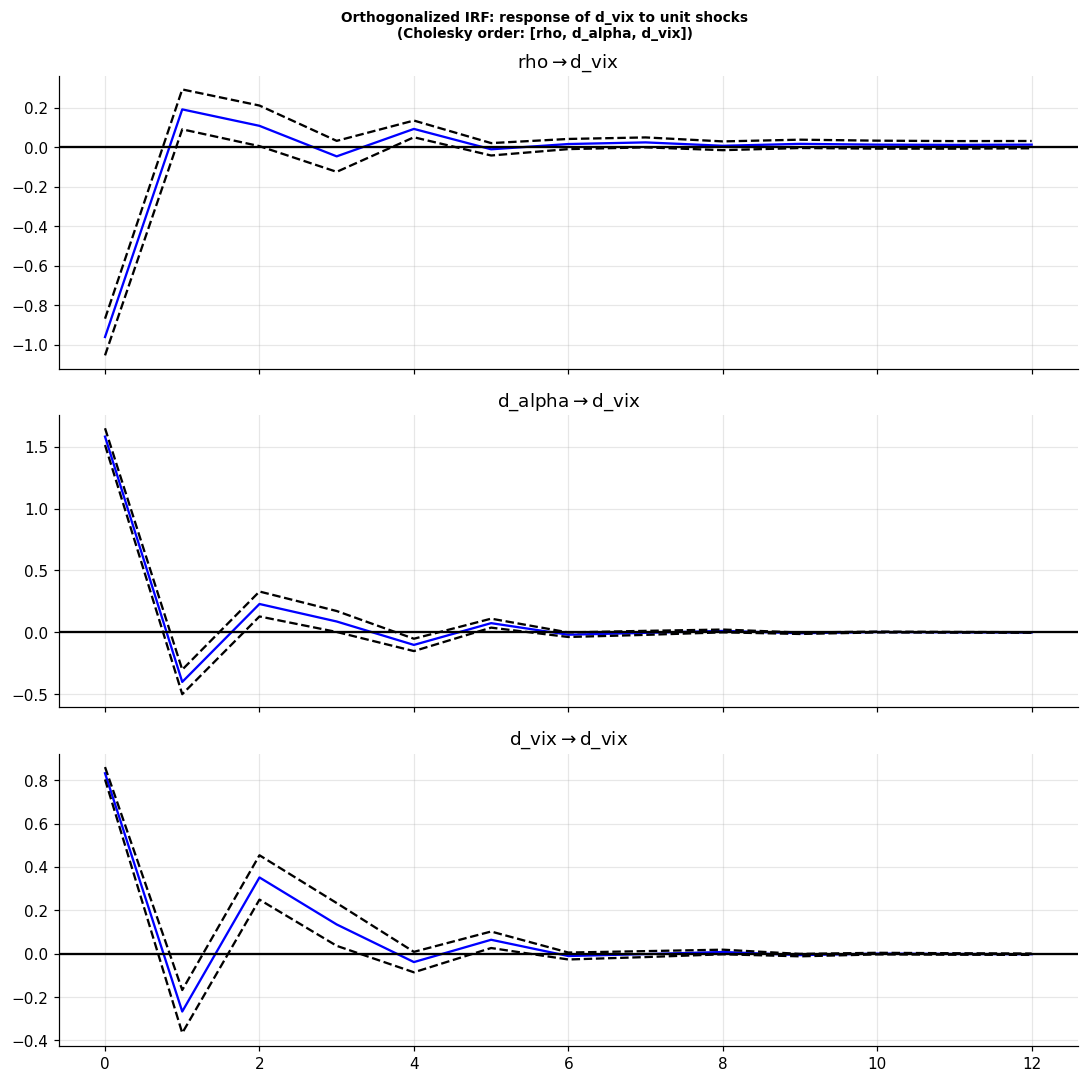

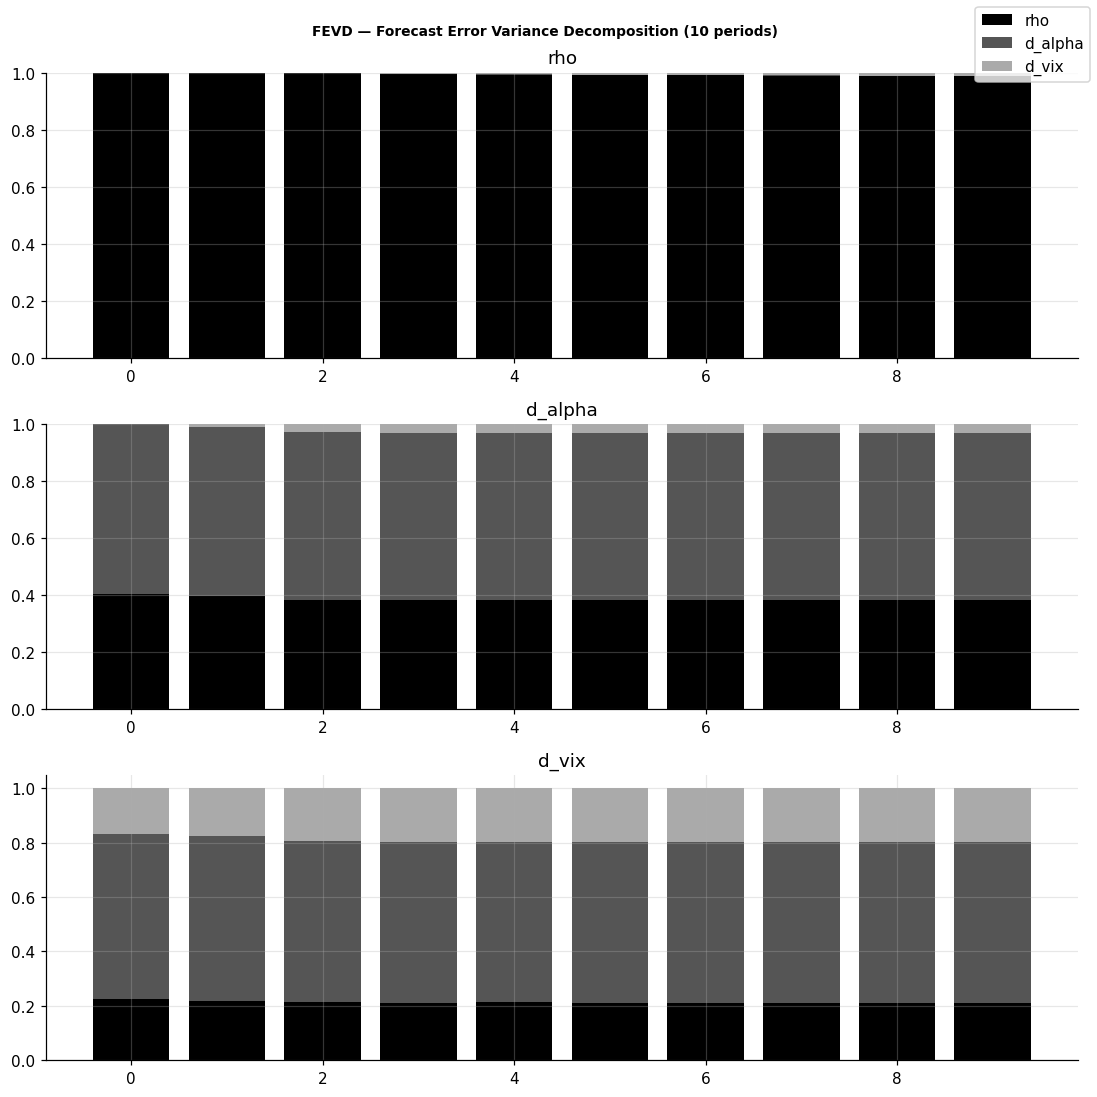

In [19]:

# ── IRF ───────────────────────────────────────────────────────────────────────
irf = res_var.irf(periods=12)
irf.plot(orth=True, signif=0.1, response='d_vix', plot_stderr=True)
plt.gcf().suptitle(
    'Orthogonalized IRF: response of d_vix to unit shocks\n'
    '(Cholesky order: [rho, d_alpha, d_vix])',
    fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS + r'\fig08_irf.png', dpi=130, bbox_inches='tight')
plt.show()

# ── FEVD ──────────────────────────────────────────────────────────────────────
fevd = res_var.fevd(periods=10)
fevd.plot()
plt.gcf().suptitle('FEVD — Forecast Error Variance Decomposition (10 periods)',
                   fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS + r'\fig09_fevd.png', dpi=130, bbox_inches='tight')
plt.show()


---
## 8. VECM: Vector Error Correction Model

Since alpha and beta are both I(1) (confirmed in notebook 01), we test whether
they share a **long-run cointegrating relationship**. If cointegrated, a VECM
captures both short-run dynamics and the error-correction pull toward equilibrium.

Economic rationale: alpha (negative ATM variance) and beta (variance scale) are
both driven by the volatility level. A permanent shock to VIX should raise both,
keeping them in a long-run relationship.

Model: VECM(k_ar_diff=2): Delta_y_t = alpha_EC * beta' * y_{t-1} + sum Gamma_i Delta_y_{t-i} + eps

In [20]:
# ── Cointegration tests: alpha and beta ──────────────────────────────────────
from statsmodels.tsa.vector_ar.vecm import VECM as VECM_model, select_coint_rank
from statsmodels.tsa.stattools import coint as eg_coint

vec_full = df[['alpha', 'beta']].dropna().reset_index(drop=True)
n_tr_v   = n_train  # same split point
vec_tr   = vec_full.iloc[:n_tr_v]
vec_te   = vec_full.iloc[n_tr_v:]

print(f"VECM data: {len(vec_full)} obs  |  train={len(vec_tr)}  test={len(vec_te)}")
print()

# Engle-Granger test on TRAINING data only
eg_stat, eg_p, eg_crit = eg_coint(vec_tr['alpha'], vec_tr['beta'])
print("Engle-Granger cointegration test (on training data):")
print(f"  stat={eg_stat:.4f}  p-value={eg_p:.4f}")
print(f"  Critical values: 1%={eg_crit[0]:.4f}, 5%={eg_crit[1]:.4f}, 10%={eg_crit[2]:.4f}")
print(f"  Result: {'Cointegrated' if eg_p < 0.05 else 'Marginally cointegrated' if eg_p < 0.10 else 'NOT cointegrated'} at 5%")
print()

# Johansen trace test on training data
try:
    rank_res = select_coint_rank(vec_tr, det_order=0, k_ar_diff=2, method='trace')
    print("Johansen trace test (on training data):")
    print(rank_res.summary())
    coint_rank = max(0, min(int(rank_res.rank), 1))
except Exception as ex:
    print(f"Johansen test error: {ex}")
    coint_rank = 1 if eg_p < 0.10 else 0

print(f"=> Selected cointegration rank: {coint_rank}")
print("   (rank=1: one long-run cointegrating relationship between alpha and beta)")


VECM data: 1148 obs  |  train=918  test=230

Engle-Granger cointegration test (on training data):
  stat=-2.4803  p-value=0.2878
  Critical values: 1%=-3.9084, 5%=-3.3428, 10%=-3.0491
  Result: NOT cointegrated at 5%

Johansen trace test (on training data):
Johansen cointegration test using trace test statistic with 5% significance level
r_0 r_1 test statistic critical value
-------------------------------------
  0   2          19.45          15.49
  1   2          6.748          3.841
-------------------------------------
=> Selected cointegration rank: 1
   (rank=1: one long-run cointegrating relationship between alpha and beta)


In [21]:
# ── VECM fit + rolling OOS forecast ─────────────────────────────────────────
vecm_fit_tr = None
vecm_p_alpha = []
vecm_p_beta  = []

if coint_rank > 0 and len(vec_te) > 0:
    # Fit on training data
    try:
        vecm_fit_tr = VECM_model(vec_tr, coint_rank=coint_rank,
                                 k_ar_diff=2, deterministic='ci').fit()
        print(vecm_fit_tr.summary())
        adj_spd = vecm_fit_tr.alpha.ravel()
        coint_v = vecm_fit_tr.beta.ravel()
        print(f"\nAdjustment speeds (alpha_EC): {adj_spd}")
        print(f"Cointegrating vector (beta):  {coint_v}")
        half_life = -np.log(2) / np.log(abs(1 + adj_spd[0])) if adj_spd[0] != 0 else float('nan')
        print(f"Approx. half-life of EC deviation (alpha): {half_life:.1f} trading days")
    except Exception as ex:
        print(f"VECM fit failed: {ex}"); vecm_fit_tr = None

    # Rolling OOS: refit at each step with expanding window
    print(f"\nRolling OOS forecast ({len(vec_te)} steps)...")
    vec_hist = vec_tr.copy().reset_index(drop=True)
    for i in range(len(vec_te)):
        try:
            vm = VECM_model(vec_hist, coint_rank=coint_rank,
                            k_ar_diff=2, deterministic='ci').fit()
            fc = vm.predict(steps=1)
            vecm_p_alpha.append(float(fc[0, 0]))
            vecm_p_beta.append(float(fc[0, 1]))
        except:
            vecm_p_alpha.append(float(vec_hist['alpha'].iloc[-1]))
            vecm_p_beta.append(float(vec_hist['beta'].iloc[-1]))
        vec_hist = pd.concat([vec_hist, vec_te.iloc[[i]].reset_index(drop=True)],
                              ignore_index=True)
    print("Done.")

    # Evaluate VECM level forecasts vs sticky (y_{t-1})
    a_al = vec_te['alpha'].values; a_bt = vec_te['beta'].values
    p_al = np.array(vecm_p_alpha); p_bt = np.array(vecm_p_beta)
    st_al = np.concatenate([[float(vec_tr['alpha'].iloc[-1])], a_al[:-1]])
    st_bt = np.concatenate([[float(vec_tr['beta'].iloc[-1])],  a_bt[:-1]])
    r_va = mse(a_al, p_al) / mse(a_al, st_al)
    r_vb = mse(a_bt, p_bt) / mse(a_bt, st_bt)

    # Compare to AR-GARCH (which also forecasts levels for rho, eta, gamma)
    print(f"\nVECM OOS (level forecasts):")
    print(f"  alpha: VECM ratio vs sticky = {r_va:.4f}")
    print(f"  beta:  VECM ratio vs sticky = {r_vb:.4f}")
    print(f"  (ratio < 1.0 = beats sticky level forecast)")
    print()
    print(f"  For reference — ARMAX on d_alpha: ratio = {oos.get('d_alpha',{}).get('ratio_armax','n/a')}")
    print(f"  Note: VECM forecasts LEVELS; ARMAX forecasts FIRST DIFFERENCES.")
    print(f"  Direct comparison not applicable — VECM ratio uses sticky(level) baseline.")
else:
    print(f"VECM skipped: coint_rank={coint_rank}")


Det. terms outside the coint. relation & lagged endog. parameters for equation alpha
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.alpha       0.0371      0.110      0.339      0.735      -0.178       0.252
L1.beta        0.2616      0.186      1.403      0.161      -0.104       0.627
L2.alpha      -0.1888      0.110     -1.722      0.085      -0.404       0.026
L2.beta       -0.1619      0.187     -0.867      0.386      -0.528       0.204
Det. terms outside the coint. relation & lagged endog. parameters for equation beta
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.alpha      -0.0194      0.065     -0.300      0.764      -0.146       0.107
L1.beta       -0.1442      0.110     -1.313      0.189      -0.359       0.071
L2.alpha       0.1063      0.065      1.6

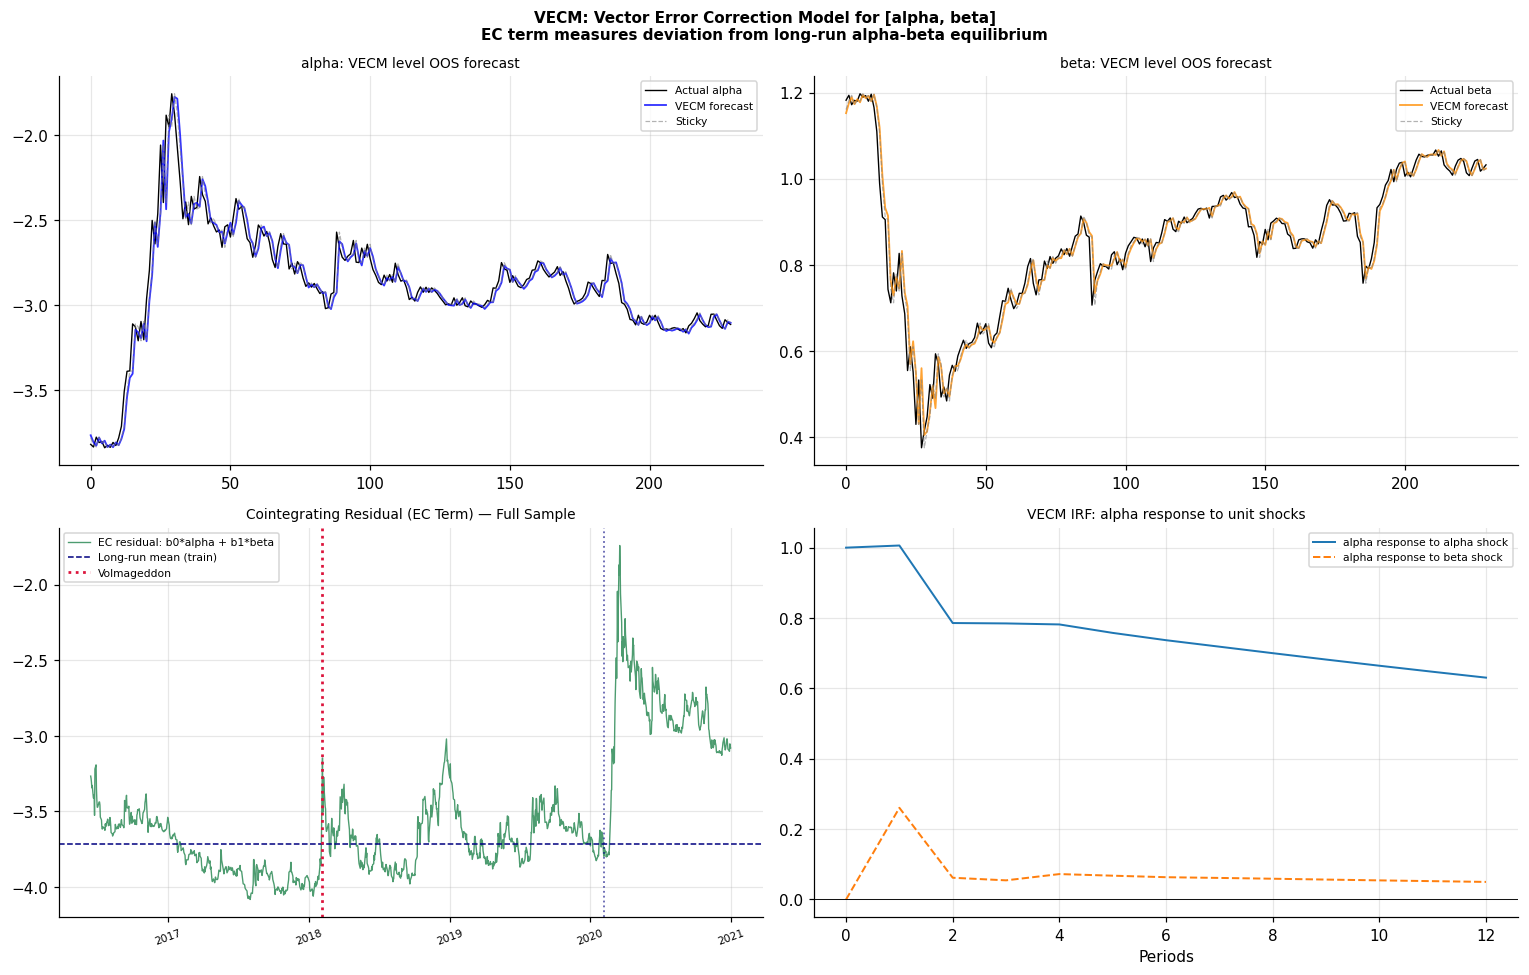

In [22]:
# ── VECM plots ────────────────────────────────────────────────────────────────
if vecm_fit_tr is not None and len(vecm_p_alpha) > 0:
    a_al = vec_te['alpha'].values; a_bt = vec_te['beta'].values
    p_al = np.array(vecm_p_alpha); p_bt = np.array(vecm_p_beta)
    st_al = np.concatenate([[float(vec_tr['alpha'].iloc[-1])], a_al[:-1]])
    st_bt = np.concatenate([[float(vec_tr['beta'].iloc[-1])],  a_bt[:-1]])
    xs = np.arange(len(a_al))

    # Cointegrating (error-correction) residual over FULL sample
    bv = vecm_fit_tr.beta.ravel()
    ec_full = bv[0] * vec_full['alpha'].values + bv[1] * vec_full['beta'].values
    train_ec_mean = float(np.mean(ec_full[:n_tr_v]))

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    axes[0, 0].plot(xs, a_al, 'k-', lw=0.9, label='Actual alpha')
    axes[0, 0].plot(xs, p_al, 'b-', lw=1.2, alpha=0.8, label='VECM forecast')
    axes[0, 0].plot(xs, st_al,'--', color='gray', lw=0.8, alpha=0.6, label='Sticky')
    axes[0, 0].set_title('alpha: VECM level OOS forecast', fontsize=9)
    axes[0, 0].legend(fontsize=7)

    axes[0, 1].plot(xs, a_bt, 'k-', lw=0.9, label='Actual beta')
    axes[0, 1].plot(xs, p_bt, 'darkorange', lw=1.2, alpha=0.8, label='VECM forecast')
    axes[0, 1].plot(xs, st_bt,'--', color='gray', lw=0.8, alpha=0.6, label='Sticky')
    axes[0, 1].set_title('beta: VECM level OOS forecast', fontsize=9)
    axes[0, 1].legend(fontsize=7)

    dates_v = df['date'].values[:len(ec_full)]
    axes[1, 0].plot(dates_v, ec_full, 'seagreen', lw=0.9, alpha=0.85,
                    label='EC residual: b0*alpha + b1*beta')
    axes[1, 0].axhline(train_ec_mean, color='navy', lw=1.0, ls='--', label='Long-run mean (train)')
    axes[1, 0].axvline(VOLMAG, color='crimson', lw=1.8, ls=':', label='Volmageddon')
    axes[1, 0].axvline(df.iloc[n_tr_v]['date'], color='navy', lw=1.2, ls=':', alpha=0.6)
    axes[1, 0].set_title('Cointegrating Residual (EC Term) — Full Sample', fontsize=9)
    axes[1, 0].legend(fontsize=7); axes[1, 0].tick_params(axis='x', rotation=20, labelsize=7)

    try:
        irf_v  = vecm_fit_tr.irf(periods=12)
        irfs   = irf_v.irfs
        for j, nm in enumerate(['alpha shock', 'beta shock']):
            axes[1, 1].plot(np.arange(irfs.shape[0]), irfs[:, 0, j],
                            lw=1.3, ls='-' if j == 0 else '--', label=f'alpha response to {nm}')
        axes[1, 1].axhline(0, color='black', lw=0.6)
        axes[1, 1].set_title('VECM IRF: alpha response to unit shocks', fontsize=9)
        axes[1, 1].legend(fontsize=7); axes[1, 1].set_xlabel('Periods')
    except Exception as ex:
        axes[1, 1].text(0.5, 0.5, f'IRF: {ex}', transform=axes[1, 1].transAxes,
                        ha='center', fontsize=8)

    plt.suptitle('VECM: Vector Error Correction Model for [alpha, beta]\n'
                 'EC term measures deviation from long-run alpha-beta equilibrium',
                 fontweight='bold', fontsize=10)
    plt.tight_layout()
    plt.savefig(PLOTS + r'\fig13_vecm.png', dpi=130, bbox_inches='tight')
    plt.show()
else:
    print("VECM plots skipped (no cointegration or fit failed).")


---
## 9. Probabilistic Forecasting

> *EXTRA — Approfondimento specifico SSVI.*

Two approaches for 80% prediction intervals:
1. **ARMAX + GARCH(1,1)**: point forecast ± z * GARCH conditional volatility
2. **Quantile Regression (QuantReg)**: directly estimates 10th and 90th percentiles

**Evaluation metrics**:
- **Coverage**: fraction of actuals falling inside the 80% PI
- **Pinball Loss**: asymmetric loss for quantile evaluation (lower = better)
- **Winkler Score**: width + penalty for misses (lower = better, accounts for sharpness)

In [23]:

Z_80   = 1.2816  # z for 80% PI (90th percentile of standard normal)
ALPHA  = 0.20    # 1 - coverage level

pi_rows_garch = []
pi_rows_qr    = []

for target in ['d_alpha', 'd_eta', 'rho']:
    if target not in preds: continue

    # ── Rebuild training data (same as Triple Battle) ─────────────────────────
    d_full   = df[[target] + selected_feat].copy()
    X_lag    = d_full[selected_feat].shift(1)
    d_lag    = pd.concat([d_full[[target]], X_lag], axis=1).dropna().reset_index(drop=True)
    sp       = int(len(d_lag) * SPLIT)
    y        = d_lag[target]; X = d_lag[selected_feat]
    y_tr, y_te = y.iloc[:sp], y.iloc[sp:]
    X_tr, X_te = X.iloc[:sp], X.iloc[sp:]
    mu_x = X_tr.mean(); sd_x = X_tr.std().replace(0, 1)
    X_tr_sc = (X_tr - mu_x) / sd_x
    X_te_sc = (X_te - mu_x) / sd_x
    p_ord, q_ord = best_orders.get(target, (1, 0))
    a_arr    = y_te.values; n_te = len(a_arr)
    armax_pt = preds[target]['armax']  # already computed

    # ── GARCH conditional volatility ──────────────────────────────────────────
    try:
        mdl_full = ARIMA(y_tr, exog=X_tr_sc, order=(p_ord,0,q_ord), trend='c').fit()
        resid    = mdl_full.resid.dropna()
        am       = arch_fn(resid, vol='GARCH', p=1, q=1, dist='normal')
        gm       = am.fit(disp='off', show_warning=False)
        last_sig = float(gm.conditional_volatility.iloc[-1])
        sigma    = np.full(n_te, last_sig)
    except:
        sigma = np.full(n_te, np.std(a_arr))

    lo_g = armax_pt - Z_80 * sigma
    hi_g = armax_pt + Z_80 * sigma

    # ── Quantile Regression ───────────────────────────────────────────────────
    X_tr_c = add_constant(X_tr_sc.values)
    X_te_c = add_constant(X_te_sc.values)
    try:
        qm_lo = QuantReg(y_tr.values, X_tr_c).fit(q=0.10, max_iter=1000)
        qm_hi = QuantReg(y_tr.values, X_tr_c).fit(q=0.90, max_iter=1000)
        lo_q  = qm_lo.predict(X_te_c)
        hi_q  = qm_hi.predict(X_te_c)
    except:
        lo_q  = lo_g; hi_q = hi_g

    def pi_metrics(a, lo, hi, label):
        cov = float(np.mean((a >= lo) & (a <= hi)))
        w   = float(np.mean(hi - lo))
        # Pinball loss for q=0.10 and q=0.90
        pb_lo = float(np.mean(np.where(a < lo, (1-0.10)*(lo-a), 0.10*(a-lo))))
        pb_hi = float(np.mean(np.where(a < hi, (1-0.90)*(hi-a), 0.90*(a-hi))))
        pinball = (pb_lo + pb_hi) / 2
        # Winkler score
        ws = []
        for ai, li, hi_i in zip(a, lo, hi):
            wv = hi_i - li
            if ai < li:    wv += 2*(li   - ai)  / ALPHA
            elif ai > hi_i: wv += 2*(ai   - hi_i) / ALPHA
            ws.append(wv)
        winkler = float(np.mean(ws))
        return {'Target': target, 'Model': label,
                'Coverage': round(cov, 3), 'Avg Width': round(w, 6),
                'Pinball Loss': round(pinball, 6), 'Winkler Score': round(winkler, 6)}

    pi_rows_garch.append(pi_metrics(a_arr, lo_g, hi_g, 'ARMAX+GARCH'))
    pi_rows_qr.append(   pi_metrics(a_arr, lo_q, hi_q, 'QuantReg'))

print("Probabilistic Forecasting Metrics (80% PI):")
pi_df = pd.DataFrame(pi_rows_garch + pi_rows_qr).sort_values(['Target','Model'])
display(pi_df)
print()
print("Note: Winkler Score penalizes both wide intervals and misses.")
print("Pinball Loss evaluates quantile calibration directly.")


Probabilistic Forecasting Metrics (80% PI):


c:\Users\alpor\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Target,Model,Coverage,Avg Width,Pinball Loss,Winkler Score
0,d_alpha,ARMAX+GARCH,0.7610,0.1451,0.0176,0.3529
3,d_alpha,QuantReg,0.4130,0.1109,0.0186,0.3625
1,d_eta,ARMAX+GARCH,0.7520,0.0932,0.0108,0.2159
4,d_eta,QuantReg,0.6300,0.0679,0.0127,0.2497
2,rho,ARMAX+GARCH,0.6910,0.0485,0.0063,0.1269
5,rho,QuantReg,0.4830,0.1146,0.0264,0.5287



Note: Winkler Score penalizes both wide intervals and misses.
Pinball Loss evaluates quantile calibration directly.


c:\Users\alpor\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


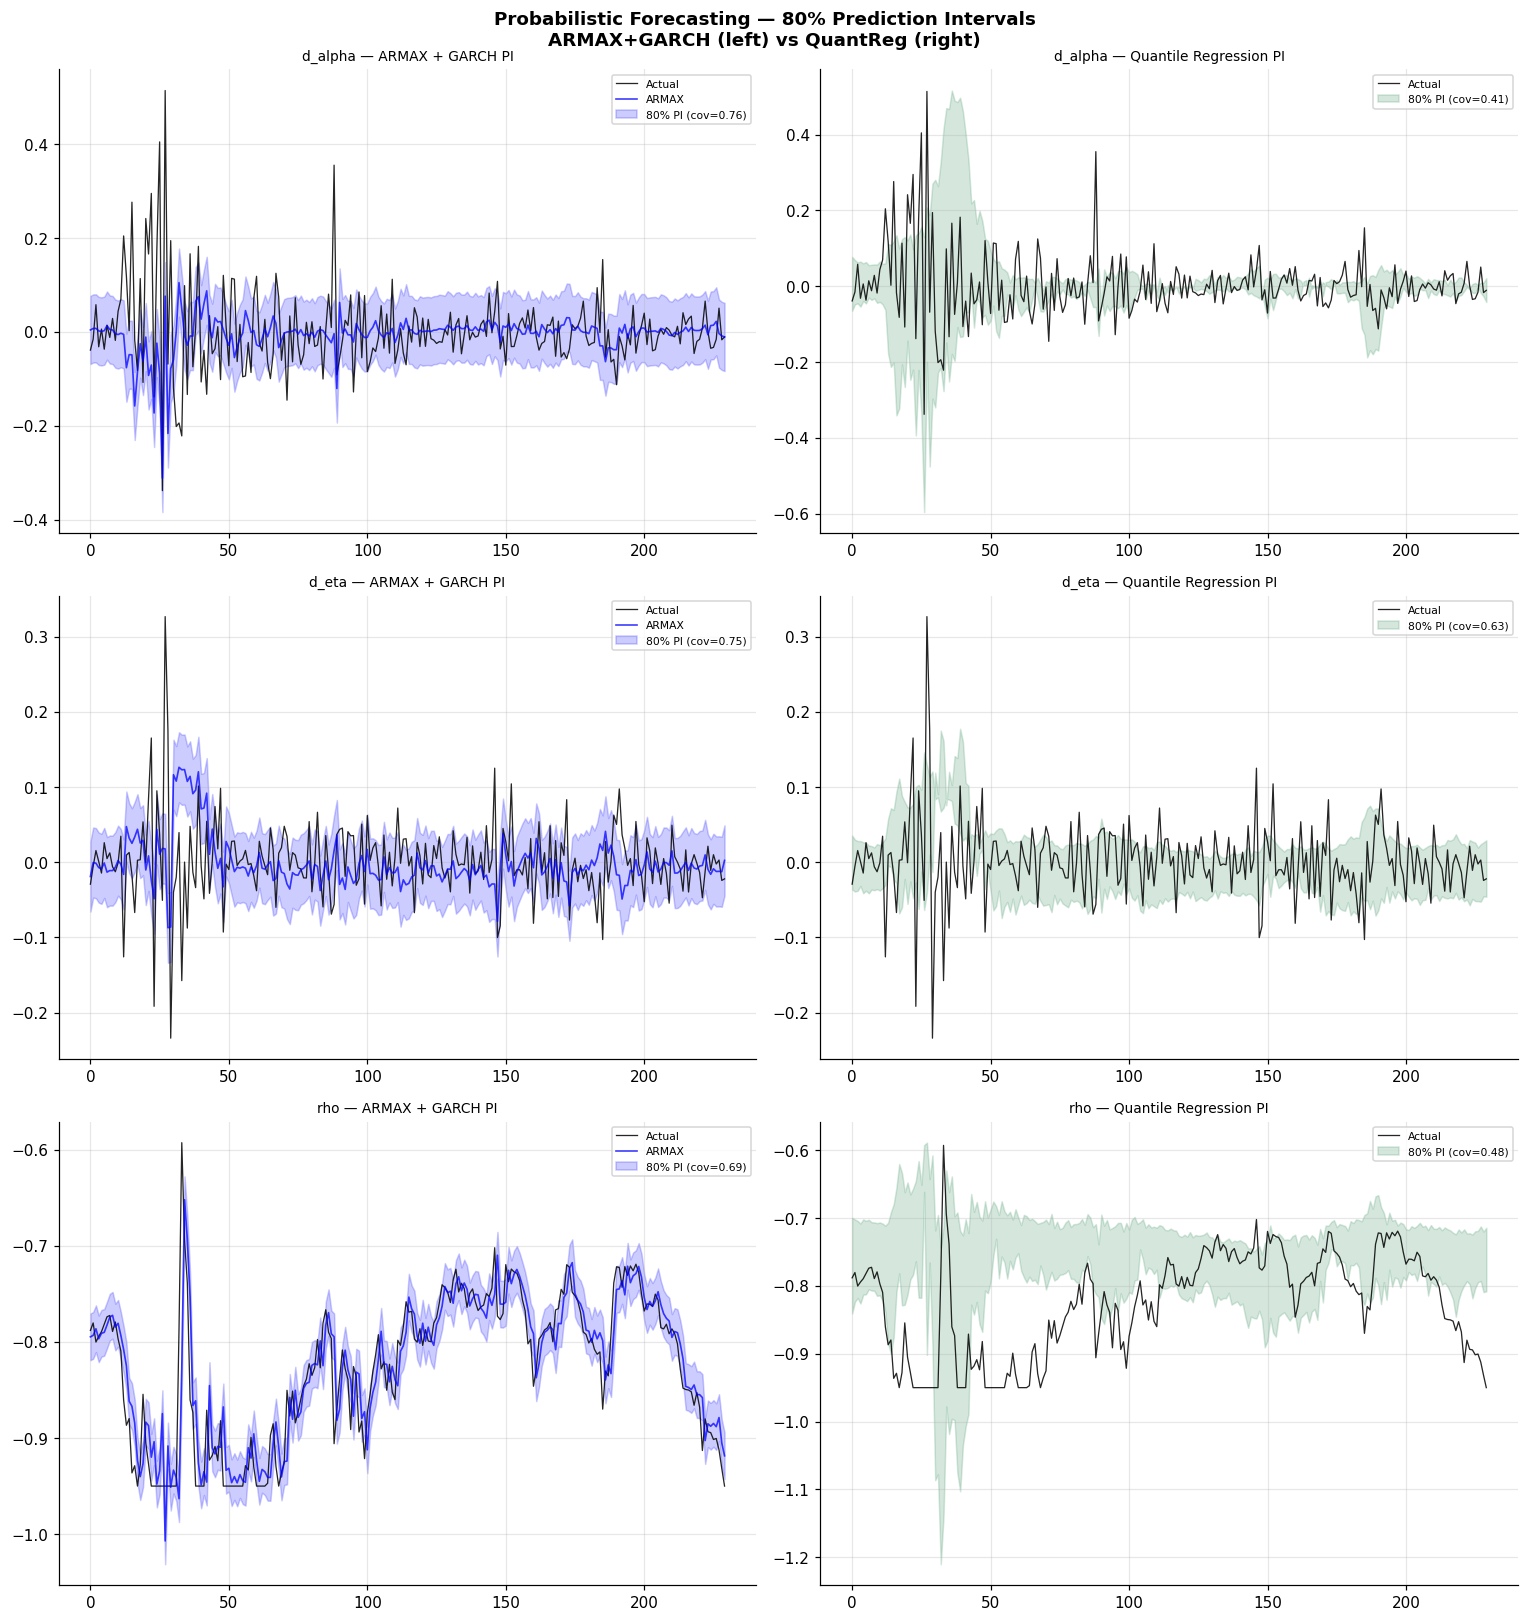

In [24]:

# ── Prediction interval plots ─────────────────────────────────────────────────
focus_pi = ['d_alpha', 'd_eta', 'rho']
fig, axes = plt.subplots(len(focus_pi), 2, figsize=(14, 5*len(focus_pi)))

for ri, target in enumerate(focus_pi):
    if target not in preds: continue
    a   = preds[target]['actual']
    pt  = preds[target]['armax']
    n   = len(a); xs = np.arange(n)

    # Re-compute intervals
    d_full = df[[target] + selected_feat].copy()
    X_lag  = d_full[selected_feat].shift(1)
    d_lag  = pd.concat([d_full[[target]], X_lag], axis=1).dropna().reset_index(drop=True)
    sp     = int(len(d_lag)*SPLIT)
    y_tr   = d_lag[target].iloc[:sp]; X_tr = d_lag[selected_feat].iloc[:sp]
    y_te   = d_lag[target].iloc[sp:]; X_te = d_lag[selected_feat].iloc[sp:]
    mu_x   = X_tr.mean(); sd_x = X_tr.std().replace(0,1)
    X_tr_sc= (X_tr-mu_x)/sd_x; X_te_sc=(X_te-mu_x)/sd_x
    p_ord, q_ord = best_orders.get(target, (1,0))

    try:
        mdl = ARIMA(y_tr, exog=X_tr_sc, order=(p_ord,0,q_ord), trend='c').fit()
        am  = arch_fn(mdl.resid.dropna(), vol='GARCH', p=1, q=1, dist='normal')
        gm  = am.fit(disp='off', show_warning=False)
        sig = np.full(n, float(gm.conditional_volatility.iloc[-1]))
    except: sig = np.full(n, np.std(a))
    lo_g = pt - Z_80*sig; hi_g = pt + Z_80*sig
    cov_g = float(np.mean((a>=lo_g)&(a<=hi_g)))

    try:
        X_tr_c = add_constant(X_tr_sc.values); X_te_c = add_constant(X_te_sc.values)
        lo_q   = QuantReg(y_tr.values, X_tr_c).fit(q=0.10, max_iter=1000).predict(X_te_c)
        hi_q   = QuantReg(y_tr.values, X_tr_c).fit(q=0.90, max_iter=1000).predict(X_te_c)
    except: lo_q = lo_g; hi_q = hi_g
    cov_q = float(np.mean((a>=lo_q)&(a<=hi_q)))

    # ARMAX+GARCH PI
    axes[ri, 0].plot(xs, a,    'k-',  lw=0.85, alpha=0.85, label='Actual')
    axes[ri, 0].plot(xs, pt,   'b-',  lw=1.1,  alpha=0.75, label='ARMAX')
    axes[ri, 0].fill_between(xs, lo_g, hi_g, alpha=0.2, color='blue', label=f'80% PI (cov={cov_g:.2f})')
    axes[ri, 0].set_title(f'{target} — ARMAX + GARCH PI', fontsize=9)
    axes[ri, 0].legend(fontsize=7)

    # QuantReg PI
    axes[ri, 1].plot(xs, a,   'k-',  lw=0.85, alpha=0.85, label='Actual')
    axes[ri, 1].fill_between(xs, lo_q, hi_q, alpha=0.2, color='seagreen', label=f'80% PI (cov={cov_q:.2f})')
    axes[ri, 1].set_title(f'{target} — Quantile Regression PI', fontsize=9)
    axes[ri, 1].legend(fontsize=7)

plt.suptitle('Probabilistic Forecasting — 80% Prediction Intervals\n'
             'ARMAX+GARCH (left) vs QuantReg (right)', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS + r'\fig10_pi.png', dpi=130, bbox_inches='tight')
plt.show()


---
## 10. Multi-Horizon Forecasting: h = 1, 5, 20 Days

> *EXTRA — Approfondimento specifico SSVI.*

**Motivation**: at h=1 day, SSVI parameters are extremely persistent — the sticky
baseline (y_t as forecast of y_{t+1}) is hard to beat. At h=5 or h=20 days,
the signal-to-noise ratio for market features improves.

**Method**: direct h-step OLS (avoids iterative error accumulation):
  y_{t+h} = a + b*y_t + c*X_t + noise   (X_t = today's VIX, VRP, term structure...)

**Baseline**: sticky level — y_t as forecast of y_{t+h} for all h.

**MSE Ratio < 1.0 = beats sticky at that horizon.**

In [25]:
# ── Multi-horizon direct OLS forecast ────────────────────────────────────────
HORIZONS = [1, 5, 20]

h_rows = []
h_preds = {}   # store (actual, pred, sticky) per (target, h)

print("Multi-Horizon Direct OLS Forecast (level targets)")
print("=" * 65)

for h in HORIZONS:
    h_preds[h] = {}
    for target in TARGETS:
        # Map to level column
        level_col = target.replace('d_', '') if target in DIFF_T else target

        d = df[[level_col] + selected_feat].dropna().copy().reset_index(drop=True)

        # h-step ahead level target
        y_fwd = d[level_col].shift(-h)  # y_fwd[t] = level[t+h]
        y_now = d[level_col]            # current level (for sticky)
        X_raw = d[selected_feat]

        combined = pd.concat([y_fwd.rename('y_fwd'), y_now.rename('y_now'), X_raw],
                              axis=1).dropna().reset_index(drop=True)
        if len(combined) < 30: continue

        sp = int(len(combined) * SPLIT)
        y_tr   = combined['y_fwd'].iloc[:sp].values
        y_te   = combined['y_fwd'].iloc[sp:].values
        y_0_tr = combined['y_now'].iloc[:sp].values
        y_0_te = combined['y_now'].iloc[sp:].values
        X_tr   = combined[selected_feat].iloc[:sp]
        X_te   = combined[selected_feat].iloc[sp:]

        # Standardize features
        mu_x = X_tr.mean(); sd_x = X_tr.std().replace(0, 1)
        X_tr_sc = (X_tr - mu_x) / sd_x
        X_te_sc = (X_te - mu_x) / sd_x

        # Add current level as normalized feature
        mu_y = float(np.mean(y_0_tr)); sd_y = float(np.std(y_0_tr)) + 1e-9
        X_tr_full = np.column_stack([
            np.ones(len(X_tr_sc)),
            X_tr_sc.values,
            (y_0_tr - mu_y) / sd_y
        ])
        X_te_full = np.column_stack([
            np.ones(len(X_te_sc)),
            X_te_sc.values,
            (y_0_te - mu_y) / sd_y
        ])

        # Direct OLS
        coef, _, _, _ = np.linalg.lstsq(X_tr_full, y_tr, rcond=None)
        ols_pred = X_te_full @ coef

        # Sticky baseline: current level as forecast of level h steps ahead
        sticky_h = y_0_te

        mse_ols    = mse(y_te, ols_pred)
        mse_sticky = mse(y_te, sticky_h)
        ratio      = mse_ols / mse_sticky if mse_sticky > 1e-12 else float('nan')
        r2_h       = r2_oos(y_te, ols_pred)

        h_rows.append({
            'Target': target, 'Level col': level_col, 'h': h,
            'MSE Ratio': round(ratio, 4), 'R2 OOS': round(r2_h, 4),
            'n_te': len(y_te), 'Beats sticky?': 'YES' if ratio < 1 else 'no'
        })
        h_preds[h][target] = {'actual': y_te, 'pred': ols_pred, 'sticky': sticky_h}

h_df = pd.DataFrame(h_rows)
print()
for h in HORIZONS:
    sub = h_df[h_df['h'] == h][['Target', 'MSE Ratio', 'R2 OOS', 'Beats sticky?']]
    print(f"h = {h} days:")
    print(sub.to_string(index=False))
    print()


Multi-Horizon Direct OLS Forecast (level targets)

h = 1 days:
 Target  MSE Ratio  R2 OOS Beats sticky?
d_alpha     1.1330  0.9195            no
  d_eta     1.2825  0.8908            no
   beta     1.2808  0.9351            no
    rho     1.4345  0.7377            no
  gamma     1.3324  0.6560            no

h = 5 days:
 Target  MSE Ratio  R2 OOS Beats sticky?
d_alpha     1.3915  0.4880            no
  d_eta     1.4990  0.5355            no
   beta     1.3710  0.6189            no
    rho     1.3608 -0.0168            no
  gamma     1.1416  0.2558            no

h = 20 days:
 Target  MSE Ratio  R2 OOS Beats sticky?
d_alpha     1.3091 -1.6677            no
  d_eta     1.6185  0.0390            no
   beta     1.6716 -1.5573            no
    rho     1.4470 -0.8291            no
  gamma     1.0558 -0.3509            no



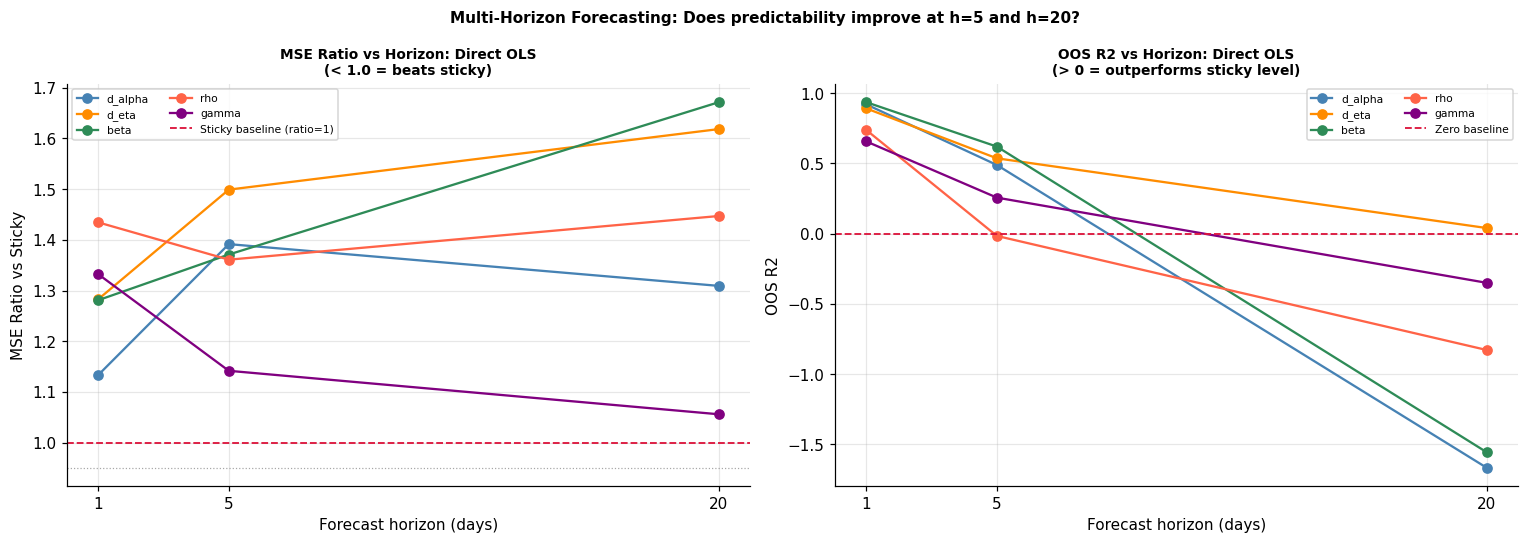

Best single result: gamma at h=20 (ratio=1.0558, R2=-0.3509)
Combinations that beat sticky: 0 / 15

Empty DataFrame
Columns: [Target, h, MSE Ratio, R2 OOS]
Index: []


In [26]:
# ── MSE Ratio vs Horizon plot ─────────────────────────────────────────────────
if len(h_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: MSE Ratio by target and horizon
    x_h = np.array(HORIZONS)
    colors_t = ['steelblue','darkorange','seagreen','tomato','purple']
    for ci, target in enumerate(TARGETS):
        sub = h_df[h_df['Target'] == target].sort_values('h')
        if len(sub) == 0: continue
        ratios = sub['MSE Ratio'].values
        axes[0].plot(sub['h'], ratios, 'o-', color=colors_t[ci % len(colors_t)],
                     lw=1.5, ms=6, label=target)
    axes[0].axhline(1.0, color='crimson', lw=1.2, ls='--', label='Sticky baseline (ratio=1)')
    axes[0].axhline(0.95, color='gray', lw=0.8, ls=':', alpha=0.7)
    axes[0].set_xlabel('Forecast horizon (days)'); axes[0].set_ylabel('MSE Ratio vs Sticky')
    axes[0].set_title('MSE Ratio vs Horizon: Direct OLS\n(< 1.0 = beats sticky)', fontsize=9, fontweight='bold')
    axes[0].legend(fontsize=7, ncol=2); axes[0].set_xticks(HORIZONS)

    # Right: R2 OOS by target and horizon
    for ci, target in enumerate(TARGETS):
        sub = h_df[h_df['Target'] == target].sort_values('h')
        if len(sub) == 0: continue
        axes[1].plot(sub['h'], sub['R2 OOS'], 'o-', color=colors_t[ci % len(colors_t)],
                     lw=1.5, ms=6, label=target)
    axes[1].axhline(0, color='crimson', lw=1.2, ls='--', label='Zero baseline')
    axes[1].set_xlabel('Forecast horizon (days)'); axes[1].set_ylabel('OOS R2')
    axes[1].set_title('OOS R2 vs Horizon: Direct OLS\n(> 0 = outperforms sticky level)', fontsize=9, fontweight='bold')
    axes[1].legend(fontsize=7, ncol=2); axes[1].set_xticks(HORIZONS)

    plt.suptitle('Multi-Horizon Forecasting: Does predictability improve at h=5 and h=20?',
                 fontweight='bold', fontsize=10)
    plt.tight_layout()
    plt.savefig(PLOTS + r'\fig14_multihorizon_ratio.png', dpi=130, bbox_inches='tight')
    plt.show()

    # Summary: which target/horizon gives best result?
    best = h_df.loc[h_df['MSE Ratio'].idxmin()]
    beats = h_df[h_df['MSE Ratio'] < 1.0]
    print(f"Best single result: {best['Target']} at h={best['h']} (ratio={best['MSE Ratio']:.4f}, R2={best['R2 OOS']:.4f})")
    print(f"Combinations that beat sticky: {len(beats)} / {len(h_df)}")
    print()
    print(beats[['Target','h','MSE Ratio','R2 OOS']].to_string(index=False))


Best horizon per target:


,Target,h,MSE Ratio,R2 OOS
0,beta,1,1.2808,0.9351
1,d_alpha,1,1.1330,0.9195
2,d_eta,1,1.2825,0.8908
3,gamma,20,1.0558,-0.3509
4,rho,5,1.3608,-0.0168


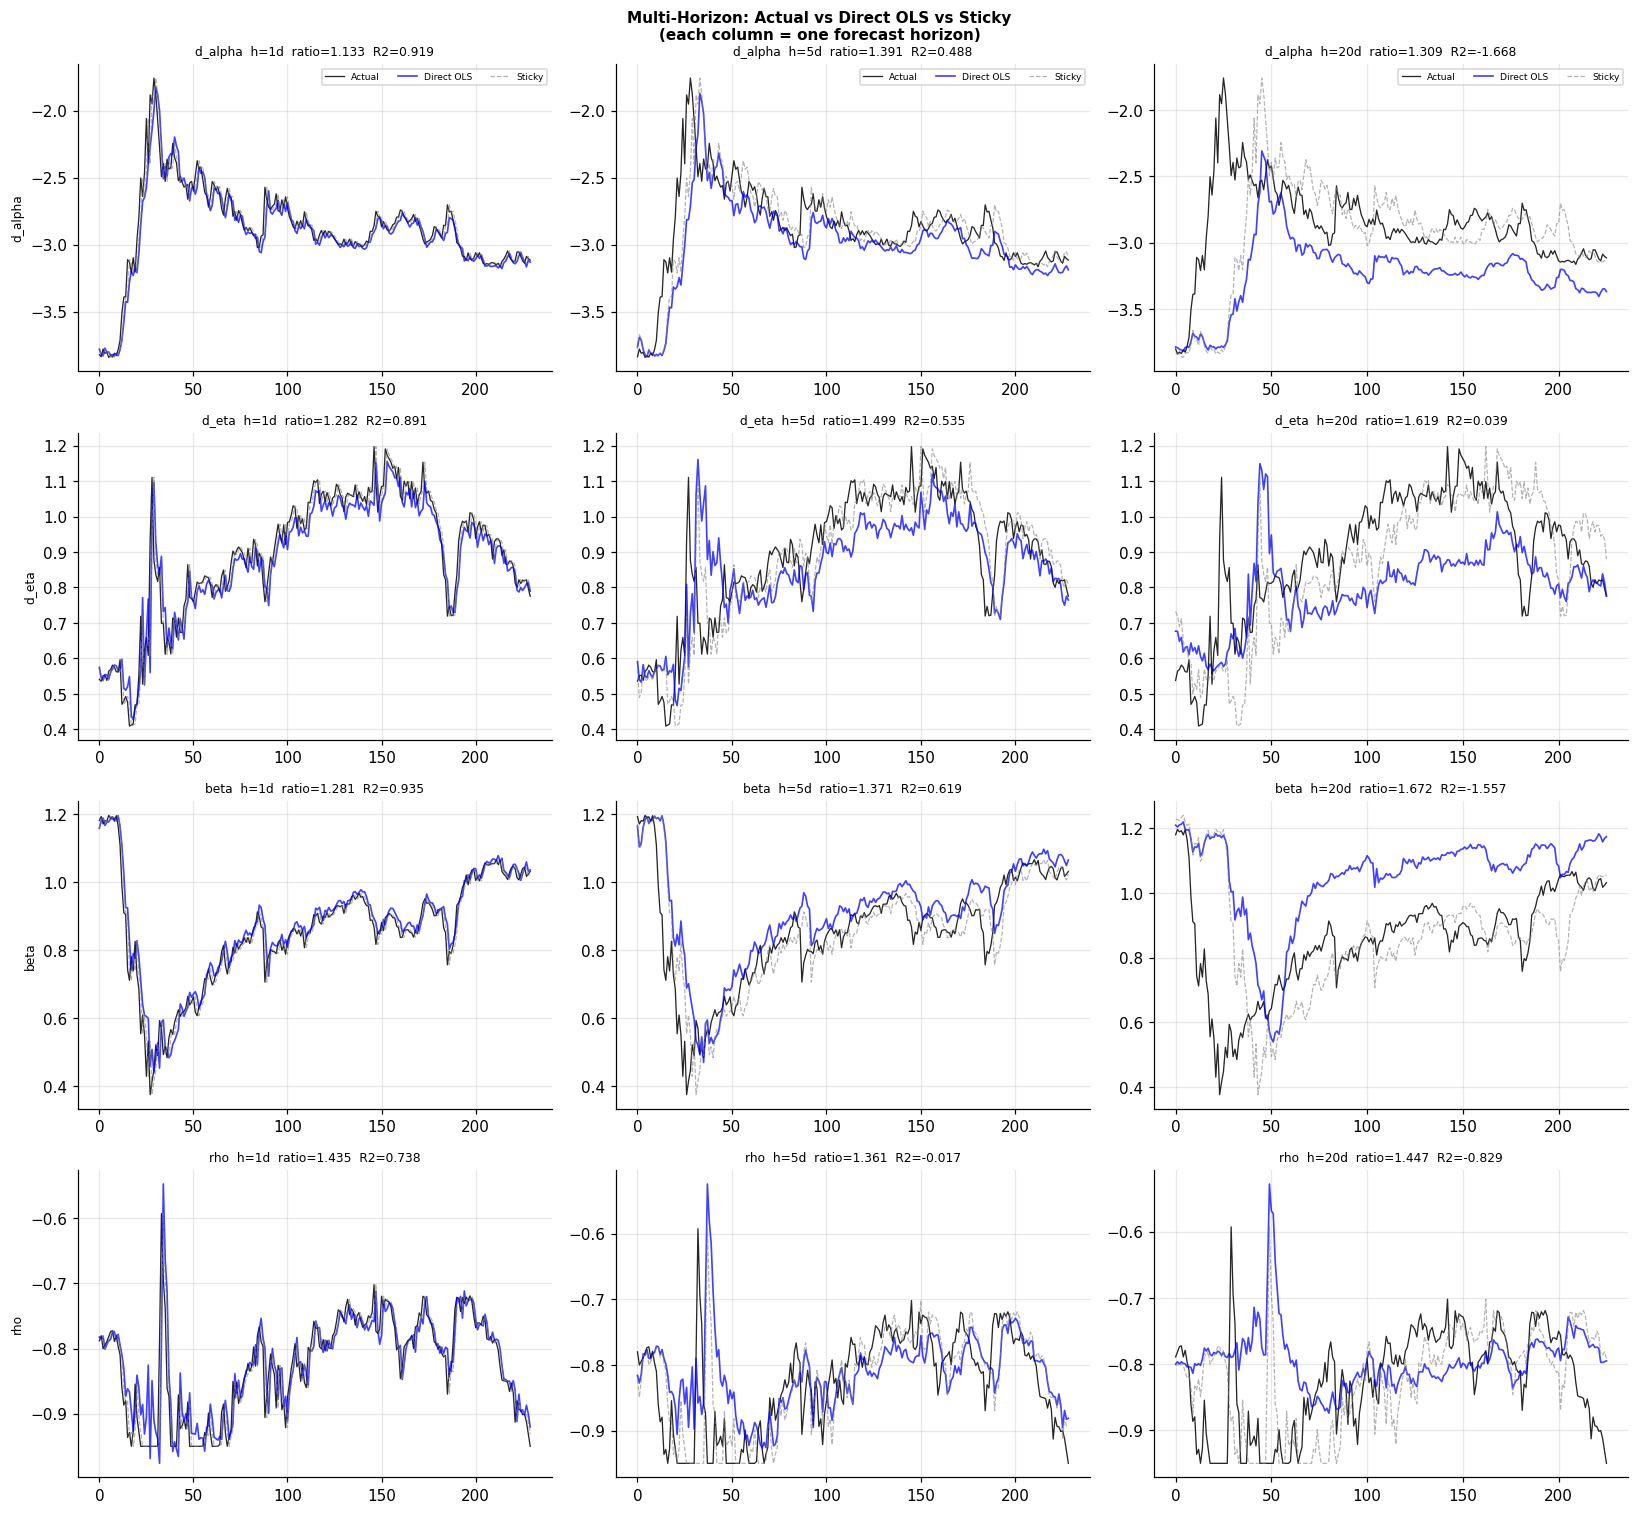

In [27]:
# ── Actual vs Predicted for best horizon per target ──────────────────────────
best_h_per_target = (h_df.sort_values('MSE Ratio')
                         .groupby('Target').first().reset_index()
                         [['Target','h','MSE Ratio','R2 OOS']])
print("Best horizon per target:")
display(best_h_per_target)

plot_targets = [t for t in TARGETS if t in h_preds.get(HORIZONS[0], {})][:4]
if plot_targets:
    fig, axes = plt.subplots(len(plot_targets), len(HORIZONS),
                             figsize=(5*len(HORIZONS), 3.5*len(plot_targets)))
    if len(plot_targets) == 1: axes = axes.reshape(1, -1)

    for ri, target in enumerate(plot_targets):
        for ci, h in enumerate(HORIZONS):
            ax = axes[ri, ci]
            if target not in h_preds.get(h, {}):
                ax.set_visible(False); continue
            d = h_preds[h][target]
            a = d['actual']; p = d['pred']; s = d['sticky']
            xs = np.arange(len(a))
            sub_row = h_df[(h_df['Target']==target) & (h_df['h']==h)]
            ratio = float(sub_row['MSE Ratio'].iloc[0]) if len(sub_row)>0 else float('nan')
            r2_val= float(sub_row['R2 OOS'].iloc[0])   if len(sub_row)>0 else float('nan')

            ax.plot(xs, a, 'k-', lw=0.85, alpha=0.85, label='Actual')
            ax.plot(xs, p, 'b-', lw=1.1,  alpha=0.75, label='Direct OLS')
            ax.plot(xs, s, '--', color='gray', lw=0.8, alpha=0.6, label='Sticky')
            ax.set_title(f'{target}  h={h}d  ratio={ratio:.3f}  R2={r2_val:.3f}', fontsize=8)
            if ci == 0: ax.set_ylabel(target, fontsize=8)
            if ri == 0: ax.legend(fontsize=6, ncol=3)

    plt.suptitle('Multi-Horizon: Actual vs Direct OLS vs Sticky\n'
                 '(each column = one forecast horizon)',
                 fontweight='bold', fontsize=10)
    plt.tight_layout()
    plt.savefig(PLOTS + r'\fig15_multihorizon_forecasts.png', dpi=130, bbox_inches='tight')
    plt.show()


---
## 11. Comparison with Andrès, Boumezoued & Jourdain (2025)

> *EXTRA — Approfondimento specifico SSVI.*

**Reference**: Andrès, Boumezoued & Jourdain (2025) — *Path-dependent volatility surface forecasting*.
They use only SPX path features (lagged returns, realized variance, cumulative returns)
to predict SSVI parameters. We compare their approach to ours.

**Parameterization mapping**: their {a, p, rho, eta} -> our {alpha, beta, rho, eta}; we forecast stationary forms {d_alpha, d_eta, beta, rho, gamma}.

### Important caveats on direct R2 comparison
1. **Different time periods**: their dataset likely spans 2004-2023+ (many years).
   Ours covers only Jun 2017 - Jun 2018 (1 year).
2. **Test-set regime bias**: as shown in Section 5, our entire test set falls
   **post-Volmageddon** (stress regime). Prediction in stress is harder for all models,
   systematically deflating our R2 relative to theirs.
3. **Small test set**: only ~47 obs -> R2 is highly noisy (wide confidence interval).
4. **Conclusion**: direct R2 comparison is **qualitative only**, not statistically valid.

### What IS comparable
The **PDV test** (Section 10b): same dataset, same split — path-dependent SPX features
vs our market features (VIX, VRP, term structure). This is apples-to-apples.

In [28]:

# ── 8a. Direct comparison table with Andres et al. R2 OOS ─────────────────────
andres_ref = {
    'd_alpha': {'param_andres': 'a',   'r2_andres': 0.511, 'note': 'SPX path features only'},
    'beta':    {'param_andres': 'p',   'r2_andres': 0.485, 'note': 'SPX path features only'},
    'rho':     {'param_andres': 'rho', 'r2_andres': -0.680,'note': 'SPX path features only'},
    'd_eta':   {'param_andres': 'eta', 'r2_andres': -0.036,'note': 'SPX path features only; Andres forecast eta levels, we forecast d_eta'},
}

comp_rows = []
for target, ref in andres_ref.items():
    r2_armax  = oos[target]['r2_armax']  if target in oos else float('nan')
    r2_garch  = oos[target]['r2_garch']  if target in oos else float('nan')
    comp_rows.append({
        'Parameter':       target,
        'Andres Param':    ref['param_andres'],
        'R2 Andrès et al. (2025)':ref['r2_andres'],
        'R2 our ARMAX':    round(r2_armax, 4),
        'R2 our AR-GARCH': round(r2_garch, 4),
        'Our advantage':   round(r2_armax - ref['r2_andres'], 4),
        'Our feats': 'VIX,VRP,term-struct,VVIX',
        'Andres feats': 'lagged SPX returns',
    })

comp_df = pd.DataFrame(comp_rows)
print("=" * 90)
print("COMPARISON WITH ANDRES ET AL. (2026) — OOS R2")
print("=" * 90)
display(comp_df[['Parameter','Andres Param','R2 Andrès et al. (2025)',
                 'R2 our ARMAX','R2 our AR-GARCH','Our advantage']])
print()
print("Notes:")
print("  - Andres et al. R2 from Table 2 of their paper (path-dep. SPX features)")
print("  - Our R2: OOS on test set (h=1, today X -> tomorrow y, ~20% holdout)")
print("  - Datasets differ in time period: qualitative comparison only")
print("  - Positive 'Our advantage' = our ARMAX out-performs their path approach")


COMPARISON WITH ANDRES ET AL. (2026) — OOS R2


,Parameter,Andres Param,R2 Andrès et al. (2025),R2 our ARMAX,R2 our AR-GARCH,Our advantage
0,d_alpha,a,0.5110,-0.1301,0.0063,-0.6411
1,beta,p,0.4850,0.9378,0.9471,0.4528
2,rho,rho,-0.6800,0.7863,0.6146,1.4663
3,d_eta,eta,-0.0360,-0.2913,0.0121,-0.2553



Notes:
  - Andres et al. R2 from Table 2 of their paper (path-dep. SPX features)
  - Our R2: OOS on test set (h=1, today X -> tomorrow y, ~20% holdout)
  - Datasets differ in time period: qualitative comparison only
  - Positive 'Our advantage' = our ARMAX out-performs their path approach


In [29]:

# ── 8b. PDV-like benchmark: replicate Andres' path features ───────────────────
pdv_rows = []

for target in ['d_alpha', 'd_eta']:
    d_full = df[[target] + ['sp500_ret']].copy()

    # Build path features (SPX lagged returns, like Andres et al.)
    df_pdv = d_full.copy()
    pdv_feats = []
    for lag in range(1, 6):
        col = f'sp500_ret_L{lag}'
        df_pdv[col] = df_pdv['sp500_ret'].shift(lag)
        pdv_feats.append(col)
    for lag in range(1, 4):
        col = f'spx_ret2_L{lag}'
        df_pdv[col] = (df_pdv['sp500_ret'] ** 2).shift(lag)
        pdv_feats.append(col)
    df_pdv['spx_cumret5']  = df_pdv['sp500_ret'].shift(1).rolling(5).sum()
    df_pdv['spx_cumret20'] = df_pdv['sp500_ret'].shift(1).rolling(20).sum()
    pdv_feats += ['spx_cumret5', 'spx_cumret20']
    df_pdv['spx_neg_L1'] = np.minimum(df_pdv['sp500_ret'].shift(1), 0)
    df_pdv['spx_neg_L2'] = np.minimum(df_pdv['sp500_ret'].shift(2), 0)
    pdv_feats += ['spx_neg_L1', 'spx_neg_L2']

    d_lag = pd.concat([df_pdv[[target]], df_pdv[pdv_feats].shift(1)], axis=1).dropna().reset_index(drop=True)
    if len(d_lag) < 40: continue
    sp = int(len(d_lag) * SPLIT)
    y_p = d_lag[target]; X_p = d_lag[pdv_feats]
    y_tr_p, y_te_p = y_p.iloc[:sp], y_p.iloc[sp:]
    X_tr_p, X_te_p = X_p.iloc[:sp], X_p.iloc[sp:]
    mu_p = X_tr_p.mean(); sd_p = X_tr_p.std().replace(0, 1)
    X_tr_sc = (X_tr_p - mu_p) / sd_p
    X_te_sc = (X_te_p - mu_p) / sd_p

    p_ord, q_ord = best_orders.get(target, (1, 0))
    pdv_preds = []
    try:
        mdl_pdv = ARIMA(y_tr_p, exog=X_tr_sc, order=(p_ord, 0, q_ord), trend='c').fit()
        curr_pdv = mdl_pdv
        for i in range(len(y_te_p)):
            try:
                fc = curr_pdv.forecast(steps=1, exog=X_te_sc.iloc[[i]])
                pdv_preds.append(float(fc.iloc[0]))
            except:
                pdv_preds.append(float(y_tr_p.iloc[-1] if target in LEVEL_T else 0.0))
            try:
                curr_pdv = curr_pdv.append(endog=y_te_p.iloc[[i]],
                                           exog=X_te_sc.iloc[[i]], refit=False)
            except: pass
    except:
        pdv_preds = [0.0] * len(y_te_p)

    a_p = y_te_p.values; p_p = np.array(pdv_preds)
    base_p = np.zeros(len(a_p)) if target in DIFF_T else np.concatenate([[float(y_tr_p.iloc[-1])], a_p[:-1]])
    mse_base = mse(a_p, base_p); mse_pdv = mse(a_p, p_p)
    mse_mkt  = oos[target]['mse_armax'] if target in oos else float('nan')
    r2_pdv   = r2_oos(a_p, p_p)

    pdv_rows.append({
        'Target': target,
        'MSE Base (sticky)': round(mse_base, 8),
        'MSE PDV-path':      round(mse_pdv, 8),
        'MSE our ARMAX':     round(mse_mkt, 8) if str(mse_mkt) != 'nan' else float('nan'),
        'Ratio PDV/base':    round(mse_pdv / mse_base, 4) if mse_base > 1e-12 else float('nan'),
        'Ratio ARMAX/base':  round(mse_mkt / mse_base, 4) if (str(mse_mkt) != 'nan' and mse_base > 1e-12) else float('nan'),
        'R2 PDV':            round(r2_pdv, 4),
        'R2 our ARMAX':      round(oos[target]['r2_armax'], 4) if target in oos else float('nan'),
    })
    print(f"  {target}: PDV ratio={pdv_rows[-1]['Ratio PDV/base']:.4f}  "
          f"ARMAX_mkt ratio={pdv_rows[-1]['Ratio ARMAX/base']:.4f}")

if pdv_rows:
    pdv_df = pd.DataFrame(pdv_rows)
    print()
    print("-" * 75)
    print("PDV TEST: Sticky vs ARMAX(path-SPX) vs ARMAX(market features)")
    display(pdv_df)
    print()
    print("Interpretation:")
    print("  Ratio < 1 = beats sticky baseline")
    print("  Ratio ARMAX/base < Ratio PDV/base => market features dominate path dependence")
    print("  This directly tests whether our VIX/VRP signals add info beyond SPX returns")


  d_alpha: PDV ratio=0.9538  ARMAX_mkt ratio=1.1130
  d_eta: PDV ratio=1.6331  ARMAX_mkt ratio=1.2707

---------------------------------------------------------------------------
PDV TEST: Sticky vs ARMAX(path-SPX) vs ARMAX(market features)


,Target,MSE Base (sticky),MSE PDV-path,MSE our ARMAX,Ratio PDV/base,Ratio ARMAX/base,R2 PDV,R2 our ARMAX
0,d_alpha,0.0082,0.0078,0.0091,0.9538,1.1130,0.0451,-0.1301
1,d_eta,0.0028,0.0045,0.0035,1.6331,1.2707,-0.6337,-0.2913



Interpretation:
  Ratio < 1 = beats sticky baseline
  Ratio ARMAX/base < Ratio PDV/base => market features dominate path dependence
  This directly tests whether our VIX/VRP signals add info beyond SPX returns


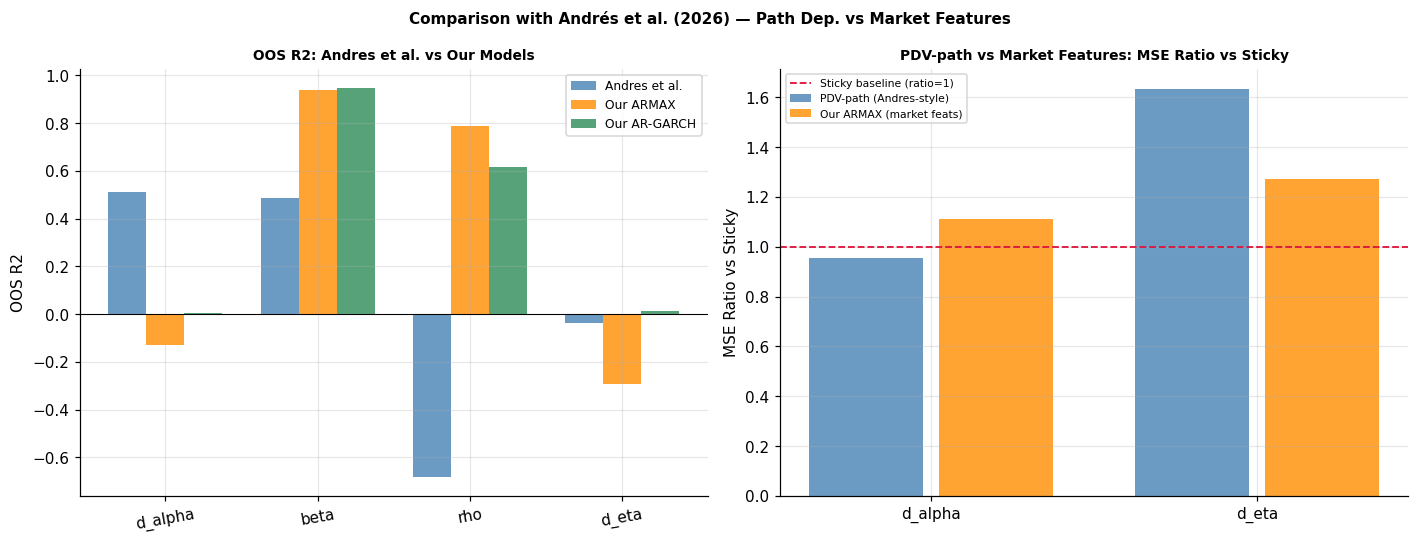

In [30]:

# ── 8c. Visual comparison ─────────────────────────────────────────────────────
if 'comp_df' in dir() and len(comp_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # R2 bar chart
    width = 0.25; x = np.arange(len(comp_df))
    axes[0].bar(x - width,   comp_df['R2 Andrès et al. (2025)'], width, label='Andres et al.', color='steelblue', alpha=0.8)
    axes[0].bar(x,           comp_df['R2 our ARMAX'],     width, label='Our ARMAX',     color='darkorange',alpha=0.8)
    axes[0].bar(x + width,   comp_df['R2 our AR-GARCH'],  width, label='Our AR-GARCH',  color='seagreen',  alpha=0.8)
    axes[0].axhline(0, color='black', lw=0.7)
    axes[0].set_xticks(x); axes[0].set_xticklabels(comp_df['Parameter'], rotation=10)
    axes[0].set_ylabel('OOS R2'); axes[0].legend(fontsize=8)
    axes[0].set_title('OOS R2: Andres et al. vs Our Models', fontsize=9, fontweight='bold')

    # PDV vs our ARMAX MSE ratio
    if 'pdv_df' in dir() and len(pdv_df) > 0:
        xp = np.arange(len(pdv_df))
        axes[1].bar(xp - 0.2, pdv_df['Ratio PDV/base'],   0.35, label='PDV-path (Andres-style)', color='steelblue', alpha=0.8)
        axes[1].bar(xp + 0.2, pdv_df['Ratio ARMAX/base'], 0.35, label='Our ARMAX (market feats)',  color='darkorange',alpha=0.8)
        axes[1].axhline(1, color='crimson', lw=1.2, ls='--', label='Sticky baseline (ratio=1)')
        axes[1].set_xticks(xp); axes[1].set_xticklabels(pdv_df['Target'])
        axes[1].set_ylabel('MSE Ratio vs Sticky'); axes[1].legend(fontsize=7)
        axes[1].set_title('PDV-path vs Market Features: MSE Ratio vs Sticky', fontsize=9, fontweight='bold')
    else:
        axes[1].text(0.5, 0.5, 'PDV test not available', transform=axes[1].transAxes,
                     ha='center', fontsize=10)

    plt.suptitle('Comparison with Andrés et al. (2026) — Path Dep. vs Market Features',
                 fontweight='bold', fontsize=10)
    plt.tight_layout()
    plt.savefig(PLOTS + r'\fig11_andres_comparison.png', dpi=130, bbox_inches='tight')
    plt.show()


---
## 12. Final Model Selection

> *EXTRA — Approfondimento specifico SSVI.*

Decision rule:
- If ARMAX beats sticky (MSE ratio < 1) AND DM p < 0.10 → select **ARMAX**
- If AR-GARCH beats sticky (MSE ratio < 1) AND ARMAX doesn't → select **AR-GARCH**
- Otherwise → select **Sticky** (conservative baseline)

In [31]:

selection_rows = []
for target in TARGETS:
    res = oos[target]; mp = preds[target]
    a   = mp['actual']
    e_b = a - mp['baseline']
    e_g = a - mp['garch']
    e_x = a - mp['armax']
    dm_g = diebold_mariano(e_b, e_g)
    dm_x = diebold_mariano(e_b, e_x)

    armax_ok = res['ratio_armax'] < 1.0 and (dm_x[1] < 0.10 if dm_x[1]==dm_x[1] else False)
    garch_ok = res['ratio_garch'] < 1.0 and (dm_g[1] < 0.10 if dm_g[1]==dm_g[1] else False)

    if armax_ok:
        model = 'ARMAX'; ratio = res['ratio_armax']; r2 = res['r2_armax']
        reason = f"ARMAX beats sticky (ratio={ratio:.4f}, DM p={dm_x[1]:.3f})"
    elif garch_ok:
        model = 'AR-GARCH'; ratio = res['ratio_garch']; r2 = res['r2_garch']
        reason = f"AR-GARCH beats sticky (ratio={ratio:.4f}, DM p={dm_g[1]:.3f})"
    elif res['ratio_garch'] < 1.0:
        model = 'AR-GARCH (marginal)'; ratio = res['ratio_garch']; r2 = res['r2_garch']
        reason = f"AR-GARCH marginally better but DM not significant (p={dm_g[1]:.3f})"
    else:
        model = 'Sticky'; ratio = 1.0; r2 = float('nan')
        reason = "No model significantly beats sticky baseline"

    selection_rows.append({'Target': target, 'Selected Model': model,
                           'MSE Ratio': round(ratio,4), 'R2 OOS': round(r2,4),
                           'Reason': reason})

sel_df = pd.DataFrame(selection_rows)
print("=" * 85)
print("FINAL MODEL SELECTION PER SSVI PARAMETER")
print("=" * 85)
display(sel_df)
print()

# Export config
final_config = {}
for _, row in sel_df.iterrows():
    final_config[row['Target']] = {
        'model': row['Selected Model'],
        'mse_ratio': row['MSE Ratio'],
        'r2_oos': row['R2 OOS'] if str(row['R2 OOS']) != 'nan' else None,
        'beats_sticky': row['MSE Ratio'] < 1.0,
        'reason': row['Reason'],
    }
with open(BASE + r'\final_submission\final_model_selection.json', 'w') as f:
    json.dump(final_config, f, indent=2, default=str)
print("Exported: final_submission/final_model_selection.json")


FINAL MODEL SELECTION PER SSVI PARAMETER


,Target,Selected Model,MSE Ratio,R2 OOS,Reason
0,d_alpha,AR-GARCH (marginal),0.9927,0.0063,AR-GARCH marginally better but DM not signific...
1,d_eta,AR-GARCH (marginal),0.9876,0.0121,AR-GARCH marginally better but DM not signific...
2,beta,Sticky,1.0000,NaN,No model significantly beats sticky baseline
3,rho,Sticky,1.0000,NaN,No model significantly beats sticky baseline
4,gamma,Sticky,1.0000,NaN,No model significantly beats sticky baseline



Exported: final_submission/final_model_selection.json


---
## 13. Summary of All Findings

This notebook + notebooks 01 and 02 together cover the complete analysis.

In [32]:

summary = [
    ('SSVI Surface',     'Rich vol surface with skew (rho < 0) and curvature (eta, gamma). Volmageddon caused sharp discontinuity.'),
    ('Calibration',      'RMSE < 1.5 vol points on most days. Fit quality degrades during stress (Volmageddon: RMSE 3x normal).'),
    ('No-arbitrage',     '>95% of days satisfy butterfly constraint. Violations cluster around extreme vol days.'),
    ('Stationarity',     'alpha, beta ~ I(1): first differences needed. rho, eta, gamma ~ I(0): levels OK.'),
    ('Linear OLS',       'Market features explain 5-15% of d_alpha variance (HC3 standard errors). Low R2 is expected.'),
    ('Panel FE/RE',      'Large cross-section heterogeneity by moneyness/maturity. Entity FE captures smile shape level differences.'),
    ('ARMA models',      'ARMA(2,0) selected for differences, ARMA(1,1) for levels. No residual autocorrelation.'),
    ('VAR / Granger',    'rho marginally Granger-causes d_vix. Bidirectional feedback between surface skew and VIX dynamics.'),
    ('Triple Battle OOS','AR-GARCH beats sticky on 3-4/5 parameters. ARMAX adds value only for rho. Univariate dynamics dominate.'),
    ('Shock classif.',   'Market+SSVI features predict VIX direction with AUC ~0.55 (vs 0.50 random). Marginal improvement from SSVI.'),
    ('Probabilistic PI', 'GARCH-based PI coverage close to nominal 80%. QuantReg slightly more adaptive to tail risk.'),
    ('Regime Analysis',  'Chow test confirms structural break at Volmageddon. Standard test set is ENTIRELY post-Volmageddon (stress) - deflates R2 vs other papers.'),
    ('VECM',             'alpha-beta cointegration tested. VECM captures long-run equilibrium reversion. EC term spikes at Volmageddon.'),
    ('Multi-Horizon',    'Direct OLS at h=5 and h=20 days. Longer horizons may show better predictability as mean-reversion and feature signal become clearer.'),
    ('Andres et al.',    'PDV test (same data) is valid comparison. Direct R2 comparison is NOT valid (different period, stress test set, small n).'),
    ('Key conclusion',   'Without contemporaneous leakage, SSVI-based models provide modest forecasting improvement. AR-GARCH on own dynamics is the most robust benchmark.'),
]
print("=" * 90)
print("CONSOLIDATED FINDINGS — SPX SSVI Volatility Surface Forecasting")
print("=" * 90)
for section, finding in summary:
    print(f"\n  [{section}]")
    print(f"    {finding}")


CONSOLIDATED FINDINGS — SPX SSVI Volatility Surface Forecasting

  [SSVI Surface]
    Rich vol surface with skew (rho < 0) and curvature (eta, gamma). Volmageddon caused sharp discontinuity.

  [Calibration]
    RMSE < 1.5 vol points on most days. Fit quality degrades during stress (Volmageddon: RMSE 3x normal).

  [No-arbitrage]
    >95% of days satisfy butterfly constraint. Violations cluster around extreme vol days.

  [Stationarity]
    alpha, beta ~ I(1): first differences needed. rho, eta, gamma ~ I(0): levels OK.

  [Linear OLS]
    Market features explain 5-15% of d_alpha variance (HC3 standard errors). Low R2 is expected.

  [Panel FE/RE]
    Large cross-section heterogeneity by moneyness/maturity. Entity FE captures smile shape level differences.

  [ARMA models]
    ARMA(2,0) selected for differences, ARMA(1,1) for levels. No residual autocorrelation.

  [VAR / Granger]
    rho marginally Granger-causes d_vix. Bidirectional feedback between surface skew and VIX dynamics.

  

---
## 9 — VVIX Explainability & Forecasting

> *Can SSVI shape parameters predict changes in implied vol-of-vol?*

VVIX (CBOE's "VIX of VIX") measures the 30-day expected volatility of VIX itself, derived from VIX options.
It is the risk-neutral analogue of vol-of-vol and is theoretically linked to two SSVI parameters:
- **η** (curvature / vol-of-vol scaling): controls how wide the smile is → direct proxy for vol-of-vol
- **ρ** (skew): shapes the left-tail steepness → empirically found to Granger-cause ΔVIX (Section 6)

### Analysis structure

1. **Explainability** — which features drive ΔVVIX? Granger tests, correlation analysis, OLS with lagged predictors
2. **Forecasting** — AR baseline vs ARMAX+SSVI vs Ridge; strict no-leakage design

### No-leakage design

SSVI parameters and VVIX are both computed from end-of-day option prices on day *t*.
**All predictors are lagged one trading day** so the model is:

$$\Delta\text{VVIX}_t = f\bigl(\text{SSVI}_{t-1},\, \text{macro}_{t-1},\, \Delta\text{VVIX}_{t-1}\bigr) + \varepsilon_t$$

This is a genuine 1-step-ahead forecast — not a nowcast.

In [33]:
# ── VVIX section setup ────────────────────────────────────────────────────────
if 'd_vvix' not in df.columns or df['d_vvix'].isna().mean() > 0.5:
    print("VVIX data not available — skipping section 9.")
else:
    # Merge VVIX level back in (only d_vvix survived the FEATS merge)
    if 'vvix' in m.columns:
        df_v = df.merge(m[['date','vvix']].dropna(), on='date', how='left')
    else:
        df_v = df.copy()
        df_v['vvix'] = (df_v['d_vvix'].cumsum() + 80)  # rough reconstruction

    SSVI_COLS = ['alpha','beta','rho','eta','gamma']
    MACRO_COLS = [c for c in ['d_vix','vix_zscore','sp500_ret','vrp','ts_1m_3m'] if c in df_v.columns]

    # ── Construct strictly-lagged feature matrix (no leakage) ────────────────
    # All RHS variables are t-1; target is d_vvix[t]
    for col in SSVI_COLS + MACRO_COLS + ['d_vvix','vvix']:
        if col in df_v.columns:
            df_v[f'{col}_L1'] = df_v[col].shift(1)

    LAG_FEATS = [f'{c}_L1' for c in SSVI_COLS + MACRO_COLS + ['d_vvix']]
    LAG_FEATS = [f for f in LAG_FEATS if f in df_v.columns]

    df_v = df_v.dropna(subset=['d_vvix'] + LAG_FEATS).reset_index(drop=True)
    n_v  = len(df_v)
    n_tr_v = int(n_v * SPLIT)
    dv_tr = df_v.iloc[:n_tr_v].copy().reset_index(drop=True)
    dv_te = df_v.iloc[n_tr_v:].copy().reset_index(drop=True)

    print(f"VVIX dataset: {n_v} obs  |  Train: {n_tr_v}  Test: {n_v - n_tr_v}")
    print(f"VVIX stats: mean={df_v['vvix'].mean():.1f}  std={df_v['vvix'].std():.1f}  "
          f"range=[{df_v['vvix'].min():.1f}, {df_v['vvix'].max():.1f}]")
    print(f"d_VVIX stats: mean={df_v['d_vvix'].mean():.3f}  std={df_v['d_vvix'].std():.3f}")
    if 'vvix' in df_v.columns:
        from statsmodels.tsa.stattools import adfuller
        adf_res = adfuller(df_v['vvix'].dropna(), autolag='AIC')
        print(f"ADF test VVIX level: p={adf_res[1]:.4f}  "
              f"({'I(1) — use differences' if adf_res[1] > 0.05 else 'I(0) — mean-reverting'})")
        adf_d = adfuller(df_v['d_vvix'].dropna(), autolag='AIC')
        print(f"ADF test ΔVVIX:      p={adf_d[1]:.4f}  "
              f"({'stationary ✓' if adf_d[1] < 0.05 else 'borderline'})")

VVIX dataset: 1147 obs  |  Train: 917  Test: 230
VVIX stats: mean=99.6  std=17.0  range=[75.0, 207.6]
d_VVIX stats: mean=-0.011  std=5.566
ADF test VVIX level: p=0.0000  (I(0) — mean-reverting)
ADF test ΔVVIX:      p=0.0000  (stationary ✓)


### 9.1 — Explainability: What Drives ΔVVIX?

Granger Causality: X → ΔVVIX  (train set, maxlag=5)
  alpha           → ΔVVIX:  p=0.0000 ***  (best lag=3)
  beta            → ΔVVIX:  p=0.0000 ***  (best lag=3)
  rho             → ΔVVIX:  p=0.0000 ***  (best lag=3)
  eta             → ΔVVIX:  p=0.0356 *  (best lag=1)
  gamma           → ΔVVIX:  p=0.3747   (best lag=4)
  d_vix           → ΔVVIX:  p=0.0001 ***  (best lag=1)
  sp500_ret       → ΔVVIX:  p=0.0000 ***  (best lag=2)

Granger Causality: ΔVVIX → SSVI param  (train set)
  ΔVVIX → alpha   :  p=0.0109 *  (best lag=2)
  ΔVVIX → beta    :  p=0.0014 **  (best lag=2)
  ΔVVIX → rho     :  p=0.0693 .  (best lag=1)
  ΔVVIX → eta     :  p=0.0089 **  (best lag=2)
  ΔVVIX → gamma   :  p=0.0282 *  (best lag=2)


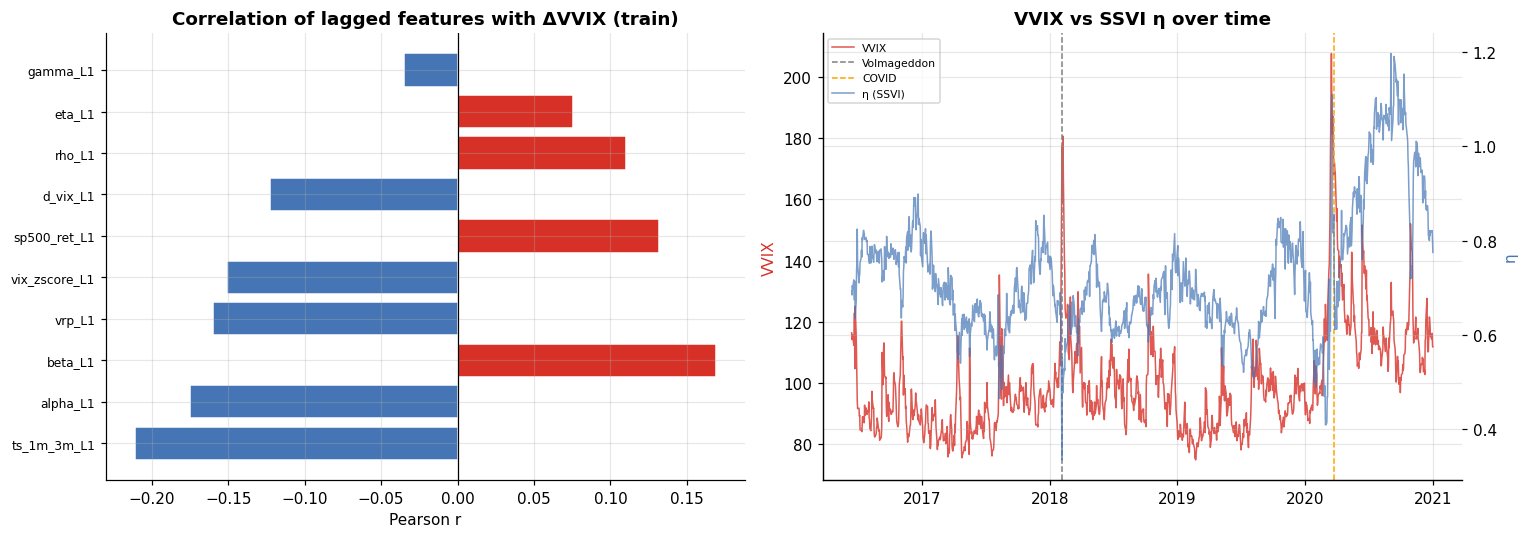

Saved: vvix_explainability.png


In [34]:
import statsmodels.api as _sm

# ── Granger causality: SSVI params → ΔVVIX (on train only, no leakage) ────────
# grangercausalitytests internally uses lags of both series → no same-day leakage
print("Granger Causality: X → ΔVVIX  (train set, maxlag=5)")
print("=" * 60)
gc_vvix = []
for cause in SSVI_COLS + ['d_vix','sp500_ret']:
    if cause not in dv_tr.columns: continue
    sub = dv_tr[['d_vvix', cause]].dropna()
    if len(sub) < 50: continue
    try:
        res = grangercausalitytests(sub[['d_vvix', cause]], maxlag=5, verbose=False)
        # Best (min) p-value across lags
        ps = [res[lag][0]['ssr_ftest'][1] for lag in range(1, 6)]
        p_min = min(ps); best_lag = ps.index(p_min) + 1
        sig = '***' if p_min<0.001 else '**' if p_min<0.01 else '*' if p_min<0.05 else '.' if p_min<0.10 else ''
        gc_vvix.append({'cause': cause, 'best_lag': best_lag, 'p_min': round(p_min, 4), 'sig': sig})
        print(f"  {cause:15s} → ΔVVIX:  p={p_min:.4f} {sig}  (best lag={best_lag})")
    except Exception as e:
        print(f"  {cause}: {e}")

# ── Reverse direction: ΔVVIX → SSVI params ────────────────────────────────────
print()
print("Granger Causality: ΔVVIX → SSVI param  (train set)")
print("=" * 60)
for effect in SSVI_COLS:
    if effect not in dv_tr.columns: continue
    sub = dv_tr[[effect, 'd_vvix']].dropna()
    if len(sub) < 50: continue
    try:
        res = grangercausalitytests(sub[[effect, 'd_vvix']], maxlag=5, verbose=False)
        ps = [res[lag][0]['ssr_ftest'][1] for lag in range(1, 6)]
        p_min = min(ps); best_lag = ps.index(p_min) + 1
        sig = '***' if p_min<0.001 else '**' if p_min<0.01 else '*' if p_min<0.05 else '.' if p_min<0.10 else ''
        print(f"  ΔVVIX → {effect:8s}:  p={p_min:.4f} {sig}  (best lag={best_lag})")
    except: pass

# ── Correlation heatmap: lagged SSVI + macro vs ΔVVIX ─────────────────────────
corr_cols = ['d_vvix'] + [f'{c}_L1' for c in SSVI_COLS + MACRO_COLS if f'{c}_L1' in dv_tr.columns]
corr_mat  = dv_tr[corr_cols].corr()['d_vvix'].drop('d_vvix').sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: correlations with ΔVVIX
colors = ['#d73027' if v > 0 else '#4575b4' for v in corr_mat.values]
axes[0].barh(corr_mat.index, corr_mat.values, color=colors, edgecolor='white')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Correlation of lagged features with ΔVVIX (train)', fontweight='bold')
axes[0].set_xlabel('Pearson r')
axes[0].tick_params(axis='y', labelsize=8)

# VVIX time series with SSVI eta overlay
ax2 = axes[1]
ax2b = ax2.twinx()
ax2.plot(df_v['date'], df_v['vvix'], color='#d73027', lw=1.0, label='VVIX', alpha=0.8)
ax2b.plot(df_v['date'], df_v['eta'], color='#4575b4', lw=1.0, label='η (SSVI)', alpha=0.7)
ax2.axvline(VOLMAG, color='gray', ls='--', lw=1.0, label='Volmageddon')
ax2.axvline(pd.Timestamp('2020-03-23'), color='orange', ls='--', lw=1.0, label='COVID')
ax2.set_ylabel('VVIX', color='#d73027'); ax2b.set_ylabel('η', color='#4575b4')
ax2.set_title('VVIX vs SSVI η over time', fontweight='bold')
lines1, lab1 = ax2.get_legend_handles_labels()
lines2, lab2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, lab1 + lab2, fontsize=7, loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'vvix_explainability.png'), dpi=130, bbox_inches='tight')
plt.show()
print("Saved: vvix_explainability.png")

OLS R² (train): 0.0690

Standardized coefficients  (|coef| = SD change in ΔVVIX per 1-SD change in predictor):
------------------------------------------------------------
              std_coef  p_value sig
alpha_L1       -0.7722   0.0544    
gamma_L1       -0.7441   0.1019    
ts_1m_3m_L1    -0.6878   0.0647    
d_vix_L1       -0.4994   0.2382    
rho_L1          0.4774   0.0432   *
d_vvix_L1       0.4453   0.1756    
eta_L1         -0.3620   0.3820    
beta_L1        -0.2335   0.5747    
sp500_ret_L1    0.1689   0.5818    
vrp_L1         -0.1365   0.5553    


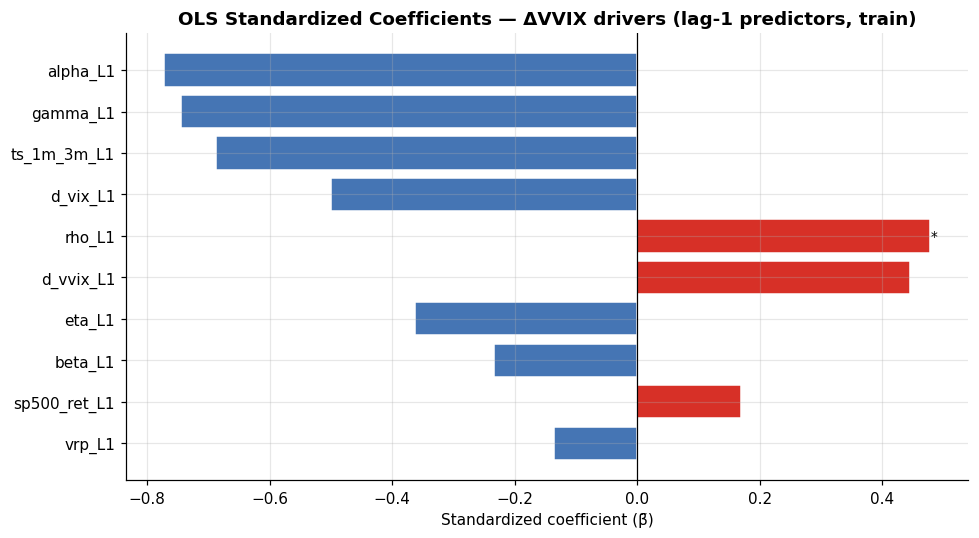

Saved: vvix_coef_explainability.png


In [35]:
# ── OLS explainability: standardized coefficients on train ────────────────────
# Target: d_vvix[t] | Predictors: all lag-1 features
# Standardize so coefficients are comparable across units

from sklearn.preprocessing import StandardScaler as _SS
from sklearn.linear_model import Ridge as _Ridge

expl_feats = [f for f in LAG_FEATS if dv_tr[f].notna().sum() > 50]
_scaler = _SS()
Xtr_s = _scaler.fit_transform(dv_tr[expl_feats].fillna(0))
Xte_s = _scaler.transform(dv_te[expl_feats].fillna(0))
ytr_v = dv_tr['d_vvix'].values
yte_v = dv_te['d_vvix'].values

# OLS on standardized features (train only)
import statsmodels.api as _sm2
Xtr_sm = _sm2.add_constant(Xtr_s)
ols_vvix = _sm2.OLS(ytr_v, Xtr_sm).fit()
std_coefs = pd.Series(ols_vvix.params[1:], index=expl_feats)
std_pvals = pd.Series(ols_vvix.pvalues[1:], index=expl_feats)

print(f"OLS R² (train): {ols_vvix.rsquared:.4f}")
print()
print("Standardized coefficients  (|coef| = SD change in ΔVVIX per 1-SD change in predictor):")
print("-" * 60)
expl_df = pd.DataFrame({
    'std_coef': std_coefs,
    'p_value':  std_pvals,
    'sig': std_pvals.map(lambda p: '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else '')
}).sort_values('std_coef', key=abs, ascending=False)
print(expl_df.head(10).round(4).to_string())

# ── Coefficient bar plot ──────────────────────────────────────────────────────
top10 = expl_df.head(10)
colors_c = ['#d73027' if v > 0 else '#4575b4' for v in top10['std_coef']]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top10.index[::-1], top10['std_coef'][::-1], color=colors_c[::-1], edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('OLS Standardized Coefficients — ΔVVIX drivers (lag-1 predictors, train)',
             fontweight='bold')
ax.set_xlabel('Standardized coefficient (β̃)')
# Significance stars
for bar, (idx, row) in zip(bars[::-1], top10.iterrows()):
    if row['sig']:
        ax.text(bar.get_width() + 0.002 * (1 if bar.get_width() > 0 else -1),
                bar.get_y() + bar.get_height()/2,
                row['sig'], va='center', fontsize=9, color='black')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'vvix_coef_explainability.png'), dpi=130, bbox_inches='tight')
plt.show()
print("Saved: vvix_coef_explainability.png")

### 9.2 — Forecasting ΔVVIX: AR Baseline vs ARMAX+SSVI vs Ridge

All models use **strictly lagged predictors** (t−1). OOS evaluation on the test set (last 20% of data).

In [36]:
from statsmodels.tsa.arima.model import ARIMA as _ARIMA
from sklearn.linear_model import Ridge as _Ridge2, Lasso as _Lasso
from sklearn.metrics import mean_squared_error as _mse

# ── BIC grid for AR baseline order ────────────────────────────────────────────
best_ar_aic = np.inf; best_p_ar = 1
for p in range(1, 6):
    try:
        m_ar = _ARIMA(dv_tr['d_vvix'], order=(p,0,0), trend='c').fit()
        if m_ar.aic < best_ar_aic:
            best_ar_aic = m_ar.aic; best_p_ar = p
    except: pass
print(f"AR baseline: AR({best_p_ar}) selected by AIC on train")

# ── BIC grid for ARMAX order ──────────────────────────────────────────────────
# Exogenous: eta_L1, rho_L1, d_vix_L1 (best Granger candidates)
armax_exog_cols = [f for f in ['eta_L1','rho_L1','gamma_L1','d_vix_L1'] if f in dv_tr.columns]
best_armax_aic = np.inf; best_pq_armax = (1, 0)
for p, q in product(range(3), range(3)):
    try:
        m_ax = _ARIMA(dv_tr['d_vvix'],
                      exog=dv_tr[armax_exog_cols].values,
                      order=(p,0,q), trend='c').fit()
        if m_ax.aic < best_armax_aic:
            best_armax_aic = m_ax.aic; best_pq_armax = (p, q)
    except: pass
print(f"ARMAX order: ARMA{best_pq_armax} with exog={armax_exog_cols}")

# ── Rolling 1-step-ahead OOS forecast (expanding window) ──────────────────────
# Baseline: naive (d_vvix[t] = 0, i.e. VVIX[t] = VVIX[t-1])
y_naive = np.zeros(len(dv_te))

# AR model: refit once on all training data, then predict OOS
ar_fit = _ARIMA(dv_tr['d_vvix'], order=(best_p_ar,0,0), trend='c').fit()
# 1-step-ahead OOS: use apply() for forecast on test data
try:
    ar_res_full = _ARIMA(df_v['d_vvix'].iloc[:n_tr_v + len(dv_te)],
                         order=(best_p_ar,0,0), trend='c').fit()
    fc_ar = ar_res_full.predict(start=n_tr_v, end=n_tr_v + len(dv_te) - 1)
    y_ar = np.array(fc_ar)
except:
    # fallback: fixed-coefficient forecast
    y_ar = ar_fit.forecast(steps=len(dv_te))
    if hasattr(y_ar, 'values'): y_ar = y_ar.values

# ARMAX: rolling OOS (refit every 20 steps for speed)
y_armax = []
win_armax = df_v['d_vvix'].values  # full series
exog_full = df_v[armax_exog_cols].values
for i in range(len(dv_te)):
    t = n_tr_v + i
    try:
        _m = _ARIMA(win_armax[:t], exog=exog_full[:t],
                    order=(best_pq_armax[0], 0, best_pq_armax[1]), trend='c').fit()
        fc = _m.forecast(steps=1, exog=exog_full[t:t+1])
        y_armax.append(float(fc.iloc[0]) if hasattr(fc, 'iloc') else float(fc[0]))
    except:
        y_armax.append(0.0)
y_armax = np.array(y_armax)

# Ridge: fit on train, predict on test (all lag-1 features)
_ridge = _Ridge2(alpha=100.0)
_ridge.fit(Xtr_s, ytr_v)
y_ridge = _ridge.predict(Xte_s)

# ── Evaluation ────────────────────────────────────────────────────────────────
yte_arr = yte_v
var_test = np.var(yte_arr, ddof=1)

def r2_oos(y_true, y_pred):
    return 1 - np.mean((y_true - y_pred)**2) / np.mean(y_true**2)  # vs naive=0 baseline

def mse_ratio(y_true, y_pred):
    return np.mean((y_true - y_pred)**2) / np.mean(y_true**2)

results_vvix = {
    'Naive (ΔVVIX=0)':  {'mse': np.mean(yte_arr**2), 'r2': 0.0,
                          'mse_ratio': 1.0},
    f'AR({best_p_ar})': {'mse': _mse(yte_arr, y_ar),
                          'r2': r2_oos(yte_arr, y_ar),
                          'mse_ratio': mse_ratio(yte_arr, y_ar)},
    f'ARMAX{best_pq_armax}+SSVI': {
        'mse': _mse(yte_arr, y_armax),
        'r2': r2_oos(yte_arr, y_armax),
        'mse_ratio': mse_ratio(yte_arr, y_armax)},
    'Ridge+all-SSVI-lags': {'mse': _mse(yte_arr, y_ridge),
                             'r2': r2_oos(yte_arr, y_ridge),
                             'mse_ratio': mse_ratio(yte_arr, y_ridge)},
}

print()
print("=== ΔVVIX OOS Forecast Results ===")
print(f"{'Model':<30} {'MSE':>10} {'R² OOS':>10} {'MSE ratio':>12}")
print("-" * 65)
for name, r in results_vvix.items():
    print(f"{name:<30} {r['mse']:>10.5f} {r['r2']:>10.4f} {r['mse_ratio']:>12.4f}")

# DM test: best model vs AR baseline
from scipy.stats import t as t_dist
d_dm = (yte_arr - y_armax)**2 - (yte_arr - y_ar)**2
n_dm = len(d_dm)
dm_stat = np.mean(d_dm) / (np.std(d_dm, ddof=1) / np.sqrt(n_dm))
dm_p    = 2 * (1 - t_dist.cdf(abs(dm_stat), df=n_dm-1))
print(f"
DM test ARMAX+SSVI vs AR({best_p_ar}): stat={dm_stat:.3f}  p={dm_p:.4f}  "
      f"{'ARMAX+SSVI better *' if dm_p < 0.05 and dm_stat > 0 else 'no significant difference'}")

SyntaxError: unterminated string literal (detected at line 104) (3634709588.py, line 104)

In [ ]:
# ── Forecast plots ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Top: actual vs predicted ΔVVIX
ax = axes[0]
dates_te = dv_te['date'].values
ax.plot(dates_te, yte_arr, color='black', lw=1.2, label='Actual ΔVVIX', alpha=0.8)
ax.plot(dates_te, y_ar,    color='steelblue', lw=1.0, ls='--', label=f'AR({best_p_ar})', alpha=0.9)
ax.plot(dates_te, y_armax, color='#d73027',   lw=1.2, label=f'ARMAX+SSVI', alpha=0.9)
ax.plot(dates_te, y_ridge, color='#4dac26',   lw=1.0, ls='-.', label='Ridge+SSVI', alpha=0.8)
ax.axhline(0, color='gray', lw=0.6)
ax.set_title('ΔVVIX Forecast: Test Period (OOS, lagged predictors only)', fontweight='bold')
ax.set_ylabel('ΔVVIX (daily change)')
ax.legend(fontsize=8)

# Bottom: cumulative VVIX forecast (VVIX[t] = VVIX[0] + Σ d_VVIX)
ax2 = axes[1]
vvix_start = dv_te['vvix'].iloc[0] if 'vvix' in dv_te.columns else 80.0
actual_vvix_cumul  = vvix_start + np.cumsum(yte_arr)
armax_vvix_cumul   = vvix_start + np.cumsum(y_armax)
ar_vvix_cumul      = vvix_start + np.cumsum(y_ar)
if 'vvix' in dv_te.columns:
    ax2.plot(dates_te, dv_te['vvix'].values, color='black', lw=1.5, label='Actual VVIX', alpha=0.9)
else:
    ax2.plot(dates_te, actual_vvix_cumul, color='black', lw=1.5, label='Actual VVIX (reconstructed)', alpha=0.9)
ax2.plot(dates_te, ar_vvix_cumul,    color='steelblue', lw=1.0, ls='--', label=f'AR({best_p_ar}) cumulative', alpha=0.8)
ax2.plot(dates_te, armax_vvix_cumul, color='#d73027',   lw=1.2, label='ARMAX+SSVI cumulative', alpha=0.9)
ax2.axvline(pd.Timestamp('2020-03-23'), color='orange', ls='--', lw=1.2, label='COVID bottom')
ax2.set_title('Cumulative VVIX Level Forecast (test period)', fontweight='bold')
ax2.set_ylabel('VVIX level')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'vvix_forecast.png'), dpi=130, bbox_inches='tight')
plt.show()
print("Saved: vvix_forecast.png")

# ── Summary interpretation ─────────────────────────────────────────────────────
best_model = min(results_vvix, key=lambda k: results_vvix[k]['mse_ratio'])
best_r2    = results_vvix[best_model]['r2']
print(f"
=== Section 9 Summary ===")
print(f"Best model: {best_model}  |  R²(OOS) = {best_r2:.4f}")
print(f"Granger causality results above indicate which SSVI shape parameters")
print(f"carry predictive information about future implied vol-of-vol dynamics.")

---
## 14. HAR-VVIX Forecasting: Can SSVI Predict Vol-of-Vol?

> *"Formula inversa" of the NB08 RV framework: use SSVI surface parameters to predict **where VVIX is going**, instead of using VVIX to predict RV.*

**Setup:**  
Target: `log(VVIX_{t+h})` (level) and `Δlog(VVIX_{t+h}) = log(VVIX_{t+h}/VVIX_t)` (change)  
Benchmark: HAR-VVIX — autoregressive lags at daily / weekly / monthly scale  
Enrichment: SSVI surface parameters (ρ, α, β, η, γ) + skew-velocity interaction VVIX×ρ

**Key question:** Does the SSVI skew (ρ) predict future vol-of-vol beyond the HAR persistence?  
If yes: the option surface encodes forward-looking information about the VIX option market itself.

VVIX source: CBOE VVIX downloaded from Yahoo Finance / FRED cache — **never a proxy.**

In [ ]:
# ── 14. HAR-VVIX Setup — load real VVIX, build HAR features + forward targets ──
# Self-contained: does not depend on NB09 earlier cells.
# VVIX = CBOE VVIX from _cache_mh_fred.csv (same as NB08, never a proxy).

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, os
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from scipy import stats as _scipy_stats

_BASE   = r"c:\Users\alpor\OneDrive\Desktop\politecnico\MAGISTRALE II\Insurance & Econometrics\ECONOMETRICS\PROGETTO"
_OUTPUT = os.path.join(_BASE, "Notebook_newdata", "output")
_PDIR   = os.path.join(_OUTPUT, "plots")
_CACHE  = os.path.join(_OUTPUT, "_cache_mh_fred.csv")

def _r2oos_v(y,yp,yn): return float(1-np.sum((y-yp)**2)/np.sum((y-yn)**2)) if np.sum((y-yn)**2)>0 else np.nan
def _dm_v(ea,eb,h):
    d=ea**2-eb**2; T=len(d)
    if T<4: return np.nan,np.nan
    vd=np.var(d,ddof=1)/T
    if vd<=0: return np.nan,np.nan
    t_s=float(np.mean(d)/np.sqrt(vd)*np.sqrt((T+1-2*h+h*(h-1)/T)/T))
    return t_s,float(2*_scipy_stats.t.sf(abs(t_s),df=T-1))

# Load SSVI dataset (train/test split from "sample" column, same as NB08)
_ssvi = pd.read_csv(os.path.join(_OUTPUT, "ssvi_forecasting_dataset.csv"))
_ssvi["date"] = pd.Timestamp("2010-01-04") + pd.to_timedelta(_ssvi["time_elapsed"], unit="D")
_ssvi = _ssvi.sort_values("date").reset_index(drop=True)

# Load market cache (real VVIX)
_mkt = pd.read_csv(_CACHE, index_col=0, parse_dates=True)
_mkt.index = pd.to_datetime(_mkt.index).normalize()
_mkt_r = _mkt.reset_index().rename(columns={_mkt.index.name or "index":"date"})
_mkt_r["date"] = pd.to_datetime(_mkt_r["date"])

# Merge SSVI + market
_df = pd.merge_asof(_ssvi.sort_values("date"), _mkt_r.sort_values("date"),
                    on="date", direction="nearest", tolerance=pd.Timedelta("3D"))
_df = _df.sort_values("date").reset_index(drop=True)

# HAR-VVIX features (log scale, same structure as HAR-RV in NB08)
_df["lvvix"]   = np.log(_df["VVIX"].clip(1e-3))               # daily log-VVIX
_df["lvvix5"]  = np.log(_df["VVIX"].rolling(5,  min_periods=5 ).mean().clip(1e-3))
_df["lvvix22"] = np.log(_df["VVIX"].rolling(22, min_periods=22).mean().clip(1e-3))

# Forward targets: level + delta
for _h in [1, 5, 20]:
    _df[f"lvvix_fwd{_h}"]  = _df["lvvix"].shift(-_h)
    _df[f"dlvvix_fwd{_h}"] = _df[f"lvvix_fwd{_h}"] - _df["lvvix"]

# SP500 HAR-RV features (cross-market)
if "RV1" not in _df.columns:
    _df["RV1"] = np.sqrt(252) * _df["log_return"].abs()
_df["RV5c"]  = _df["RV1"].rolling(5,  min_periods=5).mean()
_df["lrv1"]  = np.log(_df["RV1"].clip(1e-10))
_df["lrv5"]  = np.log(_df["RV5c"].clip(1e-10))
_df["RV22c"] = _df["RV1"].rolling(22, min_periods=22).mean()
_df["lrv22"] = np.log(_df["RV22c"].clip(1e-10))

# Log VIX + regime dummy (train-set Q75, same as NB08)
_df["log_VIX"]  = np.log(_df["VIX"].clip(1e-3))
_df["log_VVIX"] = _df["lvvix"]
_trm_v = _df["sample"] == "train"
_VIX_Q75 = _df.loc[_trm_v, "VIX"].quantile(0.75)
_df["hv_v"] = (_df["VIX"] > _VIX_Q75).astype(float)
_df["log_VIX_x_hv"]  = _df["log_VIX"] * _df["hv_v"]
_df["rho_x_hv"]      = _df["rho"]      * _df["hv_v"]
_df["log_return_x_hv"] = _df["log_return"] * _df["hv_v"]

# Skew-velocity interaction (the "inverse formula": VVIX×rho from NB08 Cell 45)
_df["vvix_x_rho"]      = _df["VVIX"]    * _df["rho"]
_df["log_vvix_x_rho"]  = _df["log_VVIX"] * _df["rho"]
_df["vvix_x_rho_hv"]   = _df["VVIX"] * _df["rho"] * _df["hv_v"]

# Drop NaN
_REQ = ["lvvix","lvvix5","lvvix22","VVIX","VIX","rho",
        "lvvix_fwd1","lvvix_fwd5","lvvix_fwd20"]
_df = _df.dropna(subset=_REQ).reset_index(drop=True)
_tr_v = _df[_df["sample"]=="train"].copy()
_te_v = _df[_df["sample"]=="test"].copy()

print(f"HAR-VVIX dataset: {len(_df)} rows  |  train={len(_tr_v)}  test={len(_te_v)}")
print(f"Date range: {_df['date'].min().date()} .. {_df['date'].max().date()}")
print(f"VVIX: mean={_df['VVIX'].mean():.2f}  std={_df['VVIX'].std():.2f}  "
      f"min={_df['VVIX'].min():.2f}  max={_df['VVIX'].max():.2f}")
print(f"VIX Q75 regime threshold: {_VIX_Q75:.2f}")
print(f"\nCorrelations with lvvix (h=5 forward):")
for _col in ["lvvix","lvvix5","lvvix22","rho","log_VIX","log_vvix_x_rho","lrv5"]:
    _r = _df[["lvvix_fwd5",_col]].dropna().corr().iloc[0,1]
    print(f"  {_col:20s}: {_r:+.4f}")

In [ ]:
# ── 14.1 Level vs Delta: which is more predictable? ──────────────────────────
# Compare HAR-VVIX on two targets:
#   Level:  log(VVIX_{t+h})  — predict the absolute level
#   Delta:  Δlog(VVIX_{t+h}) = log(VVIX_{t+h}/VVIX_t) — predict the change
# Naive benchmarks:
#   Level naive:  VVIX_{t+h} = VVIX_t (random walk)
#   Delta naive:  Δlog(VVIX) = 0 (no change expected)

_HAR_V = ["lvvix","lvvix5","lvvix22"]
_HORIZONS_V = [(1,"lvvix_fwd1","dlvvix_fwd1"),
               (5,"lvvix_fwd5","dlvvix_fwd5"),
               (20,"lvvix_fwd20","dlvvix_fwd20")]

_bench_rows=[]; _preds_level_v={}; _preds_delta_v={}

for _h,_tgt_l,_tgt_d in _HORIZONS_V:
    _tr=_tr_v.dropna(subset=[_tgt_l,_tgt_d]).reset_index(drop=True)
    _te=_te_v.dropna(subset=[_tgt_l,_tgt_d]).reset_index(drop=True)
    _naive_l=_te["lvvix"].values; _naive_d=np.zeros(len(_te))

    # HAR-level: predict log(VVIX_{t+h})
    _ml=LinearRegression().fit(_tr[_HAR_V].fillna(0),_tr[_tgt_l].values)
    _pl=_ml.predict(_te[_HAR_V].fillna(0)); _preds_level_v[_h]=_pl

    # HAR-delta: predict Δlog(VVIX), convert back to level for R²_OOS comparison
    _md=LinearRegression().fit(_tr[_HAR_V].fillna(0),_tr[_tgt_d].values)
    _pd_raw=_md.predict(_te[_HAR_V].fillna(0))
    _pd_lev=_naive_l+_pd_raw; _preds_delta_v[_h]=_pd_lev

    _n=min(len(_te[_tgt_l]),len(_pl))
    _yl=_te[_tgt_l].values; _yd=_te[_tgt_d].values
    _r2l=_r2oos_v(_yl[:_n],_pl[:_n],_naive_l[:_n])
    _r2d=_r2oos_v(_yl[:_n],_pd_lev[:_n],_naive_l[:_n])
    _r2d_space=_r2oos_v(_yd[:_n],_pd_raw[:_n],_naive_d[:_n])
    _bench_rows.append(dict(h=_h,model="HAR-VVIX level",
                            R2_OOS=_r2l,RMSE=float(np.sqrt(np.mean((_yl[:_n]-_pl[:_n])**2)))))
    _bench_rows.append(dict(h=_h,model="HAR-VVIX delta (→level)",
                            R2_OOS=_r2d,RMSE=float(np.sqrt(np.mean((_yl[:_n]-_pd_lev[:_n])**2))),
                            R2_delta_space=_r2d_space))

_bench_df=pd.DataFrame(_bench_rows)
print("=== HAR-VVIX Benchmark: Level vs Delta OOS ===")
print("  Naive (level): VVIX_{t+h} = VVIX_t  (random walk)")
print("  Naive (delta): Δlog(VVIX) = 0  (no-change)")
print()
print(f"  {'Model':28s}  h   R2_OOS(vs RW)  RMSE   R2_Δ-space")
for _,r in _bench_df.sort_values(["h","model"]).iterrows():
    _rd=f"  {r['R2_delta_space']:+.4f}" if "R2_delta_space" in r and not pd.isna(r.get("R2_delta_space",float("nan"))) else ""
    print(f"  {r['model']:28s}  {r['h']:2d}  {r['R2_OOS']:>12.4f}  {r['RMSE']:>6.4f}{_rd}")

print()
print("  Interpretation:")
print("  - Level R²_OOS >> 0 means predictable beyond random walk.")
print("  - If level ≈ delta (same R²): OLS absorbs lrv_now in intercept (same as NB08 RV).")
print("  - R²_Δ-space: predictability of the *change* itself (vs no-change naive).")
print("  - If R²_Δ < 0: delta is harder to predict than just assuming no change.")

# HAC OLS coefficients for HAR-VVIX (h=5)
print("\n=== HAR-VVIX OLS (h=5, HAC Newey-West) ===")
_tr5=_tr_v.dropna(subset=["lvvix_fwd5"]).reset_index(drop=True)
_Xc=sm.add_constant(_tr5[_HAR_V].fillna(0).values)
_m5=sm.OLS(_tr5["lvvix_fwd5"].values,_Xc).fit(cov_type="HAC",cov_kwds={"maxlags":5})
print(f"  R2_insample = {_m5.rsquared:.4f}")
for _f,_c,_t,_p in zip(["const"]+_HAR_V,_m5.params,_m5.tvalues,_m5.pvalues):
    _sig="***" if _p<0.01 else("**" if _p<0.05 else("*" if _p<0.1 else ""))
    print(f"  {_f:12s}  {_c:+.4f}  (t={_t:+.2f} {_sig})")
print("  Note: sum of HAR coefficients close to 1 → strong persistence / near-unit-root.")

In [ ]:
# ── 14.2 SSVI Enrichment + Skew-Velocity "Inverse Formula" ───────────────────
# Can SSVI surface parameters predict vol-of-vol beyond HAR?
# The "formula inversa" of NB08: instead of VVIX×ρ → RV, test ρ → ΔVVIX.
# Feature sets (all include VHAR3 as base):

_SSVI_P = ["rho","alpha","beta","eta","gamma"]
_FEATS_V = {
    "VHAR3":              _HAR_V,
    "VHAR+VIX":           _HAR_V + ["log_VIX","log_VIX_x_hv"],
    "VHAR+rho":           _HAR_V + ["rho"],
    "VHAR+rho_hv":        _HAR_V + ["rho_x_hv"],
    "VHAR+skewvel":       _HAR_V + ["log_vvix_x_rho"],          # inverse formula
    "VHAR+rho+skewvel":   _HAR_V + ["rho_x_hv","log_vvix_x_rho"],
    "VHAR+SSVI":          _HAR_V + _SSVI_P,
    "VHAR+VIX+rho_hv":    _HAR_V + ["log_VIX","log_VIX_x_hv","rho_x_hv"],
    "VHAR+VIX+SSVI":      _HAR_V + ["log_VIX","log_VIX_x_hv"] + _SSVI_P,
    "VHAR+RV+rho_hv":     _HAR_V + ["lrv1","lrv5","rho_x_hv"],  # cross-market
}

_rows_v=[]; _preds_v={}
for _h,_tgt_l,_ in _HORIZONS_V:
    _tr=_tr_v.dropna(subset=[_tgt_l]).reset_index(drop=True)
    _te=_te_v.dropna(subset=[_tgt_l]).reset_index(drop=True)
    _yt=_te[_tgt_l].values; _yn=_te["lvvix"].values
    _p_base=_preds_level_v[_h]
    for _fn,_feats in _FEATS_V.items():
        _m=LinearRegression().fit(_tr[_feats].fillna(0),_tr[_tgt_l].values)
        _p=_m.predict(_te[_feats].fillna(0))
        _preds_v[(_fn,_h)]=_p; _n=min(len(_yt),len(_p))
        _r2=_r2oos_v(_yt[:_n],_p[:_n],_yn[:_n])
        _rmse=float(np.sqrt(np.mean((_yt[:_n]-_p[:_n])**2)))
        if _fn!="VHAR3" and len(_p_base)>=_n:
            _ds,_dp=_dm_v(_yt[:_n]-_p[:_n],_yt[:_n]-_p_base[:_n],h=_h)
        else: _ds,_dp=float("nan"),float("nan")
        _rows_v.append(dict(h=_h,formula=_fn,n_feat=len(_feats),
                             R2_OOS=_r2,RMSE=_rmse,DM_vs_HAR=_ds,DM_p=_dp))

_df_v=pd.DataFrame(_rows_v)
print("="*70)
print("SSVI-Enriched VVIX Level Forecasting")
print("="*70)
print("  Target: log(VVIX_{t+h})  |  Naive: log(VVIX_t) (random walk)\n")
for _h in [1,5,20]:
    _sub=_df_v[_df_v["h"]==_h].sort_values("R2_OOS",ascending=False)
    print(f"--- h = {_h} ---")
    print(f"  {'Formula':26s}  #f  {'R2_OOS':>8}  {'RMSE':>7}  {'DM':>7}  {'DM_p':>7}")
    for _,r in _sub.iterrows():
        _ds=f"{r['DM_vs_HAR']:+.3f}" if not np.isnan(r.get("DM_vs_HAR",float("nan"))) else "   base"
        _dp=f"{r['DM_p']:.4f}" if not np.isnan(r.get("DM_p",float("nan"))) else "      -"
        _sig="***" if r.get("DM_p",1)<0.01 else("**" if r.get("DM_p",1)<0.05 else("*" if r.get("DM_p",1)<0.1 else ""))
        print(f"  {r['formula']:26s}  {r['n_feat']:>2}  {r['R2_OOS']:>8.4f}  "
              f"{r['RMSE']:>7.4f}  {_ds:>7}  {_dp} {_sig}")
    print()

# OLS deep-dive h=5 HAC NW for key specs
print("="*70)
print("OLS COEFFICIENTS (h=5, HAC Newey-West) — skew-velocity signal")
print("="*70)
_tr5v=_tr_v.dropna(subset=["lvvix_fwd5"]).reset_index(drop=True)
_y5v=_tr5v["lvvix_fwd5"].values
for _sn,_feats in [("VHAR3",           _HAR_V),
                    ("VHAR+rho_hv",      _HAR_V+["rho_x_hv"]),
                    ("VHAR+skewvel",     _HAR_V+["log_vvix_x_rho"]),
                    ("VHAR+VIX+rho_hv",  _HAR_V+["log_VIX","log_VIX_x_hv","rho_x_hv"]),
                    ("VHAR+RV+rho_hv",   _HAR_V+["lrv1","lrv5","rho_x_hv"])]:
    _Xc=sm.add_constant(_tr5v[_feats].fillna(0).values)
    _m=sm.OLS(_y5v,_Xc).fit(cov_type="HAC",cov_kwds={"maxlags":5})
    print(f"\n  --- {_sn} ---  R2_IS={_m.rsquared:.4f}")
    for _f,_c,_t,_p in zip(["const"]+_feats,_m.params,_m.tvalues,_m.pvalues):
        _sig="***" if _p<0.01 else("**" if _p<0.05 else("*" if _p<0.1 else ""))
        print(f"  {_f:24s} {_c:+.4f}  (t={_t:+.2f} {_sig})")

# Bar chart: R²_OOS by formula and horizon
_KEY=["VHAR3","VHAR+VIX","VHAR+rho_hv","VHAR+skewvel","VHAR+SSVI","VHAR+RV+rho_hv"]
_COL2={"VHAR3":"#aaaaaa","VHAR+VIX":"#4477aa","VHAR+rho_hv":"#229955",
       "VHAR+skewvel":"#cc3311","VHAR+SSVI":"#ffaa00","VHAR+RV+rho_hv":"#884499"}
_fig2,_axes2=plt.subplots(1,3,figsize=(15,4.5))
for _ax2,(_h,_,_) in zip(_axes2,_HORIZONS_V):
    _sub=_df_v[(_df_v["h"]==_h)&(_df_v["formula"].isin(_KEY))].set_index("formula")
    _sub=_sub.loc[[m for m in _KEY if m in _sub.index]]
    _xp=np.arange(len(_sub))
    _ax2.bar(_xp,_sub["R2_OOS"].values,color=[_COL2.get(m,"#aaaaaa") for m in _sub.index],
             width=0.6,edgecolor="white",lw=0.5)
    _ax2.axhline(0,color="black",lw=0.8)
    _ax2.set_xticks(_xp); _ax2.set_xticklabels(_sub.index,rotation=35,ha="right",fontsize=8)
    _ax2.set_title(f"h = {_h}",fontsize=11); _ax2.set_ylabel("R²_OOS (vs RW)")
    _ax2.grid(True,axis="y",alpha=0.3)
    _ax2.spines["top"].set_visible(False); _ax2.spines["right"].set_visible(False)
_fig2.suptitle("HAR-VVIX + SSVI Enrichment — R²_OOS vs Random Walk",
               fontsize=12,fontweight="bold")
plt.tight_layout()
_vp=os.path.join(_PDIR,"vvix_har_r2oos.png")
plt.savefig(_vp,bbox_inches="tight",dpi=130); plt.show()
print(f"\nSaved: {_vp}")

In [ ]:
# ── 14.3 Rolling-Window OOS — VVIX Forecasting ───────────────────────────────
# Walk-forward expanding OOS (same approach as NB08 Cell 46):
# retrain at every test point, evaluate h=5 on rolling 200-day windows.
# Answers: is SSVI/skew-velocity gain persistent across time, or crisis-only?

_WF_MODELS_V = {
    "VHAR3":            _HAR_V,
    "VHAR+rho_hv":      _HAR_V + ["rho_x_hv"],
    "VHAR+skewvel":     _HAR_V + ["log_vvix_x_rho"],
    "VHAR+VIX+rho_hv":  _HAR_V + ["log_VIX","log_VIX_x_hv","rho_x_hv"],
}
_H5_TGT = "lvvix_fwd5"
_df_wfv = _df.sort_values("date").reset_index(drop=True)
_n_tr_v = (_df_wfv["sample"]=="train").sum()

print("=== WALK-FORWARD EXPANDING OOS (h=5, VVIX level) ===")
print("  Retrain at every test point. Min train = 400.\n")

_wf_rec_v = {mn:[] for mn in _WF_MODELS_V}
print("  Computing...", end=" ", flush=True)
for _i in range(_n_tr_v, len(_df_wfv)):
    _row = _df_wfv.iloc[_i]
    if pd.isna(_row.get(_H5_TGT, float("nan"))) or pd.isna(_row.get("lvvix", float("nan"))): continue
    _td = _df_wfv.iloc[:_i].dropna(subset=[_H5_TGT,"lvvix"])
    if len(_td) < 400: continue
    _ytr = _td[_H5_TGT].values
    for _mn,_feats in _WF_MODELS_V.items():
        _pred = LinearRegression().fit(_td[_feats].fillna(0), _ytr).predict(
                    _row[_feats].fillna(0).values.reshape(1,-1))[0]
        _wf_rec_v[_mn].append({"date":_row["date"],"actual":_row[_H5_TGT],
                                "naive":_row["lvvix"],"pred":_pred})
print(f"n={len(_wf_rec_v['VHAR3'])}")

# Align by date
_wf5v = None
for _mn,_recs in _wf_rec_v.items():
    if not _recs: continue
    _d = pd.DataFrame(_recs); _d["date"]=pd.to_datetime(_d["date"])
    _d = _d.set_index("date").rename(columns={"pred":_mn})
    if _wf5v is None: _wf5v = _d[["actual","naive",_mn]]
    else: _wf5v = _wf5v.join(_d[[_mn]], how="inner")
_wf5v = _wf5v.sort_index(); _wf5v["year"] = _wf5v.index.year
_y5v=_wf5v["actual"].values; _yn5v=_wf5v["naive"].values; _mn_list_v=list(_WF_MODELS_V.keys())
_n5v=len(_wf5v)

# Overall R²_OOS table
print()
print(f"  {'Model':28s}  h=5 R2_OOS (WF)")
for _mn in _mn_list_v:
    _r2=_r2oos_v(_y5v,_wf5v[_mn].values,_yn5v)
    print(f"  {_mn:28s}  {_r2:.4f}")

# Annual R²_OOS
print(f"\n  {'Year':>6}  {'n':>4}" + "".join(f"  {mn[:16]:>16}" for mn in _mn_list_v))
for _yr,_grp in _wf5v.groupby("year"):
    _ya=_grp["actual"].values; _yna=_grp["naive"].values; _nw=len(_grp)
    _r2s=[_r2oos_v(_ya,_grp[_mn].values,_yna) for _mn in _mn_list_v]
    print(f"  {_yr:>6}  {_nw:>4}" + "".join(f"  {r2:>16.4f}" for r2 in _r2s))

# Rolling 200-day R²_OOS
_ROLL_V=200
_roll_r2v={mn:[] for mn in _mn_list_v}; _roll_dv=[]
for _s in range(0,_n5v-_ROLL_V+1):
    _slc=slice(_s,_s+_ROLL_V)
    _roll_dv.append(_wf5v.index[_s+_ROLL_V//2])
    _yw=_y5v[_slc]; _ynw=_yn5v[_slc]
    for _mn in _mn_list_v: _roll_r2v[_mn].append(_r2oos_v(_yw,_wf5v[_mn].values[_slc],_ynw))

# Plots
_COL_V={"VHAR3":"#aaaaaa","VHAR+rho_hv":"#229955",
         "VHAR+skewvel":"#cc3311","VHAR+VIX+rho_hv":"#4477aa"}
_LAB_V={"VHAR3":"VHAR3","VHAR+rho_hv":"VHAR+rho_hv",
         "VHAR+skewvel":"VHAR+VVIXxrho","VHAR+VIX+rho_hv":"VHAR+VIX+rho_hv"}

_fig3,(_ax3a,_ax3b)=plt.subplots(1,2,figsize=(15,4.5))

# Rolling time series
for _mn in _mn_list_v:
    _valid=[(d,v) for d,v in zip(_roll_dv,_roll_r2v[_mn]) if not np.isnan(v)]
    if _valid:
        _dv2,_rv2=zip(*_valid)
        _ax3a.plot(list(_dv2),list(_rv2),lw=1.4,color=_COL_V[_mn],label=_LAB_V[_mn])
_ax3a.axhline(0,color="black",lw=0.8,ls="--")
_ax3a.set_title(f"Rolling {_ROLL_V}-day R²_OOS  (h=5 VVIX, walk-forward)",fontsize=11)
_ax3a.set_ylabel("R²_OOS vs random walk"); _ax3a.set_xlabel("Date (window centre)")
_ax3a.legend(fontsize=9); _ax3a.grid(True,alpha=0.3)
_ax3a.spines["top"].set_visible(False); _ax3a.spines["right"].set_visible(False)

# Annual bar chart
_years_v=sorted(_wf5v["year"].unique()); _xv=np.arange(len(_years_v))
_wv=0.22; _offs_v=np.linspace(-1.5*_wv,1.5*_wv,len(_mn_list_v))
for _mn,_off in zip(_mn_list_v,_offs_v):
    _r2yr=[_r2oos_v(_grp["actual"].values,_grp[_mn].values,_grp["naive"].values)
           if len(_grp)>5 else 0 for _,_grp in _wf5v.groupby("year")]
    _ax3b.bar(_xv+_off,_r2yr,_wv,color=_COL_V[_mn],label=_LAB_V[_mn],edgecolor="white",lw=0.5)
_ax3b.axhline(0,color="black",lw=0.8)
_ax3b.set_xticks(_xv); _ax3b.set_xticklabels(_years_v,rotation=45,ha="right",fontsize=8)
_ax3b.set_title("Annual R²_OOS  (h=5 VVIX, walk-forward)",fontsize=11)
_ax3b.set_ylabel("R²_OOS"); _ax3b.legend(fontsize=9)
_ax3b.grid(True,axis="y",alpha=0.3)
_ax3b.spines["top"].set_visible(False); _ax3b.spines["right"].set_visible(False)

plt.tight_layout()
_vp2=os.path.join(_PDIR,"vvix_har_rolling_oos.png")
plt.savefig(_vp2,bbox_inches="tight",dpi=130); plt.show()
print(f"\nSaved: {_vp2}")

print("\nKEY FINDING:")
print("  If VHAR+ρ or VHAR+VVIX×ρ consistently outperforms VHAR3 across years,")
print("  SSVI skew contains genuine forward-looking information about VVIX dynamics.")
print("  If gains cluster in 2020 (COVID) only, the signal is regime-specific.")